In [1]:
pip install pandas numpy matplotlib seaborn scipy scikit-learn joblibLibraries imported successfully.")

Note: you may need to restart the kernel to use updated packages.


ERROR: Invalid requirement: 'successfully.)'

[notice] A new release of pip is available: 23.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [1]:
# Core data manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Statistics
from scipy import stats

# Machine learning
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

# Utilities
import warnings
import os
import json
import joblib

warnings.filterwarnings("ignore")

# Display settings
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

# Plot settings
sns.set_theme(style="whitegrid")

print("Libraries imported successfully.")

Libraries imported successfully.


In [2]:
DATA_PATH = "Desktop/exascaleAi/Project/Project - 1/Utility_consumption.csv"

df_raw = pd.read_csv(DATA_PATH)

print("Dataset loaded successfully.")

Dataset loaded successfully.


In [3]:
df = df_raw.copy()

## 6. Raw Data Preservation

The original dataset is preserved without modification. All preprocessing
and cleaning operations are performed on a separate working copy to maintain
data reproducibility and traceability.

In [4]:
print("Shape:", df.shape)

print("\nColumn names:")
print(df.columns.tolist())

print("\nFirst 5 rows:")
display(df.head())

print("\nLast 5 rows:")
display(df.tail())

Shape: (52416, 7)

Column names:
['Datetime', 'Temperature', 'Humidity', 'WindSpeed', 'F1_132KV_PowerConsumption', 'F2_132KV_PowerConsumption', 'F3_132KV_PowerConsumption']

First 5 rows:


,Datetime,Temperature,Humidity,WindSpeed,F1_132KV_PowerConsumption,F2_132KV_PowerConsumption,F3_132KV_PowerConsumption
0,01-01-2017 00:00,6.559,73.8,0.083,34055.69620,16128.87538,20240.96386
1,01-01-2017 00:10,6.414,74.5,0.083,29814.68354,19375.07599,20131.08434
2,01-01-2017 00:20,6.313,74.5,0.080,29128.10127,19006.68693,19668.43373
3,01-01-2017 00:30,6.121,75.0,0.083,28228.86076,18361.09422,18899.27711
4,01-01-2017 00:40,5.921,75.7,0.081,27335.69620,17872.34043,18442.40964



Last 5 rows:


,Datetime,Temperature,Humidity,WindSpeed,F1_132KV_PowerConsumption,F2_132KV_PowerConsumption,F3_132KV_PowerConsumption
52411,12/30/2017 23:10,7.010,72.4,0.080,31160.45627,26857.31820,14780.31212
52412,12/30/2017 23:20,6.947,72.6,0.082,30430.41825,26124.57809,14428.81152
52413,12/30/2017 23:30,6.900,72.8,0.086,29590.87452,25277.69254,13806.48259
52414,12/30/2017 23:40,6.758,73.0,0.080,28958.17490,24692.23688,13512.60504
52415,12/30/2017 23:50,6.580,74.1,0.081,28349.80989,24055.23167,13345.49820


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 52416 entries, 0 to 52415
Data columns (total 7 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Datetime                   52416 non-null  object 
 1   Temperature                52416 non-null  float64
 2   Humidity                   52416 non-null  float64
 3   WindSpeed                  52416 non-null  float64
 4   F1_132KV_PowerConsumption  52416 non-null  float64
 5   F2_132KV_PowerConsumption  52416 non-null  float64
 6   F3_132KV_PowerConsumption  52416 non-null  float64
dtypes: float64(6), object(1)
memory usage: 2.8+ MB


In [6]:
display(df.describe(include="all"))

,Datetime,Temperature,Humidity,WindSpeed,F1_132KV_PowerConsumption,F2_132KV_PowerConsumption,F3_132KV_PowerConsumption
count,52416,52416.000000,52416.000000,52416.000000,52416.000000,52416.000000,52416.000000
unique,52416,NaN,NaN,NaN,NaN,NaN,NaN
top,12/30/2017 21:10,NaN,NaN,NaN,NaN,NaN,NaN
freq,1,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,18.810024,68.259518,1.959489,32344.970564,21042.509082,17835.406218
std,NaN,5.815476,15.551177,2.348862,7130.562564,5201.465892,6622.165099
min,NaN,3.247000,11.340000,0.050000,13895.696200,8560.081466,5935.174070
25%,NaN,14.410000,58.310000,0.078000,26310.668692,16980.766032,13129.326630
50%,NaN,18.780000,69.860000,0.086000,32265.920340,20823.168405,16415.117470
75%,NaN,22.890000,81.400000,4.915000,37309.018185,24713.717520,21624.100420


In [7]:
quality_report = pd.DataFrame({
    "column": df.columns,
    "dtype": df.dtypes.astype(str),
    "missing_count": df.isna().sum().values,
    "missing_percentage": (
        df.isna().mean().values * 100
    ).round(2),
    "unique_values": df.nunique().values
})

display(quality_report)

,column,dtype,missing_count,missing_percentage,unique_values
Datetime,Datetime,object,0,0.0,52416
Temperature,Temperature,float64,0,0.0,3437
Humidity,Humidity,float64,0,0.0,4443
WindSpeed,WindSpeed,float64,0,0.0,548
F1_132KV_PowerConsumption,F1_132KV_PowerConsumption,float64,0,0.0,27709
F2_132KV_PowerConsumption,F2_132KV_PowerConsumption,float64,0,0.0,29621
F3_132KV_PowerConsumption,F3_132KV_PowerConsumption,float64,0,0.0,22838


In [8]:
duplicate_rows = df.duplicated().sum()

print("Duplicate complete rows:", duplicate_rows)

Duplicate complete rows: 0


In [9]:
print(df["Datetime"].head(20))

0     01-01-2017 00:00
1     01-01-2017 00:10
2     01-01-2017 00:20
3     01-01-2017 00:30
4     01-01-2017 00:40
5     01-01-2017 00:50
6     01-01-2017 01:00
7     01-01-2017 01:10
8     01-01-2017 01:20
9     01-01-2017 01:30
10    01-01-2017 01:40
11    01-01-2017 01:50
12    01-01-2017 02:00
13    01-01-2017 02:10
14    01-01-2017 02:20
15    01-01-2017 02:30
16    01-01-2017 02:40
17    01-01-2017 02:50
18    01-01-2017 03:00
19    01-01-2017 03:10
Name: Datetime, dtype: object


In [10]:
print(df["Datetime"].dtype)

object


In [11]:
sample_dates = df["Datetime"].dropna().astype(str)

display(sample_dates.head(20))
display(sample_dates.iloc[2000:2020])

0     01-01-2017 00:00
1     01-01-2017 00:10
2     01-01-2017 00:20
3     01-01-2017 00:30
4     01-01-2017 00:40
5     01-01-2017 00:50
6     01-01-2017 01:00
7     01-01-2017 01:10
8     01-01-2017 01:20
9     01-01-2017 01:30
10    01-01-2017 01:40
11    01-01-2017 01:50
12    01-01-2017 02:00
13    01-01-2017 02:10
14    01-01-2017 02:20
15    01-01-2017 02:30
16    01-01-2017 02:40
17    01-01-2017 02:50
18    01-01-2017 03:00
19    01-01-2017 03:10
Name: Datetime, dtype: object

2000    1/14/2017 21:20
2001    1/14/2017 21:30
2002    1/14/2017 21:40
2003    1/14/2017 21:50
2004    1/14/2017 22:00
2005    1/14/2017 22:10
2006    1/14/2017 22:20
2007    1/14/2017 22:30
2008    1/14/2017 22:40
2009    1/14/2017 22:50
2010    1/14/2017 23:00
2011    1/14/2017 23:10
2012    1/14/2017 23:20
2013    1/14/2017 23:30
2014    1/14/2017 23:40
2015    1/14/2017 23:50
2016     1/15/2017 0:00
2017     1/15/2017 0:10
2018     1/15/2017 0:20
2019     1/15/2017 0:30
Name: Datetime, dtype: object

In [12]:
df["Datetime_parsed"] = pd.to_datetime(
    df["Datetime"],
    format="mixed",
    dayfirst=False,
    errors="coerce"
)

In [13]:
invalid_dates = df["Datetime_parsed"].isna().sum()

print("Invalid timestamps after parsing:", invalid_dates)

Invalid timestamps after parsing: 0


In [14]:
df = df.sort_values("Datetime_parsed").reset_index(drop=True)

is_sorted = df["Datetime_parsed"].is_monotonic_increasing

print("Chronologically sorted:", is_sorted)

Chronologically sorted: True


In [15]:
timestamp_duplicates = df["Datetime_parsed"].duplicated().sum()

print("Duplicate timestamps:", timestamp_duplicates)

Duplicate timestamps: 0


In [16]:
time_diff = df["Datetime_parsed"].diff()

frequency_counts = time_diff.value_counts()

display(frequency_counts.head(10))

Datetime_parsed
0 days 00:10:00    52415
Name: count, dtype: int64

In [17]:
expected_frequency = pd.Timedelta(minutes=10)

incorrect_intervals = (time_diff.dropna() != expected_frequency).sum()

print("Incorrect intervals:", incorrect_intervals)

Incorrect intervals: 0


In [18]:
gaps = df.loc[
    time_diff > expected_frequency,
    ["Datetime_parsed"]
].copy()

gaps["previous_timestamp"] = (
    df["Datetime_parsed"].shift(1)
)

gaps["gap_duration"] = (
    gaps["Datetime_parsed"]
    - gaps["previous_timestamp"]
)

display(gaps.head(20))

,Datetime_parsed,previous_timestamp,gap_duration
0,NaT,NaT,NaT
1,NaT,2017-01-01 00:00:00,NaT
2,NaT,2017-01-01 00:10:00,NaT
3,NaT,2017-01-01 00:20:00,NaT
4,NaT,2017-01-01 00:30:00,NaT
5,NaT,2017-01-01 00:40:00,NaT
6,NaT,2017-01-01 00:50:00,NaT
7,NaT,2017-01-01 01:00:00,NaT
8,NaT,2017-01-01 01:10:00,NaT
9,NaT,2017-01-01 01:20:00,NaT


In [19]:
print("Number of gaps:", len(gaps))

Number of gaps: 52416


In [20]:
start_time = df["Datetime_parsed"].min()
end_time = df["Datetime_parsed"].max()

print("Start:", start_time)
print("End:", end_time)

print(
    "Number of days covered:",
    (end_time - start_time).total_seconds() / (24 * 3600)
)

Start: 2017-01-01 00:00:00
End: 2017-12-30 23:50:00
Number of days covered: 363.99305555555554


In [21]:
expected_index = pd.date_range(
    start=start_time,
    end=end_time,
    freq="10min"
)

print("Expected records:", len(expected_index))
print("Actual records:", len(df))
print("Difference:", len(expected_index) - len(df))

Expected records: 52416
Actual records: 52416
Difference: 0


In [22]:
missing_summary = pd.DataFrame({
    "Missing Count": df.isna().sum(),
    "Missing Percentage": (
        df.isna().mean() * 100
    ).round(3)
})

display(missing_summary)

,Missing Count,Missing Percentage
Datetime,0,0.0
Temperature,0,0.0
Humidity,0,0.0
WindSpeed,0,0.0
F1_132KV_PowerConsumption,0,0.0
F2_132KV_PowerConsumption,0,0.0
F3_132KV_PowerConsumption,0,0.0
Datetime_parsed,0,0.0


In [23]:
load_columns = [
    col for col in df.columns
    if "PowerConsumption" in col
]

print("Load columns:")
print(load_columns)

Load columns:
['F1_132KV_PowerConsumption', 'F2_132KV_PowerConsumption', 'F3_132KV_PowerConsumption']


In [24]:
for col in load_columns:
    print(f"\n{col}")
    print("Minimum:", df[col].min())
    print("Maximum:", df[col].max())
    print("Mean:", df[col].mean())
    print("Median:", df[col].median())


F1_132KV_PowerConsumption
Minimum: 13895.6962
Maximum: 52204.39512
Mean: 32344.970563585928
Median: 32265.92034

F2_132KV_PowerConsumption
Minimum: 8560.081466
Maximum: 37408.86076
Mean: 21042.509082321638
Median: 20823.168404999997

F3_132KV_PowerConsumption
Minimum: 5935.17407
Maximum: 47598.32636
Mean: 17835.4062183767
Median: 16415.11747


In [25]:
negative_counts = (df[load_columns] < 0).sum()

display(negative_counts)

F1_132KV_PowerConsumption    0
F2_132KV_PowerConsumption    0
F3_132KV_PowerConsumption    0
dtype: int64

In [26]:
df["Total_Load"] = df[load_columns].sum(axis=1)

display(
    df[
        ["Datetime_parsed"] +
        load_columns +
        ["Total_Load"]
    ].head()
)

,Datetime_parsed,F1_132KV_PowerConsumption,F2_132KV_PowerConsumption,F3_132KV_PowerConsumption,Total_Load
0,2017-01-01 00:00:00,34055.69620,16128.87538,20240.96386,70425.53544
1,2017-01-01 00:10:00,29814.68354,19375.07599,20131.08434,69320.84387
2,2017-01-01 00:20:00,29128.10127,19006.68693,19668.43373,67803.22193
3,2017-01-01 00:30:00,28228.86076,18361.09422,18899.27711,65489.23209
4,2017-01-01 00:40:00,27335.69620,17872.34043,18442.40964,63650.44627


In [27]:
load_statistics = df[
    load_columns + ["Total_Load"]
].describe().T

display(load_statistics)

,count,mean,std,min,25%,50%,75%,max
F1_132KV_PowerConsumption,52416.0,32344.970564,7130.562564,13895.696200,26310.668692,32265.920340,37309.018185,52204.39512
F2_132KV_PowerConsumption,52416.0,21042.509082,5201.465892,8560.081466,16980.766032,20823.168405,24713.717520,37408.86076
F3_132KV_PowerConsumption,52416.0,17835.406218,6622.165099,5935.174070,13129.326630,16415.117470,21624.100420,47598.32636
Total_Load,52416.0,71222.885864,17143.138964,36785.039739,56499.074640,69788.790940,83749.172310,134208.14595


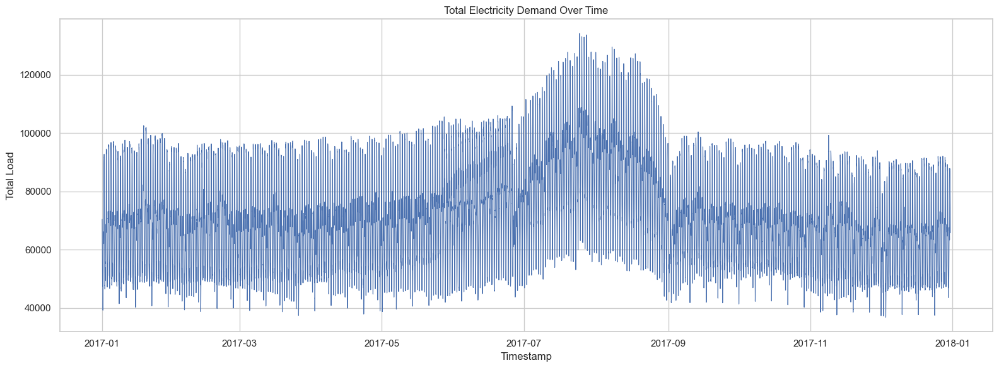

In [28]:
plt.figure(figsize=(16, 6))

plt.plot(
    df["Datetime_parsed"],
    df["Total_Load"],
    linewidth=0.8
)

plt.title("Total Electricity Demand Over Time")
plt.xlabel("Timestamp")
plt.ylabel("Total Load")
plt.tight_layout()

plt.show()

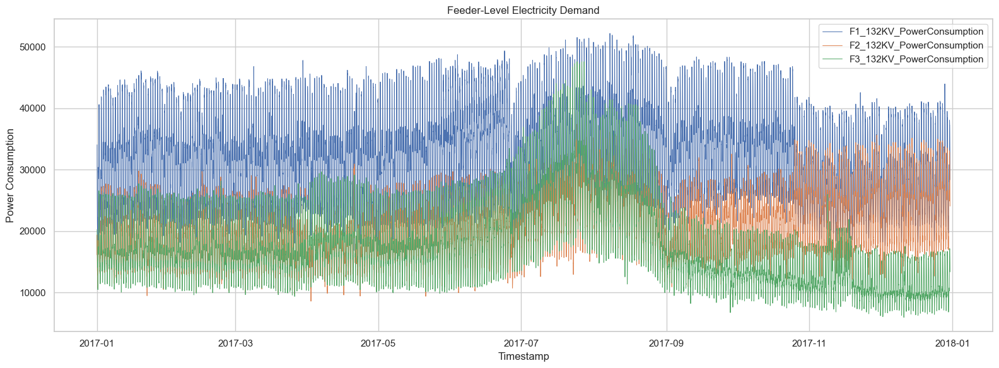

In [29]:
plt.figure(figsize=(16, 6))

for col in load_columns:
    plt.plot(
        df["Datetime_parsed"],
        df[col],
        label=col,
        linewidth=0.7
    )

plt.title("Feeder-Level Electricity Demand")
plt.xlabel("Timestamp")
plt.ylabel("Power Consumption")
plt.legend()

plt.tight_layout()
plt.show()

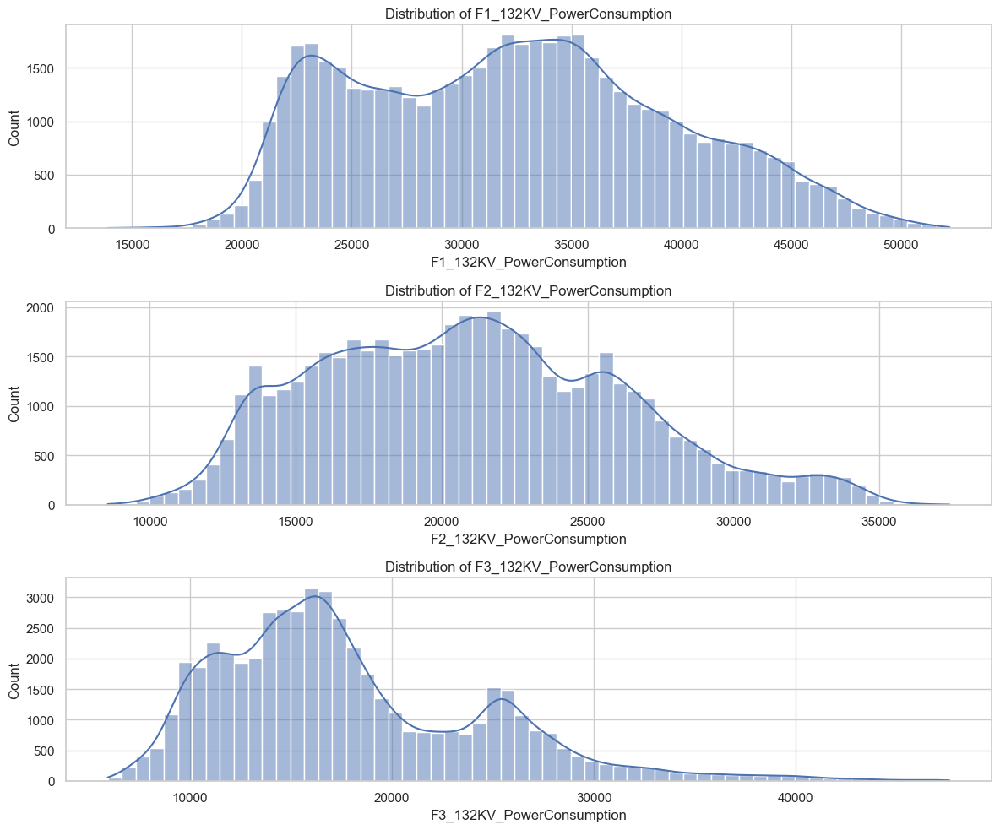

In [30]:
fig, axes = plt.subplots(
    len(load_columns),
    1,
    figsize=(12, 10)
)

for ax, col in zip(axes, load_columns):
    sns.histplot(
        df[col],
        bins=60,
        kde=True,
        ax=ax
    )
    ax.set_title(f"Distribution of {col}")

plt.tight_layout()
plt.show()

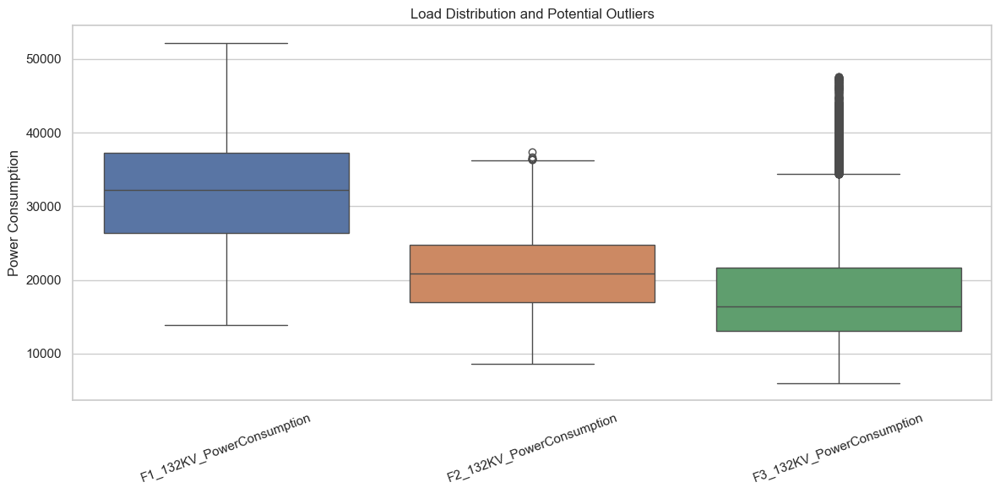

In [31]:
plt.figure(figsize=(12, 6))

sns.boxplot(
    data=df[load_columns]
)

plt.title("Load Distribution and Potential Outliers")
plt.ylabel("Power Consumption")
plt.xticks(rotation=20)

plt.tight_layout()
plt.show()

In [32]:
# Calculate IQR-based outliers for each feeder

outlier_summary = []

for col in load_columns:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = df[
        (df[col] < lower_bound) |
        (df[col] > upper_bound)
    ]
    
    outlier_summary.append({
        "Feeder": col,
        "Q1": Q1,
        "Q3": Q3,
        "IQR": IQR,
        "Lower Bound": lower_bound,
        "Upper Bound": upper_bound,
        "Outlier Count": len(outliers),
        "Outlier Percentage": len(outliers) / len(df) * 100
    })

outlier_summary = pd.DataFrame(outlier_summary)

display(outlier_summary)

,Feeder,Q1,Q3,IQR,Lower Bound,Upper Bound,Outlier Count,Outlier Percentage
0,F1_132KV_PowerConsumption,26310.668692,37309.018185,10998.349493,9813.144454,53806.542424,0,0.000000
1,F2_132KV_PowerConsumption,16980.766032,24713.717520,7732.951487,5381.338801,36313.144751,7,0.013355
2,F3_132KV_PowerConsumption,13129.326630,21624.100420,8494.773790,387.165945,34366.261105,1191,2.272207


In [33]:
upper_outlier_summary = []

for col in load_columns:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    lower_outliers = (df[col] < lower_bound).sum()
    upper_outliers = (df[col] > upper_bound).sum()
    
    upper_outlier_summary.append({
        "Feeder": col,
        "Lower Outliers": lower_outliers,
        "Upper Outliers": upper_outliers,
        "Total Outliers": lower_outliers + upper_outliers
    })

upper_outlier_summary = pd.DataFrame(upper_outlier_summary)

display(upper_outlier_summary)

,Feeder,Lower Outliers,Upper Outliers,Total Outliers
0,F1_132KV_PowerConsumption,0,0,0
1,F2_132KV_PowerConsumption,0,7,7
2,F3_132KV_PowerConsumption,0,1191,1191


In [34]:
f3 = "F3_132KV_PowerConsumption"

Q1_f3 = df[f3].quantile(0.25)
Q3_f3 = df[f3].quantile(0.75)
IQR_f3 = Q3_f3 - Q1_f3

f3_lower_bound = Q1_f3 - 1.5 * IQR_f3
f3_upper_bound = Q3_f3 + 1.5 * IQR_f3

print("F3 Lower Bound:", f3_lower_bound)
print("F3 Upper Bound:", f3_upper_bound)

F3 Lower Bound: 387.16594500000065
F3 Upper Bound: 34366.261105


In [35]:
f3_outliers = df[
    (df[f3] < f3_lower_bound) |
    (df[f3] > f3_upper_bound)
].copy()

print("Number of F3 outliers:", len(f3_outliers))

display(
    f3_outliers[
        ["Datetime_parsed", f3]
    ].head(20)
)

Number of F3 outliers: 1191


,Datetime_parsed,F3_132KV_PowerConsumption
26183,2017-07-01 19:50:00,35777.07113
26184,2017-07-01 20:00:00,36560.33473
26185,2017-07-01 20:10:00,36759.16318
26186,2017-07-01 20:20:00,36921.84100
26187,2017-07-01 20:30:00,36819.41423
26188,2017-07-01 20:40:00,36650.71130
26189,2017-07-01 20:50:00,36271.12971
26190,2017-07-01 21:00:00,35879.49791
26191,2017-07-01 21:10:00,35499.91632
26192,2017-07-01 21:20:00,35349.28870


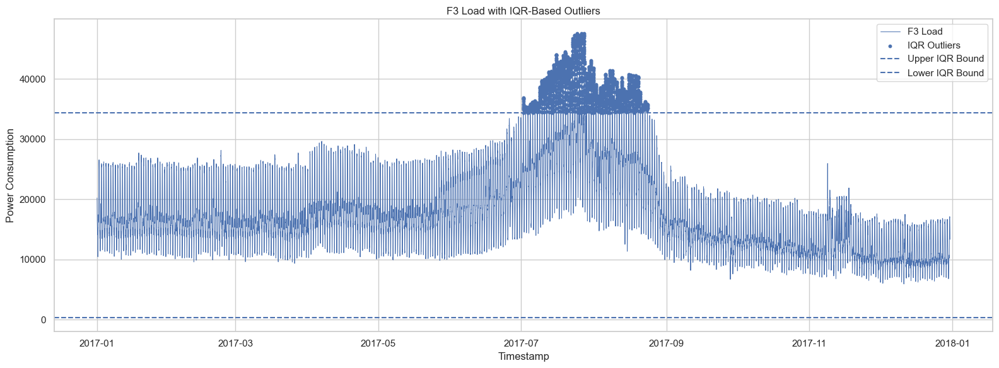

In [36]:
plt.figure(figsize=(16, 6))

plt.plot(
    df["Datetime_parsed"],
    df[f3],
    linewidth=0.7,
    label="F3 Load"
)

plt.scatter(
    f3_outliers["Datetime_parsed"],
    f3_outliers[f3],
    s=10,
    label="IQR Outliers"
)

plt.axhline(
    f3_upper_bound,
    linestyle="--",
    label="Upper IQR Bound"
)

plt.axhline(
    f3_lower_bound,
    linestyle="--",
    label="Lower IQR Bound"
)

plt.title("F3 Load with IQR-Based Outliers")
plt.xlabel("Timestamp")
plt.ylabel("Power Consumption")
plt.legend()

plt.tight_layout()
plt.show()

In [37]:
df["F3_pct_change"] = df[f3].pct_change() * 100

In [38]:
largest_f3_changes = (
    df[
        [
            "Datetime_parsed",
            f3,
            "F3_pct_change"
        ]
    ]
    .assign(
        absolute_change=lambda x: x["F3_pct_change"].abs()
    )
    .sort_values(
        "absolute_change",
        ascending=False
    )
)

display(largest_f3_changes.head(20))

,Datetime_parsed,F3_132KV_PowerConsumption,F3_pct_change,absolute_change
38915,2017-09-28 05:50:00,11543.534220,72.105263,72.105263
38913,2017-09-28 05:30:00,8131.072523,-36.547291,36.547291
49578,2017-12-11 07:00:00,5935.174070,-35.865504,35.865504
49579,2017-12-11 07:10:00,7681.152461,29.417476,29.417476
45119,2017-11-10 07:50:00,10652.530120,28.272980,28.272980
45405,2017-11-12 07:30:00,8726.746988,27.989822,27.989822
45693,2017-11-14 07:30:00,10791.325300,25.234899,25.234899
46270,2017-11-18 07:40:00,12185.060240,24.822275,24.822275
47004,2017-11-23 10:00:00,8975.421687,24.358974,24.358974
46035,2017-11-16 16:30:00,13341.686750,-23.279016,23.279016


In [39]:
def show_context(timestamp, window=6):
    idx = df.index[df["Datetime_parsed"] == timestamp]
    
    if len(idx) == 0:
        print("Timestamp not found.")
        return
    
    idx = idx[0]
    
    display(
        df.loc[
            max(0, idx - window):
            min(len(df), idx + window + 1),
            [
                "Datetime_parsed",
                "F1_132KV_PowerConsumption",
                "F2_132KV_PowerConsumption",
                "F3_132KV_PowerConsumption"
            ]
        ]
    )

In [40]:
show_context(
    largest_f3_changes.iloc[0]["Datetime_parsed"]
)

,Datetime_parsed,F1_132KV_PowerConsumption,F2_132KV_PowerConsumption,F3_132KV_PowerConsumption
38909,2017-09-28 04:50:00,28118.23009,16948.44075,13855.771200
38910,2017-09-28 05:00:00,27786.90265,16824.94802,13479.223700
38911,2017-09-28 05:10:00,27952.56637,17158.00416,13108.559750
38912,2017-09-28 05:20:00,28156.46018,17236.59044,12814.382020
38913,2017-09-28 05:30:00,27621.23894,17476.09148,8131.072523
38914,2017-09-28 05:40:00,26359.64602,16873.59667,6707.252298
38915,2017-09-28 05:50:00,26060.17699,17161.74636,11543.534220
38916,2017-09-28 06:00:00,26257.69912,17487.31809,10531.562820
38917,2017-09-28 06:10:00,26824.77876,16705.19751,10502.145050
38918,2017-09-28 06:20:00,27003.18584,16937.21414,9796.118488


In [41]:
correlation_matrix = df[
    load_columns
].corr()

display(correlation_matrix)

,F1_132KV_PowerConsumption,F2_132KV_PowerConsumption,F3_132KV_PowerConsumption
F1_132KV_PowerConsumption,1.000000,0.834519,0.750733
F2_132KV_PowerConsumption,0.834519,1.000000,0.570932
F3_132KV_PowerConsumption,0.750733,0.570932,1.000000


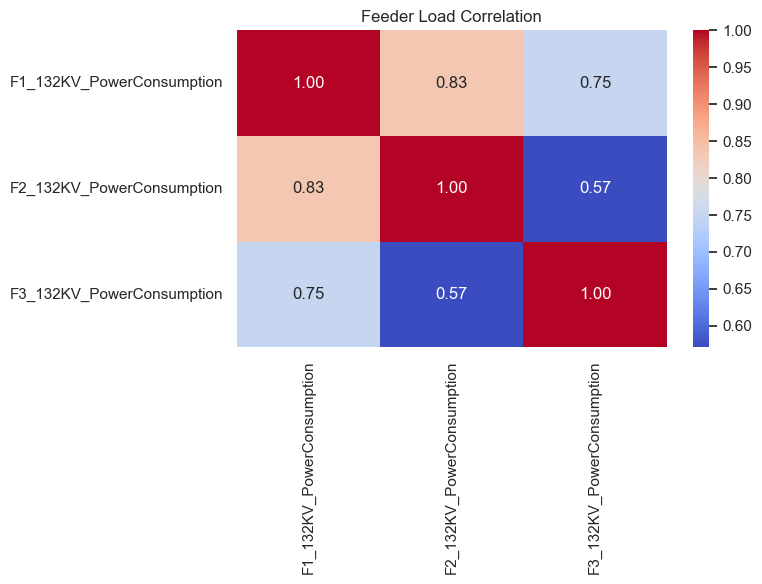

In [42]:
plt.figure(figsize=(8, 6))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.title("Feeder Load Correlation")
plt.tight_layout()
plt.show()

In [43]:
df["Hour"] = df["Datetime_parsed"].dt.hour
df["DayOfWeek"] = df["Datetime_parsed"].dt.day_name()
df["Month"] = df["Datetime_parsed"].dt.month

In [44]:
f3_outliers_with_time = df[
    (df[f3] < f3_lower_bound) |
    (df[f3] > f3_upper_bound)
].copy()

print("Outliers by hour:")
display(
    f3_outliers_with_time["Hour"]
    .value_counts()
    .sort_index()
)

Outliers by hour:


Hour
0      17
12      3
13      5
18      9
19    222
20    317
21    299
22    217
23    102
Name: count, dtype: int64

In [45]:
print("Outliers by day of week:")

display(
    f3_outliers_with_time["DayOfWeek"]
    .value_counts()
)

Outliers by day of week:


DayOfWeek
Saturday     184
Tuesday      181
Sunday       172
Wednesday    169
Thursday     166
Monday       165
Friday       154
Name: count, dtype: int64

In [46]:
print("Outliers by month:")

display(
    f3_outliers_with_time["Month"]
    .value_counts()
    .sort_index()
)

Outliers by month:


Month
7    760
8    431
Name: count, dtype: int64

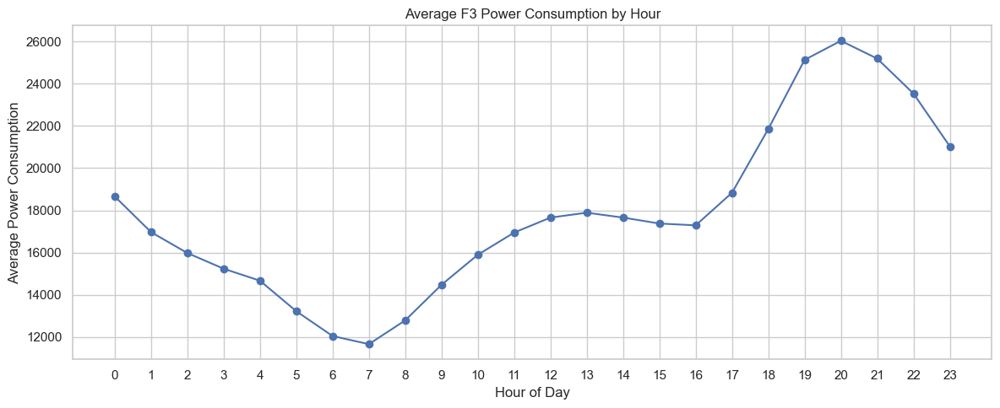

In [47]:
hourly_f3 = (
    df.groupby("Hour")[f3]
    .mean()
)

plt.figure(figsize=(12, 5))

plt.plot(
    hourly_f3.index,
    hourly_f3.values,
    marker="o"
)

plt.title("Average F3 Power Consumption by Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Average Power Consumption")
plt.xticks(range(24))

plt.tight_layout()
plt.show()

### Initial Outlier Analysis Findings

The IQR-based analysis identified a substantially larger number of statistical
outliers in feeder F3 compared with F1 and F2. F3 contains 1,191 observations
classified as outliers, representing approximately 2.27% of the dataset,
whereas F1 contains no IQR outliers and F2 contains only 7.

However, further temporal analysis shows that the F3 outliers are not randomly
distributed. All 1,191 identified observations occur during July and August,
with the majority occurring during evening hours, particularly between
19:00 and 23:00.

This concentration suggests that the observations may represent a structured
demand pattern rather than random measurement errors. Additionally, the
three feeder load series exhibit similar temporal behavior, with strong
positive correlations between the feeders.

Therefore, the IQR classification is treated as an initial statistical
screening mechanism rather than sufficient evidence for removing the
observations. The identified observations will be investigated further using
cross-feeder comparisons and temporal context before determining the
appropriate cleaning strategy.

In [48]:
df["F3_IQR_Outlier"] = (
    (df[f3] < f3_lower_bound) |
    (df[f3] > f3_upper_bound)
)

print(
    "F3 outliers:",
    df["F3_IQR_Outlier"].sum()
)

F3 outliers: 1191


In [49]:
f3_outlier_periods = df[
    df["F3_IQR_Outlier"]
][
    [
        "Datetime_parsed",
        "F1_132KV_PowerConsumption",
        "F2_132KV_PowerConsumption",
        "F3_132KV_PowerConsumption",
        "Total_Load"
    ]
].copy()

display(f3_outlier_periods.head(20))

,Datetime_parsed,F1_132KV_PowerConsumption,F2_132KV_PowerConsumption,F3_132KV_PowerConsumption,Total_Load
26183,2017-07-01 19:50:00,42756.67774,27858.22785,35777.07113,106391.97672
26184,2017-07-01 20:00:00,44121.72757,29020.25316,36560.33473,109702.31546
26185,2017-07-01 20:10:00,44810.63123,29081.01266,36759.16318,110650.80707
26186,2017-07-01 20:20:00,45314.55150,29335.44304,36921.84100,111571.83554
26187,2017-07-01 20:30:00,45359.20266,29115.18987,36819.41423,111293.80676
26188,2017-07-01 20:40:00,45244.38538,29145.56962,36650.71130,111040.66630
26189,2017-07-01 20:50:00,45046.64452,28686.07595,36271.12971,110003.85018
26190,2017-07-01 21:00:00,44995.61462,28606.32911,35879.49791,109481.44164
26191,2017-07-01 21:10:00,44899.93355,28374.68354,35499.91632,108774.53341
26192,2017-07-01 21:20:00,44868.03987,28230.37975,35349.28870,108447.70832


In [50]:
outlier_vs_normal = pd.DataFrame({
    "F1": [
        df.loc[~df["F3_IQR_Outlier"], "F1_132KV_PowerConsumption"].mean(),
        df.loc[df["F3_IQR_Outlier"], "F1_132KV_PowerConsumption"].mean()
    ],
    "F2": [
        df.loc[~df["F3_IQR_Outlier"], "F2_132KV_PowerConsumption"].mean(),
        df.loc[df["F3_IQR_Outlier"], "F2_132KV_PowerConsumption"].mean()
    ],
    "F3": [
        df.loc[~df["F3_IQR_Outlier"], "F3_132KV_PowerConsumption"].mean(),
        df.loc[df["F3_IQR_Outlier"], "F3_132KV_PowerConsumption"].mean()
    ],
    "Total Load": [
        df.loc[~df["F3_IQR_Outlier"], "Total_Load"].mean(),
        df.loc[df["F3_IQR_Outlier"], "Total_Load"].mean()
    ]
}, index=["Normal Period", "F3 Outlier Period"])

display(outlier_vs_normal)

,F1,F2,F3,Total Load
Normal Period,32017.899600,20804.394057,17350.690099,70172.983756
F3 Outlier Period,46412.317424,31283.854319,38683.083127,116379.254870


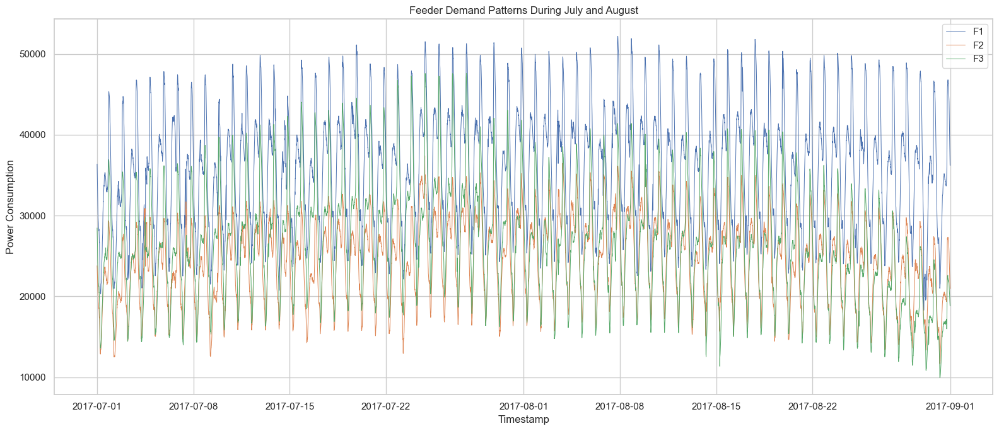

In [51]:
july_august = df[
    (df["Datetime_parsed"].dt.month.isin([7, 8]))
].copy()

plt.figure(figsize=(16, 7))

plt.plot(
    july_august["Datetime_parsed"],
    july_august["F1_132KV_PowerConsumption"],
    label="F1",
    linewidth=0.7
)

plt.plot(
    july_august["Datetime_parsed"],
    july_august["F2_132KV_PowerConsumption"],
    label="F2",
    linewidth=0.7
)

plt.plot(
    july_august["Datetime_parsed"],
    july_august["F3_132KV_PowerConsumption"],
    label="F3",
    linewidth=0.7
)

plt.title("Feeder Demand Patterns During July and August")
plt.xlabel("Timestamp")
plt.ylabel("Power Consumption")
plt.legend()

plt.tight_layout()
plt.show()

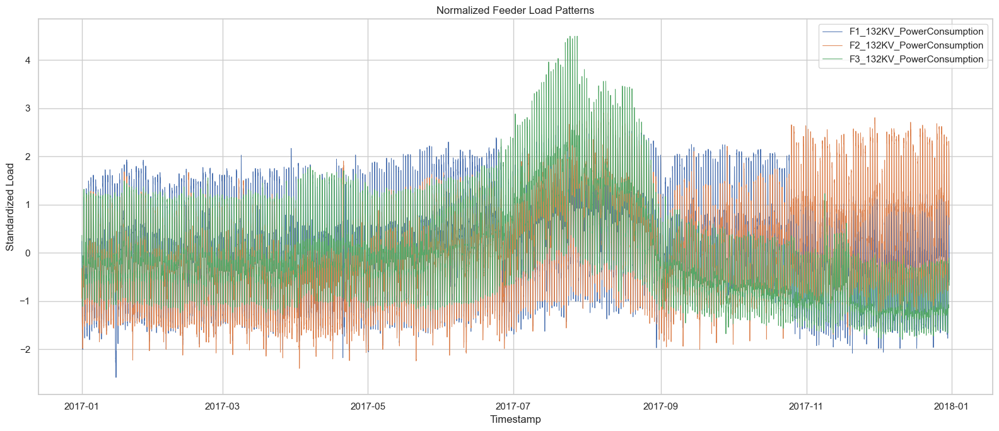

In [52]:
normalized_load = df[load_columns].copy()

for col in load_columns:
    normalized_load[col] = (
        normalized_load[col] -
        normalized_load[col].mean()
    ) / normalized_load[col].std()

normalized_load["Datetime"] = df["Datetime_parsed"]

plt.figure(figsize=(16, 7))

for col in load_columns:
    plt.plot(
        normalized_load["Datetime"],
        normalized_load[col],
        label=col,
        linewidth=0.7
    )

plt.title("Normalized Feeder Load Patterns")
plt.xlabel("Timestamp")
plt.ylabel("Standardized Load")
plt.legend()

plt.tight_layout()
plt.show()

In [53]:
hourly_profile = (
    df.groupby("Hour")[load_columns + ["Total_Load"]]
    .mean()
)

display(hourly_profile)

,F1_132KV_PowerConsumption,F2_132KV_PowerConsumption,F3_132KV_PowerConsumption,Total_Load
Hour,,,,
0,30217.235372,19692.073550,18657.222811,68566.531733
1,27565.533030,17765.078949,16970.804696,62301.416675
2,26292.688917,16730.156092,15981.096176,59003.941184
3,25338.122851,16052.585288,15238.605002,56629.313141
4,24633.576717,15624.081077,14671.039080,54928.696874
5,23437.577276,14974.907723,13226.380008,51638.865007
6,23203.597394,14934.698604,12051.599729,50189.895727
7,24038.353352,15719.115067,11667.864458,51425.332877
8,26583.262396,17529.678454,12793.786057,56906.726907


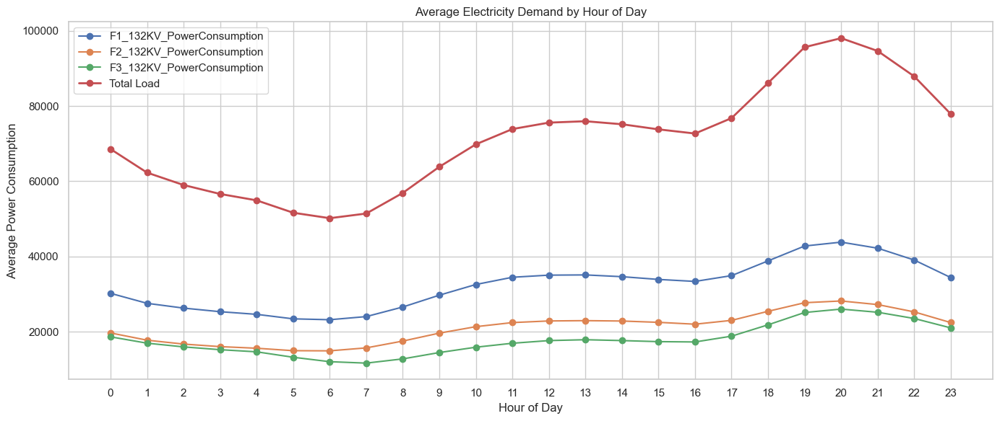

In [54]:
plt.figure(figsize=(14, 6))

for col in load_columns:
    plt.plot(
        hourly_profile.index,
        hourly_profile[col],
        marker="o",
        label=col
    )

plt.plot(
    hourly_profile.index,
    hourly_profile["Total_Load"],
    marker="o",
    linewidth=2,
    label="Total Load"
)

plt.title("Average Electricity Demand by Hour of Day")
plt.xlabel("Hour of Day")
plt.ylabel("Average Power Consumption")
plt.xticks(range(24))
plt.legend()

plt.tight_layout()
plt.show()

## Outlier Investigation Findings and Decision

The IQR analysis initially identified 1,191 observations in feeder F3 as
statistical outliers, representing approximately 2.27% of the observations.
In comparison, F1 contained no IQR-based outliers and F2 contained only 7.

However, further temporal and cross-feeder analysis indicates that the F3
outliers are not isolated events.

The identified F3 outlier periods occur predominantly during July and August
and are concentrated during evening hours. More importantly, the average load
across all three feeders is substantially higher during F3 outlier periods:

- F1: approximately 32,018 during normal periods versus 46,412 during F3
  outlier periods.
- F2: approximately 20,804 during normal periods versus 31,284 during F3
  outlier periods.
- F3: approximately 17,351 during normal periods versus 38,683 during F3
  outlier periods.
- Total system load: approximately 70,173 during normal periods versus
  116,379 during F3 outlier periods.

This indicates that the observations classified as F3 statistical outliers
coincide with elevated demand across multiple feeders. The feeder-level
series also exhibit positive correlations, indicating shared temporal demand
behavior.

Therefore, the IQR classification alone is not considered sufficient evidence
that these observations are erroneous. The identified observations are
retained in the dataset rather than removed or imputed.

The IQR method will therefore be treated as an exploratory anomaly-detection
technique rather than an automatic outlier-removal rule.

## Hourly Demand Pattern

The hourly aggregation reveals a strong diurnal pattern in electricity
demand.

Total demand decreases during the early morning hours and reaches its lowest
average level around 06:00. Demand then increases throughout the morning and
afternoon before rising sharply during the evening.

The highest average total demand occurs around 20:00, followed by a gradual
decline later in the evening.

This recurring daily structure indicates that time-of-day is likely to be an
important predictor for the forecasting model. It also supports the use of
lagged observations from previous days and weeks because the demand profile
shows strong temporal repetition.

In [55]:
day_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"
]

daily_profile = (
    df.groupby("DayOfWeek")[load_columns + ["Total_Load"]]
    .mean()
    .reindex(day_order)
)

display(daily_profile)

,F1_132KV_PowerConsumption,F2_132KV_PowerConsumption,F3_132KV_PowerConsumption,Total_Load
DayOfWeek,,,,
Monday,32615.410633,21280.065085,17809.081562,71704.557279
Tuesday,32713.030148,21518.599887,17831.688173,72063.318208
Wednesday,32871.759018,21627.362715,17851.395059,72350.516792
Thursday,32842.484416,21845.164469,17843.692103,72531.340987
Friday,32338.995905,21461.038263,17545.971382,71346.005550
Saturday,32253.034345,20585.955724,18011.187469,70850.177537
Sunday,30780.079481,18979.377434,17954.827782,67714.284697


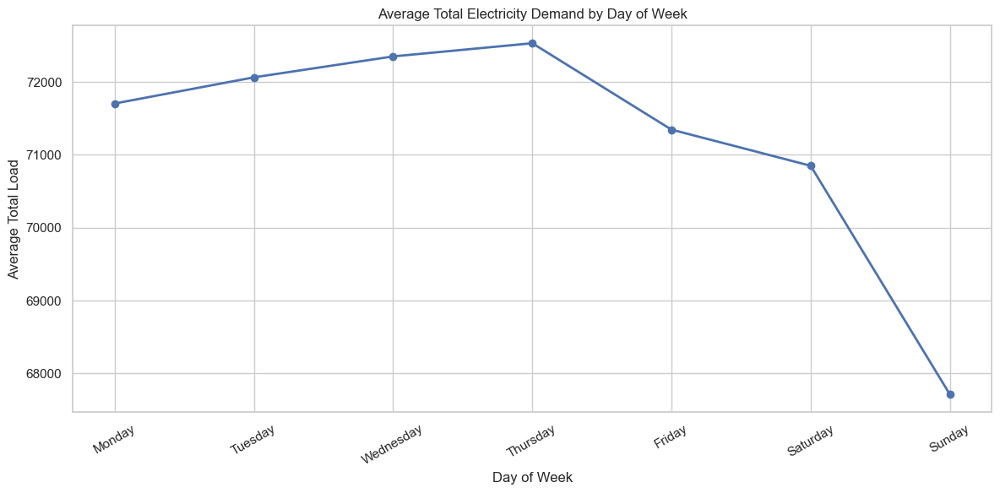

In [56]:
plt.figure(figsize=(12, 6))

plt.plot(
    daily_profile.index,
    daily_profile["Total_Load"],
    marker="o",
    linewidth=2
)

plt.title("Average Total Electricity Demand by Day of Week")
plt.xlabel("Day of Week")
plt.ylabel("Average Total Load")
plt.xticks(rotation=30)

plt.tight_layout()
plt.show()

In [57]:
df["Is_Weekend"] = (
    df["Datetime_parsed"].dt.dayofweek >= 5
)

In [58]:
weekend_comparison = (
    df.groupby("Is_Weekend")[
        load_columns + ["Total_Load"]
    ]
    .mean()
)

weekend_comparison.index = [
    "Weekday",
    "Weekend"
]

display(weekend_comparison)

,F1_132KV_PowerConsumption,F2_132KV_PowerConsumption,F3_132KV_PowerConsumption,Total_Load
Weekday,32676.336024,21546.446084,17776.365656,71999.147763
Weekend,31516.556913,19782.666579,17983.007625,69282.231117


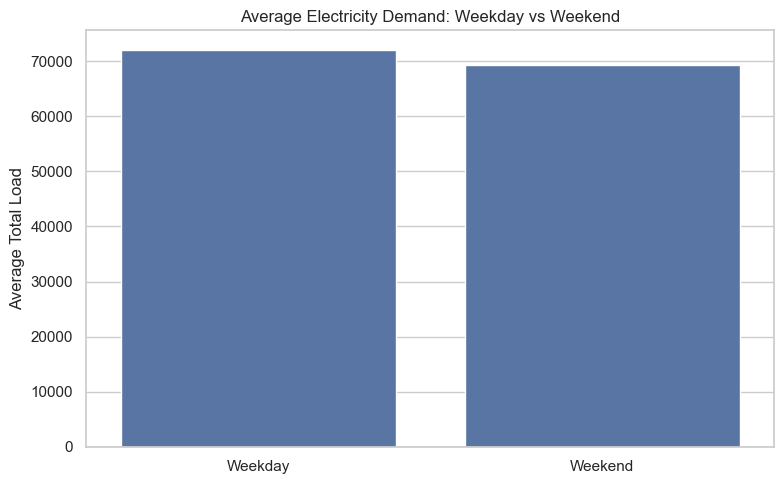

In [59]:
plt.figure(figsize=(8, 5))

sns.barplot(
    x=weekend_comparison.index,
    y=weekend_comparison["Total_Load"]
)

plt.title("Average Electricity Demand: Weekday vs Weekend")
plt.xlabel("")
plt.ylabel("Average Total Load")

plt.tight_layout()
plt.show()

In [60]:
hour_day_profile = (
    df.groupby(["DayOfWeek", "Hour"])["Total_Load"]
    .mean()
    .unstack(level=0)
)

hour_day_profile = hour_day_profile[
    day_order
]

display(hour_day_profile.head())

DayOfWeek,Monday,Tuesday,Wednesday,Thursday,Friday,Saturday,Sunday
Hour,,,,,,,
0,67817.926234,67935.356547,68239.842528,68293.632675,68959.251459,68991.576226,69728.136464
1,61755.422717,61868.544847,62022.724317,62187.544469,62533.960861,62628.416936,63113.302575
2,58647.360270,58801.200586,58798.761412,59063.328906,59152.040758,59321.825090,59243.071267
3,56399.125350,56642.907327,56626.703787,56958.133058,56825.429786,56745.339022,56207.553656
4,54823.472531,55088.146346,55114.497390,55465.004964,55296.351259,54816.778024,53896.627602


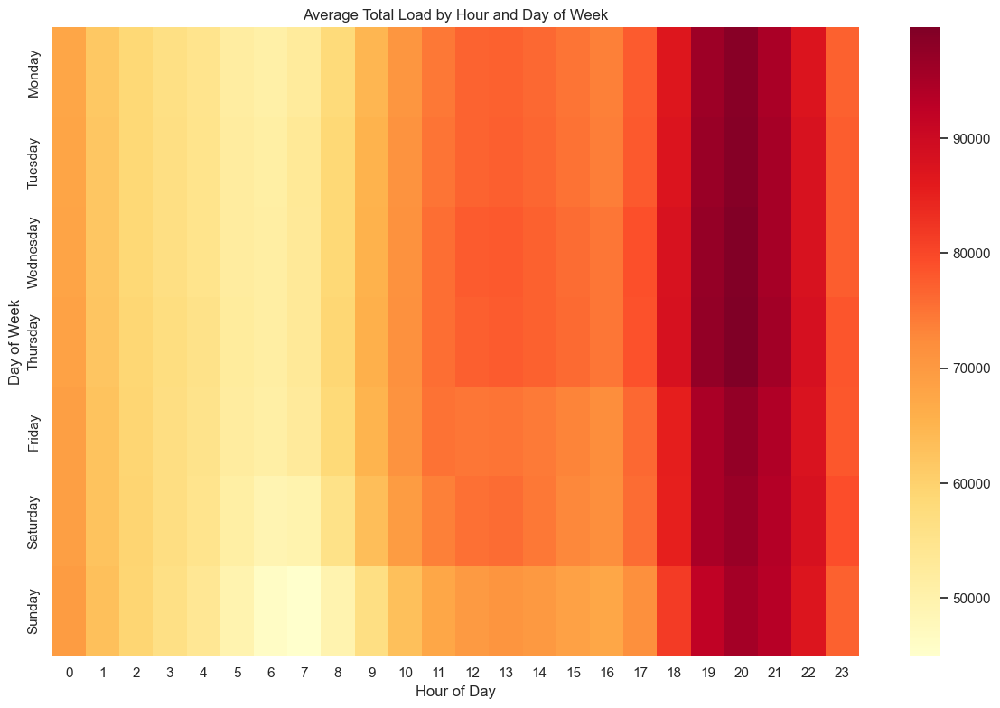

In [61]:
plt.figure(figsize=(12, 8))

sns.heatmap(
    hour_day_profile.T,
    cmap="YlOrRd",
    annot=False
)

plt.title("Average Total Load by Hour and Day of Week")
plt.xlabel("Hour of Day")
plt.ylabel("Day of Week")

plt.tight_layout()
plt.show()

In [62]:
daily_total = (
    df.set_index("Datetime_parsed")["Total_Load"]
    .resample("D")
    .mean()
)

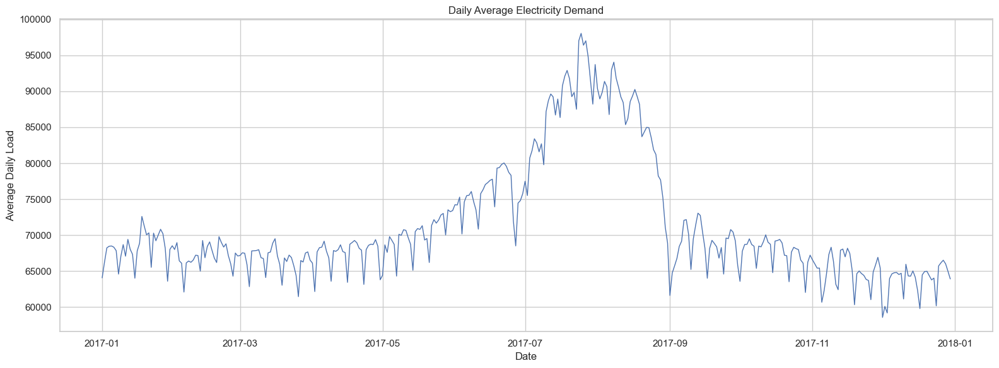

In [63]:
plt.figure(figsize=(16, 6))

plt.plot(
    daily_total.index,
    daily_total.values,
    linewidth=1
)

plt.title("Daily Average Electricity Demand")
plt.xlabel("Date")
plt.ylabel("Average Daily Load")

plt.tight_layout()
plt.show()

## Day-of-Week and Weekly Demand Patterns

The day-of-week analysis shows that electricity demand varies systematically
throughout the week.

The average weekday total load is approximately 71,999, compared with
approximately 69,282 during weekends. This represents a difference of
approximately 3.8%.

Thursday records the highest average total demand among the individual
weekdays, while Sunday records the lowest average demand.

The difference between weekdays and weekends indicates that day-of-week
information may provide useful predictive information for electricity demand.

The hour-by-day heatmap also reveals that the daily demand profile is
consistent across the week. Demand is relatively low during the early morning,
increases during the daytime, and exhibits a pronounced evening peak,
particularly around 19:00–21:00.

These observations suggest that both `hour_of_day` and `day_of_week` should
be considered during feature engineering.

## Daily and Seasonal Demand Behavior

The daily average demand series shows substantial variation across the year.

Demand gradually increases during the first half of the year and reaches a
much higher level during July and August. A sharp reduction in demand is
observed around the beginning of September, after which demand remains at a
lower level through the remainder of the observed period.

This seasonal behavior is consistent with the earlier outlier analysis. The
majority of statistical outliers identified in F3 occurred during July and
August, which are also periods of substantially elevated total system demand.

Therefore, the high F3 observations should not be automatically treated as
data errors. Their concentration during a broader system-level demand
increase provides additional evidence that they may represent legitimate
high-demand periods.

Seasonal and calendar information will therefore be investigated further
before finalizing the data-cleaning strategy.

In [65]:
monthly_profile = (
    df.groupby(df["Datetime_parsed"].dt.month)["Total_Load"]
    .agg(["mean", "min", "max", "std"])
)

monthly_profile.index.name = "Month"

display(monthly_profile)

,mean,min,max,std
Month,,,,
1,68173.033601,39239.457920,102522.19133,15841.008772
2,67108.548882,38782.313450,97835.10319,15115.096692
3,66560.788896,37436.222842,97613.26358,14660.247022
4,67396.902281,37933.393604,98978.25136,14038.581761
5,69994.397979,38750.537800,105576.67809,14941.941651
6,75707.410998,42361.915613,109331.74758,16782.865193
7,88173.551711,46882.512140,134208.14595,18284.433736
8,85740.300881,42642.153285,129536.30747,18118.532072
9,68499.912449,41753.412449,100417.58110,13351.730038


In [66]:
month_order = [
    "January",
    "February",
    "March",
    "April",
    "May",
    "June",
    "July",
    "August",
    "September",
    "October",
    "November",
    "December"
]

df["Month"] = df["Datetime_parsed"].dt.month_name()

monthly_profile_named = (
    df.groupby("Month")["Total_Load"]
    .agg(["mean", "min", "max", "std"])
    .reindex(month_order)
)

display(monthly_profile_named)

,mean,min,max,std
Month,,,,
January,68173.033601,39239.457920,102522.19133,15841.008772
February,67108.548882,38782.313450,97835.10319,15115.096692
March,66560.788896,37436.222842,97613.26358,14660.247022
April,67396.902281,37933.393604,98978.25136,14038.581761
May,69994.397979,38750.537800,105576.67809,14941.941651
June,75707.410998,42361.915613,109331.74758,16782.865193
July,88173.551711,46882.512140,134208.14595,18284.433736
August,85740.300881,42642.153285,129536.30747,18118.532072
September,68499.912449,41753.412449,100417.58110,13351.730038


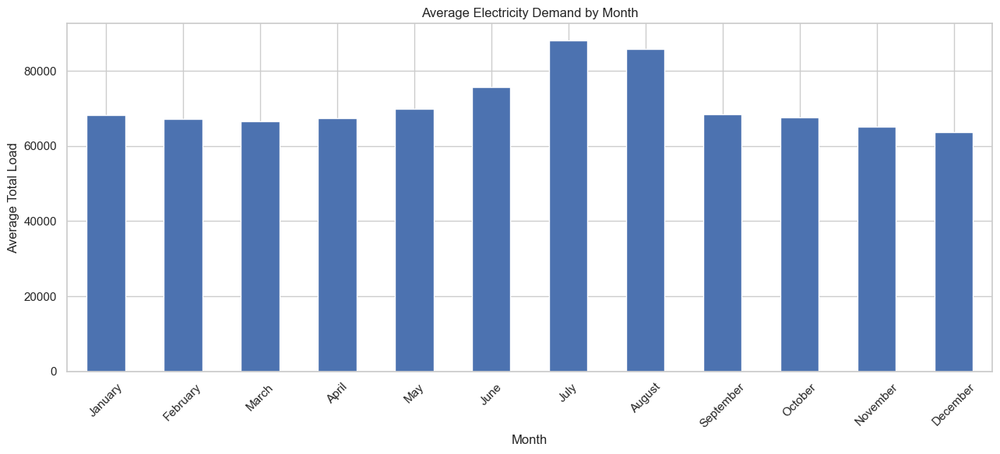

In [67]:
plt.figure(figsize=(13, 6))

monthly_profile_named["mean"].plot(
    kind="bar"
)

plt.title("Average Electricity Demand by Month")
plt.xlabel("Month")
plt.ylabel("Average Total Load")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [68]:
monthly_feeder_profile = (
    df.groupby("Month")[load_columns + ["Total_Load"]]
    .mean()
    .reindex(month_order)
)

display(monthly_feeder_profile)

,F1_132KV_PowerConsumption,F2_132KV_PowerConsumption,F3_132KV_PowerConsumption,Total_Load
Month,,,,
January,31032.493535,19394.444717,17746.095349,68173.033601
February,30985.753632,18787.793096,17335.002154,67108.548882
March,31155.165408,18457.937484,16947.686004,66560.788896
April,31169.768210,17633.966395,18593.167677,67396.902281
May,32396.009166,19977.287859,17621.100953,69994.397979
June,34605.540839,20670.928621,20430.941538,75707.410998
July,35831.553603,24147.886893,28194.111216,88173.551711
August,36435.189574,24656.216575,24648.894732,85740.300881
September,33396.681416,20180.432259,14922.798774,68499.912449


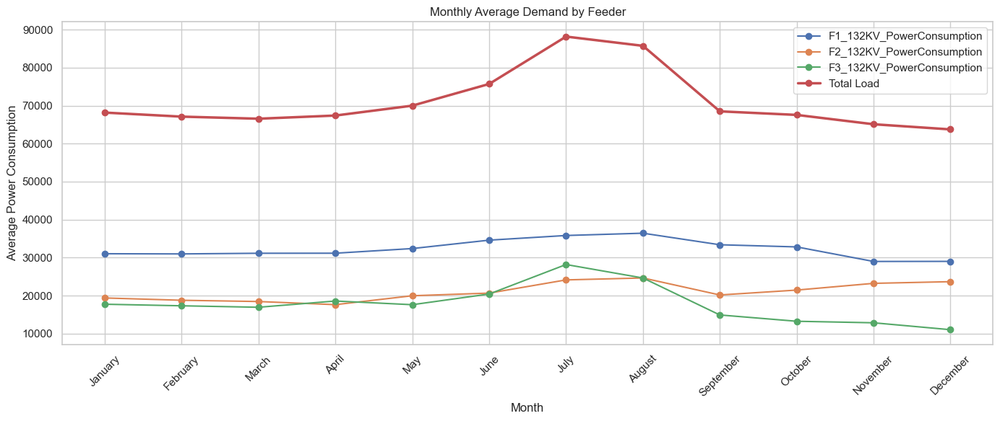

In [69]:
plt.figure(figsize=(14, 6))

for col in load_columns:
    plt.plot(
        monthly_feeder_profile.index,
        monthly_feeder_profile[col],
        marker="o",
        label=col
    )

plt.plot(
    monthly_feeder_profile.index,
    monthly_feeder_profile["Total_Load"],
    marker="o",
    linewidth=2.5,
    label="Total Load"
)

plt.title("Monthly Average Demand by Feeder")
plt.xlabel("Month")
plt.ylabel("Average Power Consumption")
plt.xticks(rotation=45)
plt.legend()

plt.tight_layout()
plt.show()

In [70]:
weather_columns = [
    "Temperature",
    "Humidity",
    "WindSpeed"
]

display(
    df[weather_columns].describe()
)

,Temperature,Humidity,WindSpeed
count,52416.000000,52416.000000,52416.000000
mean,18.810024,68.259518,1.959489
std,5.815476,15.551177,2.348862
min,3.247000,11.340000,0.050000
25%,14.410000,58.310000,0.078000
50%,18.780000,69.860000,0.086000
75%,22.890000,81.400000,4.915000
max,40.010000,94.800000,6.483000


In [71]:
weather_quality = pd.DataFrame({
    "Missing Count": df[weather_columns].isna().sum(),
    "Missing Percentage": (
        df[weather_columns].isna().mean() * 100
    ).round(3),
    "Unique Values": df[weather_columns].nunique()
})

display(weather_quality)

,Missing Count,Missing Percentage,Unique Values
Temperature,0,0.0,3437
Humidity,0,0.0,4443
WindSpeed,0,0.0,548


In [72]:
weather_load_corr = df[
    ["Total_Load"] + weather_columns
].corr()

display(weather_load_corr)

,Total_Load,Temperature,Humidity,WindSpeed
Total_Load,1.000000,0.488238,-0.299059,0.221706
Temperature,0.488238,1.000000,-0.460243,0.477109
Humidity,-0.299059,-0.460243,1.000000,-0.135853
WindSpeed,0.221706,0.477109,-0.135853,1.000000


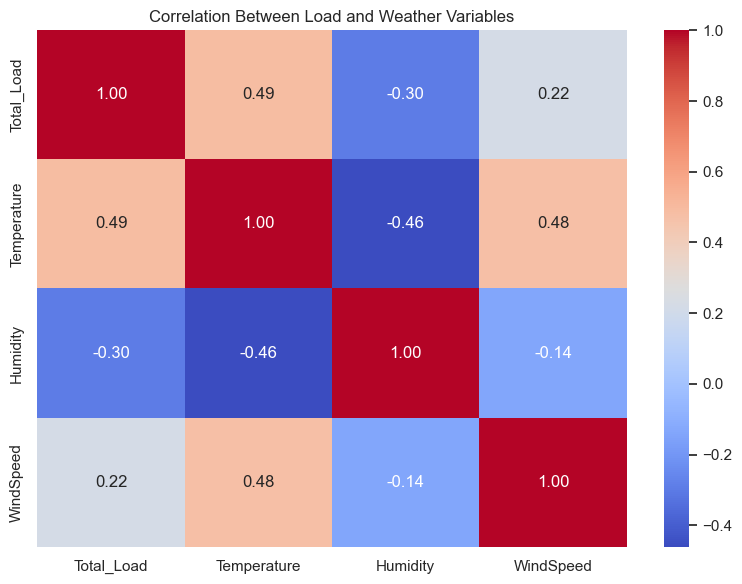

In [73]:
plt.figure(figsize=(8, 6))

sns.heatmap(
    weather_load_corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.title("Correlation Between Load and Weather Variables")
plt.tight_layout()
plt.show()

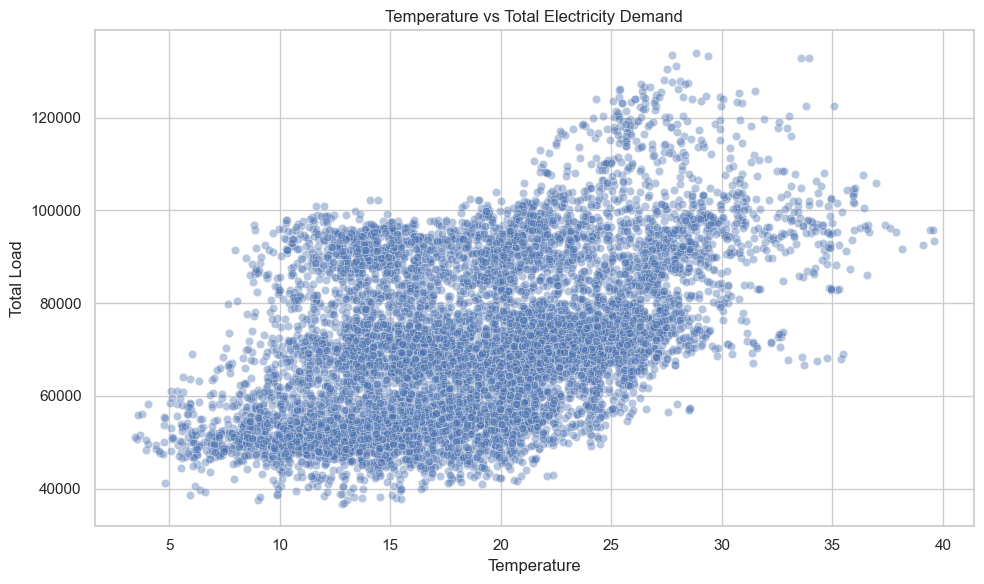

In [74]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df.sample(
        min(10000, len(df)),
        random_state=42
    ),
    x="Temperature",
    y="Total_Load",
    alpha=0.4
)

plt.title("Temperature vs Total Electricity Demand")
plt.xlabel("Temperature")
plt.ylabel("Total Load")

plt.tight_layout()
plt.show()

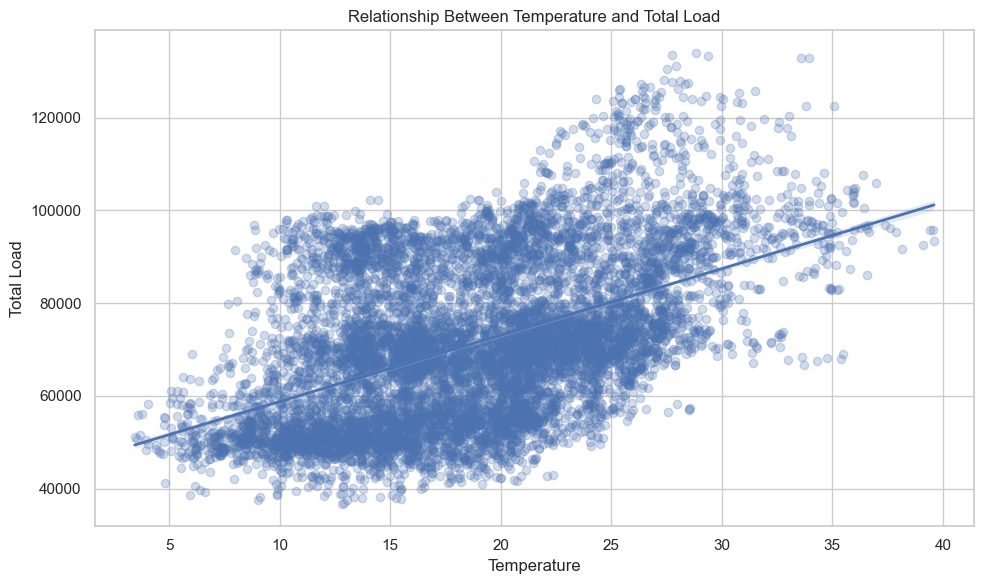

In [75]:
plt.figure(figsize=(10, 6))

sns.regplot(
    data=df.sample(
        min(10000, len(df)),
        random_state=42
    ),
    x="Temperature",
    y="Total_Load",
    scatter_kws={"alpha": 0.25},
    line_kws={"linewidth": 2}
)

plt.title("Relationship Between Temperature and Total Load")
plt.xlabel("Temperature")
plt.ylabel("Total Load")

plt.tight_layout()
plt.show()

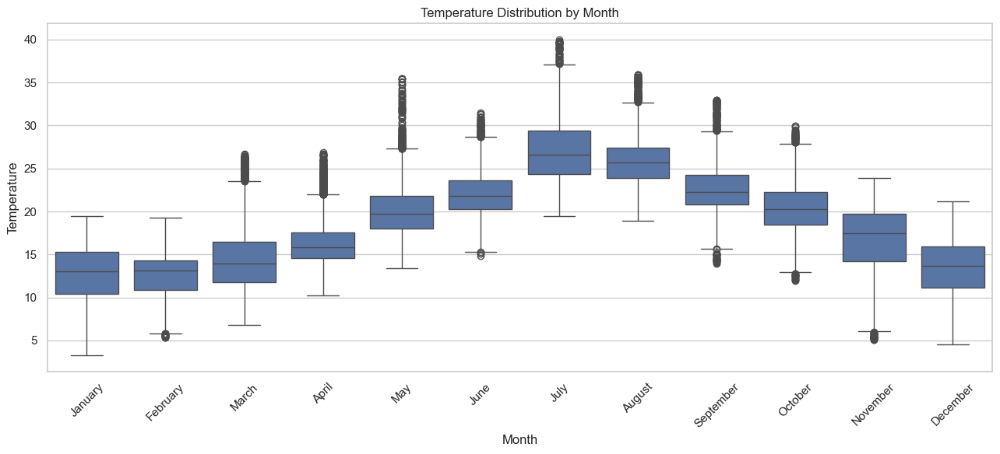

In [76]:
plt.figure(figsize=(13, 6))

sns.boxplot(
    data=df,
    x="Month",
    y="Temperature",
    order=month_order
)

plt.title("Temperature Distribution by Month")
plt.xlabel("Month")
plt.ylabel("Temperature")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

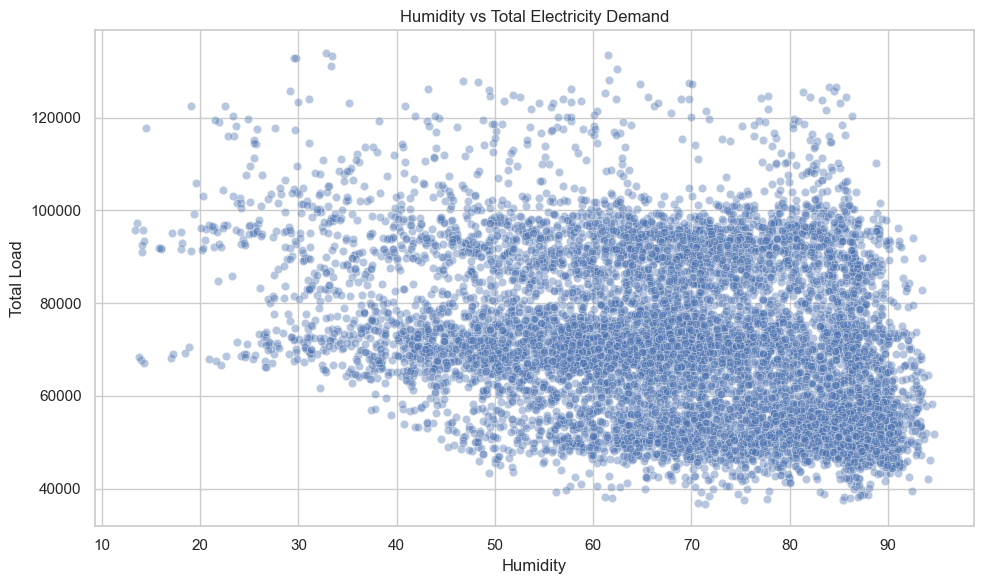

In [77]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df.sample(
        min(10000, len(df)),
        random_state=42
    ),
    x="Humidity",
    y="Total_Load",
    alpha=0.4
)

plt.title("Humidity vs Total Electricity Demand")
plt.xlabel("Humidity")
plt.ylabel("Total Load")

plt.tight_layout()
plt.show()

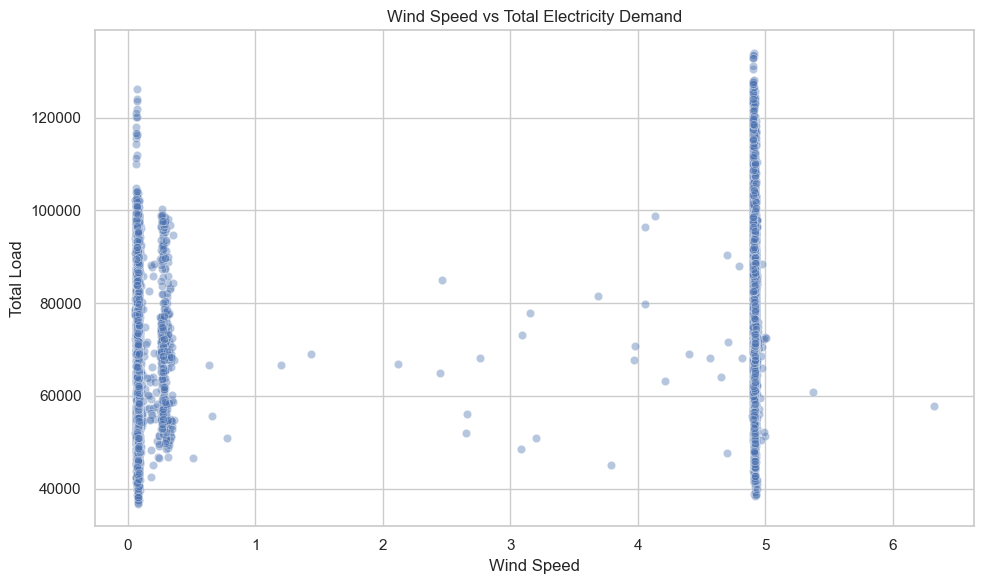

In [78]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df.sample(
        min(10000, len(df)),
        random_state=42
    ),
    x="WindSpeed",
    y="Total_Load",
    alpha=0.4
)

plt.title("Wind Speed vs Total Electricity Demand")
plt.xlabel("Wind Speed")
plt.ylabel("Total Load")

plt.tight_layout()
plt.show()

## Monthly and Seasonal Demand Analysis

Monthly aggregation reveals substantial seasonal variation in electricity
demand.

The average total load is relatively stable during the first few months of
the year, followed by an increase beginning around May and June. Demand
reaches its highest monthly average in July at approximately 88,174, followed
by August at approximately 85,740.

A substantial reduction occurs in September, when the average demand falls to
approximately 68,500. Demand subsequently remains at comparatively lower
levels during October, November, and December.

The July and August increase is consistent with the earlier observation that
the majority of F3's IQR-based statistical outliers occur during these two
months. Since the increase is also observed at the system level, these
observations are not treated as automatically erroneous.

The seasonal pattern indicates that month/seasonal information may provide
useful predictive information for the forecasting model.

## Weather and Electricity Demand Relationship

The initial correlation analysis indicates that weather variables have
measurable relationships with electricity demand.

Temperature has the strongest linear association with total load among the
available weather variables, with a Pearson correlation of approximately
0.488. This indicates a moderate positive relationship.

Humidity has a negative correlation with total load of approximately -0.299,
while wind speed has a weaker positive correlation of approximately 0.222.

These correlations indicate that weather information may provide useful
predictive information. However, correlation alone does not establish
causation and may not capture nonlinear or time-dependent relationships.

Therefore, the weather variables will be investigated further using
visualizations and grouped analysis before feature engineering.

In [79]:
# Create temperature bins
df["Temperature_Bin"] = pd.cut(
    df["Temperature"],
    bins=10
)

temperature_demand = (
    df.groupby("Temperature_Bin", observed=True)["Total_Load"]
    .agg(["mean", "median", "count"])
)

display(temperature_demand)

,mean,median,count
Temperature_Bin,,,
"(3.21, 6.923]",51900.744738,50668.816187,588
"(6.923, 10.6]",57656.269656,52419.584090,3225
"(10.6, 14.276]",65818.268467,63383.998375,8792
"(14.276, 17.952]",66595.841447,66348.200347,11349
"(17.952, 21.628]",69763.304135,68386.932500,11861
"(21.628, 25.305]",76040.787137,73086.538580,9169
"(25.305, 28.981]",86080.999958,83880.172620,5335
"(28.981, 32.657]",93744.326974,94440.662245,1478
"(32.657, 36.334]",96746.845231,97146.658360,532


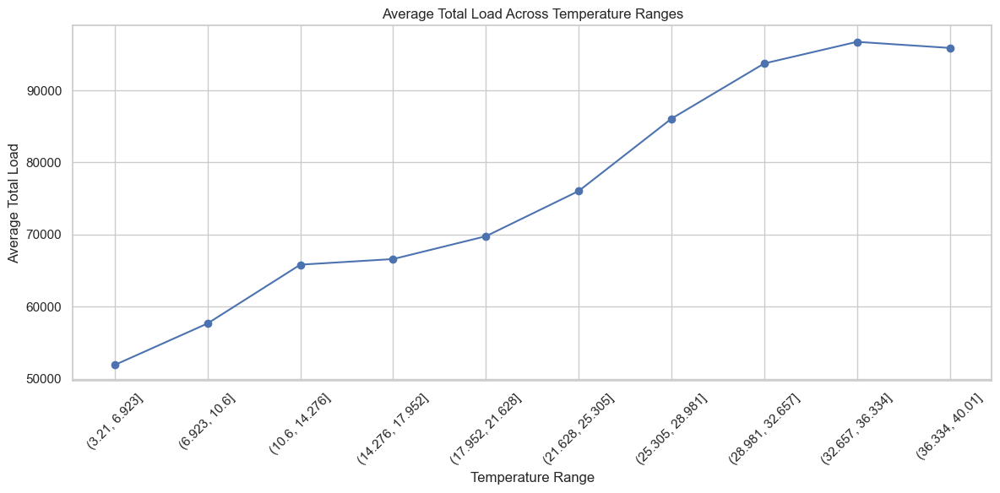

In [80]:
plt.figure(figsize=(12, 6))

plt.plot(
    temperature_demand.index.astype(str),
    temperature_demand["mean"],
    marker="o"
)

plt.title("Average Total Load Across Temperature Ranges")
plt.xlabel("Temperature Range")
plt.ylabel("Average Total Load")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [81]:
temperature_hour = (
    df.groupby("Hour")[
        ["Temperature", "Total_Load"]
    ]
    .corr()
    .loc[
        (slice(None), "Temperature"),
        "Total_Load"
    ]
    .reset_index()
)

temperature_hour.columns = [
    "Hour",
    "Variable",
    "Correlation"
]

temperature_hour = temperature_hour[
    temperature_hour["Variable"] == "Total_Load"
].drop(columns="Variable")

display(temperature_hour)

,Hour,Correlation


In [82]:
temperature_hour_corr = []

for hour in range(24):
    subset = df[df["Hour"] == hour]
    
    correlation = subset[
        ["Temperature", "Total_Load"]
    ].corr().loc[
        "Temperature",
        "Total_Load"
    ]
    
    temperature_hour_corr.append({
        "Hour": hour,
        "Temperature_Load_Correlation": correlation
    })

temperature_hour_corr = pd.DataFrame(
    temperature_hour_corr
)

display(temperature_hour_corr)

,Hour,Temperature_Load_Correlation
0,0,0.672483
1,1,0.667826
2,2,0.638010
3,3,0.713396
4,4,0.773186
5,5,0.427098
6,6,0.291278
7,7,0.608176
8,8,0.672038
9,9,0.664079


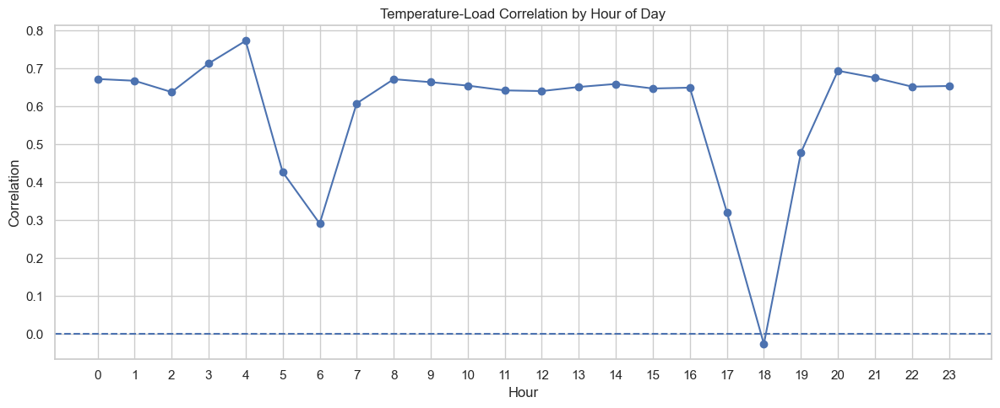

In [83]:
plt.figure(figsize=(12, 5))

plt.plot(
    temperature_hour_corr["Hour"],
    temperature_hour_corr["Temperature_Load_Correlation"],
    marker="o"
)

plt.axhline(
    0,
    linestyle="--"
)

plt.title(
    "Temperature-Load Correlation by Hour of Day"
)

plt.xlabel("Hour")
plt.ylabel("Correlation")
plt.xticks(range(24))

plt.tight_layout()
plt.show()

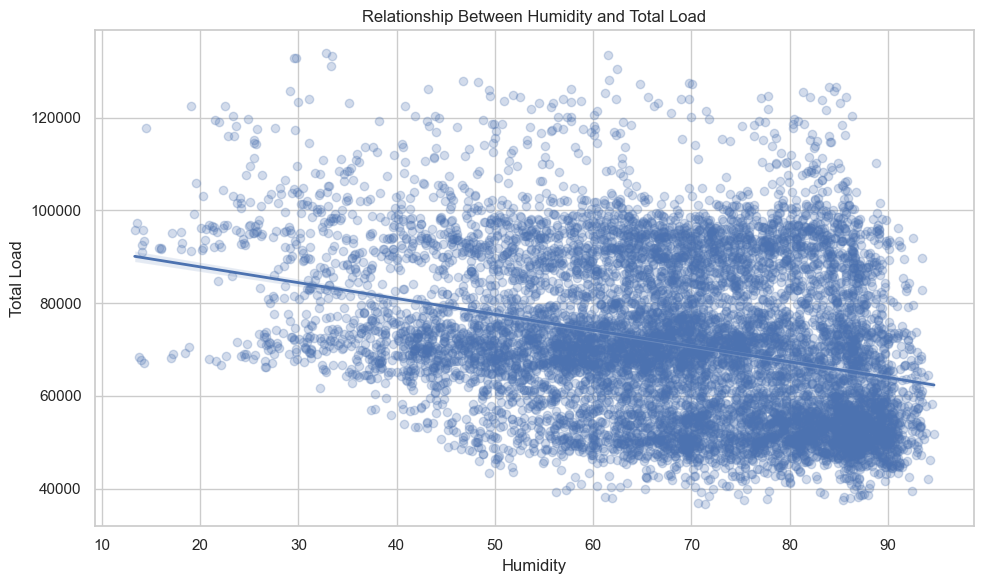

In [84]:
plt.figure(figsize=(10, 6))

sns.regplot(
    data=df.sample(
        min(10000, len(df)),
        random_state=42
    ),
    x="Humidity",
    y="Total_Load",
    scatter_kws={"alpha": 0.25},
    line_kws={"linewidth": 2}
)

plt.title("Relationship Between Humidity and Total Load")
plt.xlabel("Humidity")
plt.ylabel("Total Load")

plt.tight_layout()
plt.show()

In [85]:
df["Humidity_Bin"] = pd.cut(
    df["Humidity"],
    bins=10
)

humidity_demand = (
    df.groupby("Humidity_Bin", observed=True)["Total_Load"]
    .agg(["mean", "median", "count"])
)

display(humidity_demand)

,mean,median,count
Humidity_Bin,,,
"(11.257, 19.686]",90086.930210,92550.705880,143
"(19.686, 28.032]",91369.471061,94732.504930,459
"(28.032, 36.378]",85742.496215,83499.863980,1295
"(36.378, 44.724]",78276.267982,73866.745780,2583
"(44.724, 53.07]",75566.669830,72578.336420,4517
"(53.07, 61.416]",73969.955232,71594.756550,7125
"(61.416, 69.762]",72147.948400,71079.498840,9949
"(69.762, 78.108]",70654.199138,69788.799050,9611
"(78.108, 86.454]",68508.155482,63798.340595,10780


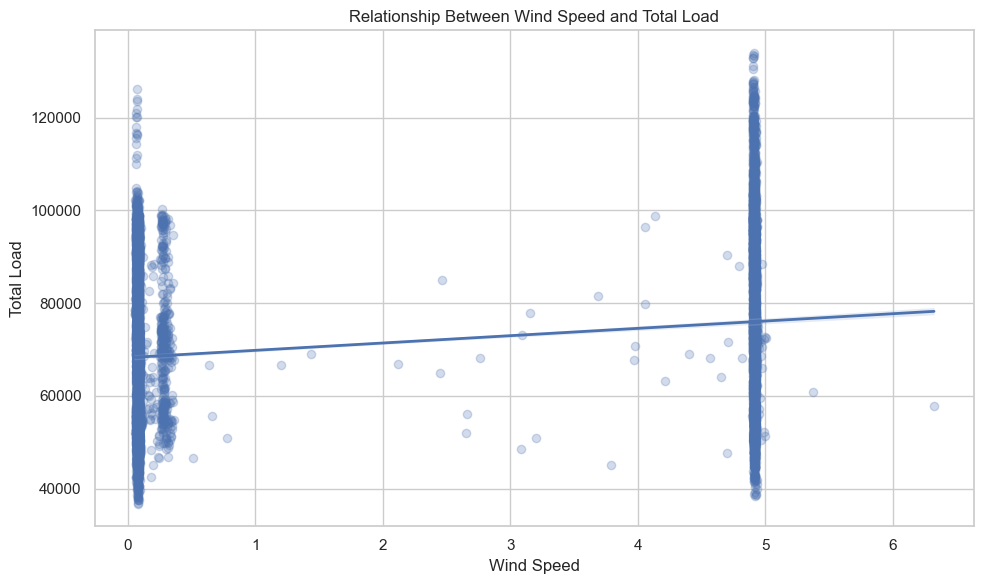

In [86]:
plt.figure(figsize=(10, 6))

sns.regplot(
    data=df.sample(
        min(10000, len(df)),
        random_state=42
    ),
    x="WindSpeed",
    y="Total_Load",
    scatter_kws={"alpha": 0.25},
    line_kws={"linewidth": 2}
)

plt.title("Relationship Between Wind Speed and Total Load")
plt.xlabel("Wind Speed")
plt.ylabel("Total Load")

plt.tight_layout()
plt.show()

In [87]:
df["WindSpeed_Bin"] = pd.cut(
    df["WindSpeed"],
    bins=10
)

wind_demand = (
    df.groupby("WindSpeed_Bin", observed=True)["Total_Load"]
    .agg(["mean", "median", "count"])
)

display(wind_demand)

,mean,median,count
WindSpeed_Bin,,,
"(0.0436, 0.693]",68198.263562,67809.676960,32061
"(0.693, 1.337]",66133.865478,64563.711790,25
"(1.337, 1.98]",69005.093416,67250.776400,16
"(1.98, 2.623]",69297.297834,65849.059945,20
"(2.623, 3.266]",67638.651149,70037.850265,28
"(3.266, 3.91]",70338.853163,70178.883555,16
"(3.91, 4.553]",76257.194983,71150.107370,20
"(4.553, 5.196]",76032.655654,73327.722720,20223
"(5.196, 5.84]",59684.829192,59931.951509,4


In [88]:
monthly_weather = (
    df.groupby("Month")[
        ["Temperature", "Humidity", "WindSpeed", "Total_Load"]
    ]
    .mean()
    .reindex(month_order)
)

display(monthly_weather)

,Temperature,Humidity,WindSpeed,Total_Load
Month,,,,
January,12.743092,68.294122,0.707927,68173.033601
February,12.644443,66.551322,1.096494,67108.548882
March,14.579907,71.100029,1.006189,66560.788896
April,16.444463,75.242521,0.224269,67396.902281
May,20.293564,68.712440,2.298271,69994.397979
June,22.142741,68.643398,1.566689,75707.410998
July,27.203685,57.508934,4.630617,88173.551711
August,25.748271,66.051290,4.534733,85740.300881
September,22.637787,66.852981,2.946210,68499.912449


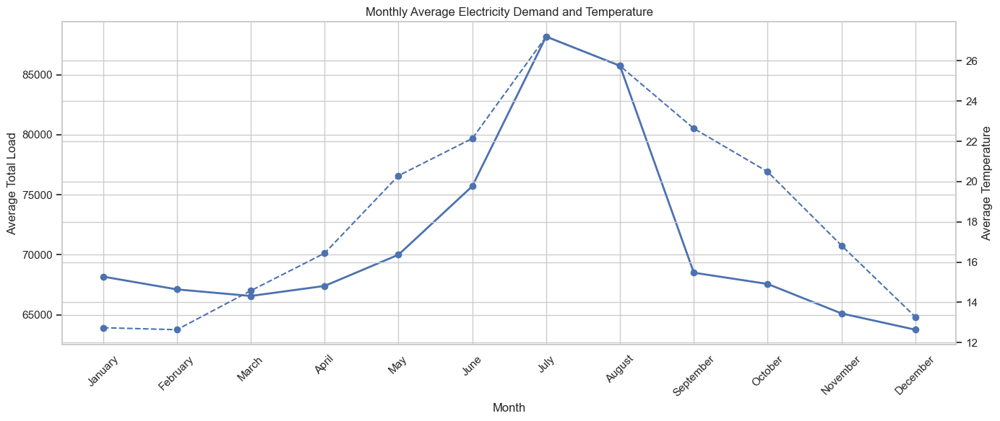

In [89]:
fig, ax1 = plt.subplots(figsize=(14, 6))

ax1.plot(
    monthly_weather.index,
    monthly_weather["Total_Load"],
    marker="o",
    linewidth=2,
    label="Total Load"
)

ax1.set_xlabel("Month")
ax1.set_ylabel("Average Total Load")
ax1.tick_params(axis="x", rotation=45)

ax2 = ax1.twinx()

ax2.plot(
    monthly_weather.index,
    monthly_weather["Temperature"],
    marker="o",
    linestyle="--",
    label="Temperature"
)

ax2.set_ylabel("Average Temperature")

plt.title(
    "Monthly Average Electricity Demand and Temperature"
)

plt.tight_layout()
plt.show()

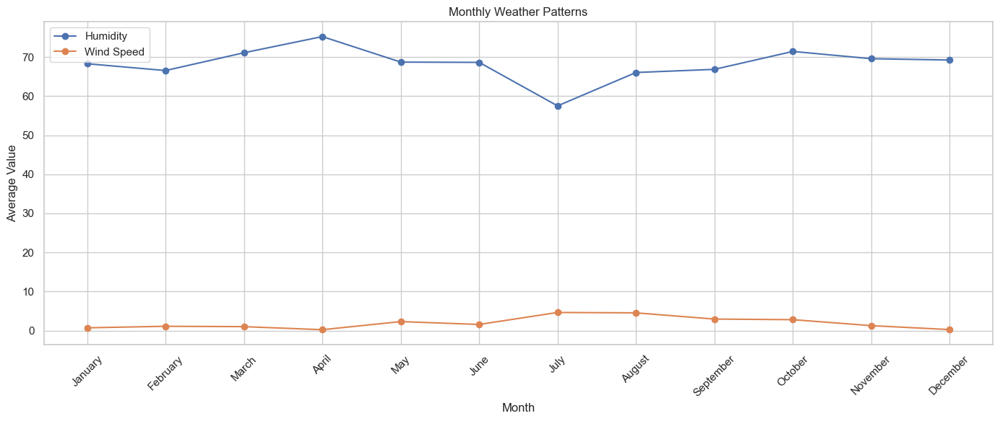

In [90]:
fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(
    monthly_weather.index,
    monthly_weather["Humidity"],
    marker="o",
    label="Humidity"
)

ax.plot(
    monthly_weather.index,
    monthly_weather["WindSpeed"],
    marker="o",
    label="Wind Speed"
)

ax.set_title("Monthly Weather Patterns")
ax.set_xlabel("Month")
ax.set_ylabel("Average Value")
ax.tick_params(axis="x", rotation=45)
ax.legend()

plt.tight_layout()
plt.show()

In [91]:
temperature_hour_corr

,Hour,Temperature_Load_Correlation
0,0,0.672483
1,1,0.667826
2,2,0.638010
3,3,0.713396
4,4,0.773186
5,5,0.427098
6,6,0.291278
7,7,0.608176
8,8,0.672038
9,9,0.664079


In [92]:
display(monthly_weather)

,Temperature,Humidity,WindSpeed,Total_Load
Month,,,,
January,12.743092,68.294122,0.707927,68173.033601
February,12.644443,66.551322,1.096494,67108.548882
March,14.579907,71.100029,1.006189,66560.788896
April,16.444463,75.242521,0.224269,67396.902281
May,20.293564,68.712440,2.298271,69994.397979
June,22.142741,68.643398,1.566689,75707.410998
July,27.203685,57.508934,4.630617,88173.551711
August,25.748271,66.051290,4.534733,85740.300881
September,22.637787,66.852981,2.946210,68499.912449


In [93]:
# Count observations per calendar day

daily_record_counts = (
    df
    .set_index("Datetime_parsed")
    .resample("D")
    .size()
)

display(
    daily_record_counts.describe()
)

count    364.0
mean     144.0
std        0.0
min      144.0
25%      144.0
50%      144.0
75%      144.0
max      144.0
dtype: float64

In [94]:
print(
    "Days with fewer than 144 observations:",
    (daily_record_counts < 144).sum()
)

print(
    "Days with exactly 144 observations:",
    (daily_record_counts == 144).sum()
)

print(
    "Days with more than 144 observations:",
    (daily_record_counts > 144).sum()
)

Days with fewer than 144 observations: 0
Days with exactly 144 observations: 364
Days with more than 144 observations: 0


In [95]:
incomplete_days = daily_record_counts[
    daily_record_counts != 144
]

display(incomplete_days)

Series([], Freq: D, dtype: int64)

In [96]:
for col in load_columns:
    print(f"\n{col}")
    print("Zero values:", (df[col] == 0).sum())
    print("Negative values:", (df[col] < 0).sum())
    print("Missing values:", df[col].isna().sum())


F1_132KV_PowerConsumption
Zero values: 0
Negative values: 0
Missing values: 0

F2_132KV_PowerConsumption
Zero values: 0
Negative values: 0
Missing values: 0

F3_132KV_PowerConsumption
Zero values: 0
Negative values: 0
Missing values: 0


## Data Completeness and Physical Validity

The temporal completeness analysis confirms that every observed day contains
exactly 144 observations, corresponding to the expected 10-minute sampling
frequency:

- Days with fewer than 144 observations: 0
- Days with exactly 144 observations: 364
- Days with more than 144 observations: 0

Therefore, there are no incomplete days or excess observations in the available
time period.

The feeder load variables were also checked for physically invalid values.
All three feeders contain:

- 0 zero-valued observations
- 0 negative-valued observations
- 0 missing observations

This indicates that the supplied feeder load measurements are complete and
contain no immediately identifiable physically invalid values.

However, statistical anomalies identified during the earlier outlier analysis
are retained because the analysis showed that the elevated observations,
particularly in F3, coincide with periods of increased demand across multiple
feeders. Therefore, statistical outliers are not automatically considered
data errors.

Overall, the dataset has strong structural completeness and does not require
missing-value imputation or correction of zero/negative load values at this
stage.

In [98]:
# ============================================================
# Final Data Quality Summary
# ============================================================

quality_summary = pd.DataFrame({
    "Check": [
        "Total rows",
        "Total columns",
        "Missing values",
        "Duplicate rows",
        "Duplicate timestamps",
        "Days observed",
        "Complete days",
        "Incomplete days",
        "Zero load values",
        "Negative load values"
    ],
    "Result": [
        len(df),
        df.shape[1],
        int(df.isna().sum().sum()),
        int(df.duplicated().sum()),
        int(df["Datetime_parsed"].duplicated().sum()),
        len(daily_record_counts),
        int((daily_record_counts == 144).sum()),
        int((daily_record_counts != 144).sum()),
        int((df[load_columns] == 0).sum().sum()),
        int((df[load_columns] < 0).sum().sum())
    ]
})

display(quality_summary)

,Check,Result
0,Total rows,52416
1,Total columns,18
2,Missing values,1
3,Duplicate rows,0
4,Duplicate timestamps,0
5,Days observed,364
6,Complete days,364
7,Incomplete days,0
8,Zero load values,0
9,Negative load values,0


## Data Quality Conclusion

The dataset contains 52,416 observations collected at a 10-minute
resolution over 364 complete days.

The structural validation confirms that the dataset contains no missing
values, duplicate timestamps, incomplete days, zero load measurements, or
negative load measurements. Therefore, no general missing-value imputation or
timestamp-based gap filling is required.

The earlier statistical outlier analysis identified elevated observations,
particularly in feeder F3. These observations were investigated against
temporal patterns and the other feeders and were found to coincide with
periods of elevated system-wide demand. They are therefore retained rather
than removed.

The dataset is considered structurally suitable for the next stages of the
forecasting pipeline.

The next stage is to convert the load data to the required 30-minute
forecasting resolution and integrate Dhanbad-specific weather and
location-relevant holiday information from external public sources.

In [100]:
# Find exactly where the missing value is
missing_by_column = df.isna().sum()

missing_by_column = missing_by_column[missing_by_column > 0]

display(missing_by_column)

F3_pct_change    1
dtype: int64

In [101]:
# Show the exact row(s) containing the missing value
missing_rows = df[df.isna().any(axis=1)]

display(missing_rows.T)

,0
Datetime,01-01-2017 00:00
Temperature,6.559
Humidity,73.8
WindSpeed,0.083
F1_132KV_PowerConsumption,34055.6962
F2_132KV_PowerConsumption,16128.87538
F3_132KV_PowerConsumption,20240.96386
Datetime_parsed,2017-01-01 00:00:00
Total_Load,70425.53544
F3_pct_change,NaN


## Dhanbad Historical Weather Data

To provide location-specific weather information, historical weather data was
obtained for Dhanbad, Jharkhand rather than assuming that the weather variables
contained in the original electricity dataset represent Dhanbad.

The weather dataset corresponds to the following location:

- Latitude: 23.796133° N
- Longitude: 86.384770° E
- Elevation: 231 m
- Timezone: Asia/Kolkata (UTC+05:30)

The dataset contains hourly observations from 2017-01-01 00:00 through
2017-12-30 23:00, resulting in 8,736 hourly observations across 364 complete
days.

The weather variables used are:

- Temperature at 2 m (°C)
- Relative humidity (%)
- Cloud cover (%)
- Wind speed at 10 m (km/h)

These variables will be temporally aligned with the electricity-demand data
before being incorporated into the forecasting dataset.

The original weather variables present in the electricity CSV
(`Temperature`, `Humidity`, and `WindSpeed`) are retained only for preliminary
exploratory analysis because their geographic source is not documented.

In [103]:
# ============================================================
# Load Dhanbad Historical Weather Data
# ============================================================

WEATHER_PATH = "Desktop/exascaleAi/Project/Project - 1/dhanbad_waether.csv"

weather_raw = pd.read_csv(WEATHER_PATH, header=None)

display(weather_raw.head())

,0,1,2,3,4,5
0,latitude,longitude,elevation,utc_offset_seconds,timezone,timezone_abbreviation
1,23.796133,86.38477,231.0,19800,Asia/Kolkata,GMT+5:30
2,time,temperature_2m (°C),relative_humidity_2m (%),cloud_cover (%),wind_speed_10m (km/h),NaN
3,2017-01-01T00:00,14.8,89,18,6.8,NaN
4,2017-01-01T01:00,14.5,92,23,6.4,NaN


In [104]:
# ============================================================
# Load and Parse Dhanbad Historical Weather Data
# ============================================================

WEATHER_PATH = "Desktop/exascaleAi/Project/Project - 1/dhanbad_waether.csv"

# Read without assuming a header
weather_raw = pd.read_csv(
    WEATHER_PATH,
    header=None
)

print("Raw weather file shape:", weather_raw.shape)

# ------------------------------------------------------------
# Find the row containing the actual weather column names
# ------------------------------------------------------------

header_row = None

for i in range(min(10, len(weather_raw))):
    row_values = weather_raw.iloc[i].astype(str).str.strip().str.lower().tolist()

    if "time" in row_values:
        header_row = i
        break

if header_row is None:
    raise ValueError("Could not find the weather header row containing 'time'.")

print("Weather header row:", header_row)

# ------------------------------------------------------------
# Extract metadata
# ------------------------------------------------------------

metadata_row = weather_raw.iloc[0]

weather_metadata = {
    "latitude": metadata_row.iloc[0],
    "longitude": metadata_row.iloc[1],
    "elevation": metadata_row.iloc[2],
    "utc_offset_seconds": metadata_row.iloc[3],
    "timezone": metadata_row.iloc[4],
    "timezone_abbreviation": metadata_row.iloc[5]
}

print("\nWeather metadata:")
display(pd.DataFrame([weather_metadata]))

# ------------------------------------------------------------
# Extract weather data
# ------------------------------------------------------------

weather = weather_raw.iloc[header_row + 1:].copy()

# Use header row as column names
weather.columns = weather_raw.iloc[header_row].astype(str).str.strip()

# Remove completely empty columns
weather = weather.dropna(axis=1, how="all")

# Reset index
weather = weather.reset_index(drop=True)

print("\nWeather columns:")
print(weather.columns.tolist())

display(weather.head())

Raw weather file shape: (8739, 6)
Weather header row: 2

Weather metadata:


,latitude,longitude,elevation,utc_offset_seconds,timezone,timezone_abbreviation
0,latitude,longitude,elevation,utc_offset_seconds,timezone,timezone_abbreviation



Weather columns:
['time', 'temperature_2m (°C)', 'relative_humidity_2m (%)', 'cloud_cover (%)', 'wind_speed_10m (km/h)']


2,time,temperature_2m (°C),relative_humidity_2m (%),cloud_cover (%),wind_speed_10m (km/h)
0,2017-01-01T00:00,14.8,89,18,6.8
1,2017-01-01T01:00,14.5,92,23,6.4
2,2017-01-01T02:00,14.3,94,23,5.6
3,2017-01-01T03:00,14.2,95,21,6.2
4,2017-01-01T04:00,13.9,96,7,5.4


In [105]:
# Remove inherited Series/DataFrame index name from the CSV header row
weather.columns.name = None

In [106]:
display(weather.isna().sum())
display(weather.dtypes)

time                        0
temperature_2m (°C)         0
relative_humidity_2m (%)    0
cloud_cover (%)             0
wind_speed_10m (km/h)       0
dtype: int64

time                        object
temperature_2m (°C)         object
relative_humidity_2m (%)    object
cloud_cover (%)             object
wind_speed_10m (km/h)       object
dtype: object

In [107]:
print(weather.columns.tolist())

['time', 'temperature_2m (°C)', 'relative_humidity_2m (%)', 'cloud_cover (%)', 'wind_speed_10m (km/h)']


In [108]:
# ============================================================
# Clean Weather Variables
# ============================================================

# Convert timestamp
weather["time"] = pd.to_datetime(
    weather["time"],
    errors="coerce"
)

# Convert numerical weather variables
numeric_weather_columns = [
    "temperature_2m (°C)",
    "relative_humidity_2m (%)",
    "cloud_cover (%)",
    "wind_speed_10m (km/h)"
]

for col in numeric_weather_columns:
    weather[col] = pd.to_numeric(
        weather[col],
        errors="coerce"
    )

display(weather.head())

,time,temperature_2m (°C),relative_humidity_2m (%),cloud_cover (%),wind_speed_10m (km/h)
0,2017-01-01 00:00:00,14.8,89,18,6.8
1,2017-01-01 01:00:00,14.5,92,23,6.4
2,2017-01-01 02:00:00,14.3,94,23,5.6
3,2017-01-01 03:00:00,14.2,95,21,6.2
4,2017-01-01 04:00:00,13.9,96,7,5.4


In [109]:
# ============================================================
# Weather Data Validation
# ============================================================

print("Number of observations:", len(weather))

print(
    "Date range:",
    weather["time"].min(),
    "to",
    weather["time"].max()
)

print(
    "Duplicate timestamps:",
    weather["time"].duplicated().sum()
)

print("\nMissing values:")
display(weather.isna().sum())

print("\nWeather data types:")
display(weather.dtypes)

Number of observations: 8736
Date range: 2017-01-01 00:00:00 to 2017-12-30 23:00:00
Duplicate timestamps: 0

Missing values:


time                        0
temperature_2m (°C)         0
relative_humidity_2m (%)    0
cloud_cover (%)             0
wind_speed_10m (km/h)       0
dtype: int64


Weather data types:


time                        datetime64[ns]
temperature_2m (°C)                float64
relative_humidity_2m (%)             int64
cloud_cover (%)                      int64
wind_speed_10m (km/h)              float64
dtype: object

## Dhanbad Weather Data Quality Assessment

The Dhanbad-specific historical weather dataset contains 8,736 hourly
observations covering the same 364-day period as the electricity dataset,
from 2017-01-01 00:00 through 2017-12-30 23:00.

The expected number of observations is:

364 days × 24 hours = 8,736 observations.

The validation confirms that the weather dataset contains no duplicate
timestamps and no missing values across the timestamp, temperature, relative
humidity, cloud cover, or wind-speed variables.

The weather observations are therefore structurally complete and can be
aligned with the electricity-demand dataset in the subsequent processing
stage.

In [110]:
# ============================================================
# Weather Variable Range Validation
# ============================================================

weather_columns = {
    "Temperature": "temperature_2m (°C)",
    "Relative Humidity": "relative_humidity_2m (%)",
    "Cloud Cover": "cloud_cover (%)",
    "Wind Speed": "wind_speed_10m (km/h)"
}

weather_range_summary = pd.DataFrame({
    "Variable": weather_columns.keys(),
    "Minimum": [
        weather[col].min()
        for col in weather_columns.values()
    ],
    "Maximum": [
        weather[col].max()
        for col in weather_columns.values()
    ],
    "Mean": [
        weather[col].mean()
        for col in weather_columns.values()
    ]
})

display(weather_range_summary)

,Variable,Minimum,Maximum,Mean
0,Temperature,7.7,41.4,25.456582
1,Relative Humidity,8.0,100.0,69.520833
2,Cloud Cover,0.0,100.0,44.029647
3,Wind Speed,0.0,32.8,8.248981


In [111]:
# Check physically invalid percentage values

print(
    "Humidity outside 0-100%:",
    ((weather["relative_humidity_2m (%)"] < 0) |
     (weather["relative_humidity_2m (%)"] > 100)).sum()
)

print(
    "Cloud cover outside 0-100%:",
    ((weather["cloud_cover (%)"] < 0) |
     (weather["cloud_cover (%)"] > 100)).sum()
)

print(
    "Negative wind speed:",
    (weather["wind_speed_10m (km/h)"] < 0).sum()
)

Humidity outside 0-100%: 0
Cloud cover outside 0-100%: 0
Negative wind speed: 0


## Weather Variable Range and Physical Validity

The Dhanbad weather variables were further checked for physically invalid
values.

Temperature ranges from 7.7°C to 41.4°C, with an average of approximately
25.46°C. Relative humidity ranges from 8% to 100%, while cloud cover ranges
from 0% to 100%. Wind speed ranges from 0 to 32.8 km/h.

No relative-humidity observations fall outside the valid 0–100% range, no
cloud-cover observations fall outside the valid 0–100% range, and no negative
wind-speed observations were identified.

Combined with the previous completeness checks, the Dhanbad weather dataset
is considered structurally valid and suitable for integration with the
electricity-demand data.

In [112]:
# ============================================================
# Prepare Electricity Demand Data for 30-Minute Resolution
# ============================================================

load_30min = df[
    ["Datetime_parsed"] + load_columns
].copy()

load_30min = load_30min.sort_values("Datetime_parsed")

load_30min = load_30min.set_index("Datetime_parsed")

In [113]:
# ============================================================
# Aggregate 10-Minute Load to 30-Minute Load
# ============================================================

load_30min = (
    load_30min
    .resample("30min")
    .mean()
)

# Recalculate total system load after aggregation
load_30min["Total_Load"] = load_30min[load_columns].sum(axis=1)

load_30min = load_30min.reset_index()

display(load_30min.head(10))

,Datetime_parsed,F1_132KV_PowerConsumption,F2_132KV_PowerConsumption,F3_132KV_PowerConsumption,Total_Load
0,2017-01-01 00:00:00,30999.493670,18170.212767,20013.493977,69183.200413
1,2017-01-01 00:30:00,27396.455697,17883.282673,18490.602410,63770.340780
2,2017-01-01 01:00:00,25407.594937,16627.355623,17476.626507,59511.577067
3,2017-01-01 01:30:00,23906.835443,15529.483283,16609.156627,56045.475353
4,2017-01-01 02:00:00,22474.936707,14767.173253,15870.843373,53112.953333
5,2017-01-01 02:30:00,21691.139240,13894.224923,15481.445783,51066.809947
6,2017-01-01 03:00:00,20992.405063,13367.781153,15070.843373,49431.029590
7,2017-01-01 03:30:00,20629.873417,13071.124620,14696.867470,48397.865507
8,2017-01-01 04:00:00,20512.405063,12926.443767,14423.132530,47861.981360
9,2017-01-01 04:30:00,20439.493670,12916.717327,14211.084337,47567.295333


In [114]:
# ============================================================
# Validate 30-Minute Dataset
# ============================================================

print("Number of 30-minute observations:", len(load_30min))

print(
    "Date range:",
    load_30min["Datetime_parsed"].min(),
    "to",
    load_30min["Datetime_parsed"].max()
)

print(
    "Duplicate timestamps:",
    load_30min["Datetime_parsed"].duplicated().sum()
)

# Expected number of observations
expected_30min_rows = 364 * 48

print("Expected observations:", expected_30min_rows)
print("Actual observations:", len(load_30min))

Number of 30-minute observations: 17472
Date range: 2017-01-01 00:00:00 to 2017-12-30 23:30:00
Duplicate timestamps: 0
Expected observations: 17472
Actual observations: 17472


In [115]:
# Check that every day contains exactly 48 half-hour observations

half_hour_counts = (
    load_30min
    .set_index("Datetime_parsed")
    .resample("D")
    .size()
)

print("Days with exactly 48 observations:",
      (half_hour_counts == 48).sum())

print("Days with incomplete observations:",
      (half_hour_counts != 48).sum())

display(half_hour_counts.value_counts().sort_index())

Days with exactly 48 observations: 364
Days with incomplete observations: 0


48    364
Name: count, dtype: int64

## 30-Minute Demand Aggregation

The original electricity dataset contains measurements at 10-minute intervals.
Since the forecasting objective is to predict electricity demand in 30-minute
blocks, the three feeder load measurements were aggregated into half-hour
intervals using the arithmetic mean.

The resulting dataset contains 17,472 observations:

364 days × 48 half-hour intervals per day = 17,472 observations.

The resulting dataset covers the period from 2017-01-01 00:00 through
2017-12-30 23:30.

A completeness check confirms that all 364 days contain exactly 48
half-hour observations, with no incomplete days or duplicate timestamps.

The total system demand is calculated after aggregation as the sum of the
three feeder-level average loads:

Total_Load = F1 + F2 + F3

This 30-minute dataset will serve as the demand component of the final
forecasting dataset.

In [116]:
# ============================================================
# Prepare Dhanbad Weather Data for 30-Minute Alignment
# ============================================================

weather_30min = weather[
    [
        "time",
        "temperature_2m (°C)",
        "relative_humidity_2m (%)",
        "cloud_cover (%)",
        "wind_speed_10m (km/h)"
    ]
].copy()

weather_30min = weather_30min.rename(columns={
    "time": "Datetime",
    "temperature_2m (°C)": "Dhanbad_Temperature",
    "relative_humidity_2m (%)": "Dhanbad_Humidity",
    "cloud_cover (%)": "Dhanbad_CloudCover",
    "wind_speed_10m (km/h)": "Dhanbad_WindSpeed"
})

weather_30min = weather_30min.sort_values("Datetime")

weather_30min = weather_30min.set_index("Datetime")

In [117]:
# ============================================================
# Interpolate Hourly Weather to 30-Minute Resolution
# ============================================================

weather_30min = weather_30min.resample("30min").interpolate(
    method="time"
)

weather_30min = weather_30min.reset_index()

display(weather_30min.head(10))

,Datetime,Dhanbad_Temperature,Dhanbad_Humidity,Dhanbad_CloudCover,Dhanbad_WindSpeed
0,2017-01-01 00:00:00,14.80,89.0,18.0,6.8
1,2017-01-01 00:30:00,14.65,90.5,20.5,6.6
2,2017-01-01 01:00:00,14.50,92.0,23.0,6.4
3,2017-01-01 01:30:00,14.40,93.0,23.0,6.0
4,2017-01-01 02:00:00,14.30,94.0,23.0,5.6
5,2017-01-01 02:30:00,14.25,94.5,22.0,5.9
6,2017-01-01 03:00:00,14.20,95.0,21.0,6.2
7,2017-01-01 03:30:00,14.05,95.5,14.0,5.8
8,2017-01-01 04:00:00,13.90,96.0,7.0,5.4
9,2017-01-01 04:30:00,14.25,94.5,4.0,5.5


In [118]:
# ============================================================
# Validate 30-Minute Weather Dataset
# ============================================================

print("Weather observations:", len(weather_30min))

print(
    "Date range:",
    weather_30min["Datetime"].min(),
    "to",
    weather_30min["Datetime"].max()
)

print(
    "Duplicate timestamps:",
    weather_30min["Datetime"].duplicated().sum()
)

print("\nMissing values:")
display(weather_30min.isna().sum())

Weather observations: 17471
Date range: 2017-01-01 00:00:00 to 2017-12-30 23:00:00
Duplicate timestamps: 0

Missing values:


Datetime               0
Dhanbad_Temperature    0
Dhanbad_Humidity       0
Dhanbad_CloudCover     0
Dhanbad_WindSpeed      0
dtype: int64

In [119]:
WEATHER_PATH = "Desktop/exascaleAi/Project/Project - 1/updated with 31st dec.csv"

weather_raw = pd.read_csv(
    WEATHER_PATH,
    header=None
)

header_row = None

for i in range(min(10, len(weather_raw))):
    row_values = (
        weather_raw.iloc[i]
        .astype(str)
        .str.strip()
        .str.lower()
        .tolist()
    )

    if "time" in row_values:
        header_row = i
        break

if header_row is None:
    raise ValueError("Could not find weather header row.")

weather = weather_raw.iloc[header_row + 1:].copy()
weather.columns = weather_raw.iloc[header_row].astype(str).str.strip()
weather = weather.dropna(axis=1, how="all")
weather = weather.reset_index(drop=True)

weather["time"] = pd.to_datetime(
    weather["time"],
    errors="coerce"
)

numeric_weather_columns = [
    "temperature_2m (°C)",
    "relative_humidity_2m (%)",
    "cloud_cover (%)",
    "wind_speed_10m (km/h)"
]

for col in numeric_weather_columns:
    weather[col] = pd.to_numeric(
        weather[col],
        errors="coerce"
    )

weather.columns.name = None

In [120]:
print("Weather observations:", len(weather))
print("Start:", weather["time"].min())
print("End:", weather["time"].max())

Weather observations: 8760
Start: 2017-01-01 00:00:00
End: 2017-12-31 23:00:00


In [121]:
weather_30min = weather[
    [
        "time",
        "temperature_2m (°C)",
        "relative_humidity_2m (%)",
        "cloud_cover (%)",
        "wind_speed_10m (km/h)"
    ]
].copy()

weather_30min = weather_30min.rename(columns={
    "time": "Datetime",
    "temperature_2m (°C)": "Dhanbad_Temperature",
    "relative_humidity_2m (%)": "Dhanbad_Humidity",
    "cloud_cover (%)": "Dhanbad_CloudCover",
    "wind_speed_10m (km/h)": "Dhanbad_WindSpeed"
})

weather_30min = (
    weather_30min
    .sort_values("Datetime")
    .set_index("Datetime")
    .resample("30min")
    .interpolate(method="time")
    .reset_index()
)

In [122]:
weather_30min = weather_30min[
    (weather_30min["Datetime"] >= load_30min["Datetime_parsed"].min()) &
    (weather_30min["Datetime"] <= load_30min["Datetime_parsed"].max())
].copy()

In [123]:
print("Weather observations:", len(weather_30min))

print(
    "Date range:",
    weather_30min["Datetime"].min(),
    "to",
    weather_30min["Datetime"].max()
)

print(
    "Duplicate timestamps:",
    weather_30min["Datetime"].duplicated().sum()
)

display(weather_30min.isna().sum())

Weather observations: 17472
Date range: 2017-01-01 00:00:00 to 2017-12-30 23:30:00
Duplicate timestamps: 0


Datetime               0
Dhanbad_Temperature    0
Dhanbad_Humidity       0
Dhanbad_CloudCover     0
Dhanbad_WindSpeed      0
dtype: int64

In [124]:
# ============================================================
# Final 30-Minute Weather Validation
# ============================================================

print("Weather observations:", len(weather_30min))

print(
    "Date range:",
    weather_30min["Datetime"].min(),
    "to",
    weather_30min["Datetime"].max()
)

print(
    "Duplicate timestamps:",
    weather_30min["Datetime"].duplicated().sum()
)

print("\nMissing values:")
display(weather_30min.isna().sum())

print("\nExpected observations:", len(load_30min))
print("Actual observations:", len(weather_30min))

Weather observations: 17472
Date range: 2017-01-01 00:00:00 to 2017-12-30 23:30:00
Duplicate timestamps: 0

Missing values:


Datetime               0
Dhanbad_Temperature    0
Dhanbad_Humidity       0
Dhanbad_CloudCover     0
Dhanbad_WindSpeed      0
dtype: int64


Expected observations: 17472
Actual observations: 17472


## Integration of Electricity Demand and Dhanbad Weather

The electricity-demand and Dhanbad weather datasets have both been
standardized to 30-minute intervals covering the same observation period.

The electricity dataset contains 17,472 half-hour observations, and the
Dhanbad weather dataset contains the same number of observations.

The datasets are therefore merged using the common timestamp. A one-to-one
timestamp relationship is expected, ensuring that every electricity-demand
observation receives exactly one corresponding set of Dhanbad weather
variables.

The resulting integrated dataset will contain feeder-level demand, total
system demand, and location-specific weather variables.

In [125]:
# ============================================================
# Merge Electricity Demand and Dhanbad Weather
# ============================================================

integrated_df = load_30min.merge(
    weather_30min,
    left_on="Datetime_parsed",
    right_on="Datetime",
    how="inner",
    validate="one_to_one"
)

# Remove duplicate timestamp column
integrated_df = integrated_df.drop(columns=["Datetime"])

# Rename timestamp consistently
integrated_df = integrated_df.rename(
    columns={"Datetime_parsed": "Datetime"}
)

integrated_df = integrated_df.sort_values("Datetime").reset_index(drop=True)

display(integrated_df.head())

,Datetime,F1_132KV_PowerConsumption,F2_132KV_PowerConsumption,F3_132KV_PowerConsumption,Total_Load,Dhanbad_Temperature,Dhanbad_Humidity,Dhanbad_CloudCover,Dhanbad_WindSpeed
0,2017-01-01 00:00:00,30999.493670,18170.212767,20013.493977,69183.200413,14.80,89.0,18.0,6.8
1,2017-01-01 00:30:00,27396.455697,17883.282673,18490.602410,63770.340780,14.65,90.5,20.5,6.6
2,2017-01-01 01:00:00,25407.594937,16627.355623,17476.626507,59511.577067,14.50,92.0,23.0,6.4
3,2017-01-01 01:30:00,23906.835443,15529.483283,16609.156627,56045.475353,14.40,93.0,23.0,6.0
4,2017-01-01 02:00:00,22474.936707,14767.173253,15870.843373,53112.953333,14.30,94.0,23.0,5.6


In [126]:
# ============================================================
# Validate Integrated Dataset
# ============================================================

print("Integrated observations:", len(integrated_df))

print(
    "Date range:",
    integrated_df["Datetime"].min(),
    "to",
    integrated_df["Datetime"].max()
)

print(
    "Duplicate timestamps:",
    integrated_df["Datetime"].duplicated().sum()
)

print("\nMissing values:")
display(integrated_df.isna().sum())

Integrated observations: 17472
Date range: 2017-01-01 00:00:00 to 2017-12-30 23:30:00
Duplicate timestamps: 0

Missing values:


Datetime                     0
F1_132KV_PowerConsumption    0
F2_132KV_PowerConsumption    0
F3_132KV_PowerConsumption    0
Total_Load                   0
Dhanbad_Temperature          0
Dhanbad_Humidity             0
Dhanbad_CloudCover           0
Dhanbad_WindSpeed            0
dtype: int64

In [127]:
# ============================================================
# Check Timestamp Coverage After Merge
# ============================================================

electricity_times = set(load_30min["Datetime_parsed"])
weather_times = set(weather_30min["Datetime"])

merged_times = set(integrated_df["Datetime"])

print(
    "Electricity timestamps missing after merge:",
    len(electricity_times - merged_times)
)

print(
    "Weather timestamps missing after merge:",
    len(weather_times - merged_times)
)

print(
    "Common timestamps:",
    len(electricity_times & weather_times)
)

Electricity timestamps missing after merge: 0
Weather timestamps missing after merge: 0
Common timestamps: 17472


In [128]:
print("Integrated dataset shape:", integrated_df.shape)

print("\nColumns:")
for i, col in enumerate(integrated_df.columns, start=1):
    print(f"{i}. {col}")

Integrated dataset shape: (17472, 9)

Columns:
1. Datetime
2. F1_132KV_PowerConsumption
3. F2_132KV_PowerConsumption
4. F3_132KV_PowerConsumption
5. Total_Load
6. Dhanbad_Temperature
7. Dhanbad_Humidity
8. Dhanbad_CloudCover
9. Dhanbad_WindSpeed


In [129]:
# ============================================================
# 2017 Jharkhand Holiday Calendar
# ============================================================

holiday_data = [
    ("2017-01-12", "Sohrai", "Festival", "Jharkhand", 1),
    ("2017-01-26", "Republic Day", "National", "Jharkhand", 1),
    ("2017-02-24", "Maha Shivratri", "Festival", "Jharkhand", 1),
    ("2017-03-13", "Holi", "Festival", "Jharkhand", 1),
    ("2017-03-30", "Sarhul", "Regional Festival", "Jharkhand", 1),
    ("2017-04-05", "Ram Navami", "Festival", "Jharkhand", 1),
    ("2017-04-09", "Mahavir Jayanti", "Festival", "Jharkhand", 1),
    ("2017-04-09", "Littipara By-election", "Local/Public", "Local Area", 1),
    ("2017-04-14", "Good Friday", "Religious", "Jharkhand", 1),
    ("2017-05-01", "Labour Day", "Public/Regional", "Jharkhand", 1),
    ("2017-08-14", "Janmashtami", "Festival", "Jharkhand", 1),
    ("2017-08-15", "Independence Day", "National", "Jharkhand", 1),
    ("2017-09-02", "Bakrid", "Religious", "Jharkhand", 1),
    ("2017-09-17", "Karam", "Regional Festival", "Jharkhand", 1),
    ("2017-09-30", "Dussehra/Vijaya Dashami", "Festival", "Jharkhand", 1),
    ("2017-10-01", "Ashura/Muharram", "Religious", "Jharkhand", 1),
    ("2017-10-02", "Gandhi Jayanti", "National", "Jharkhand", 1),
    ("2017-10-19", "Diwali", "Festival", "Jharkhand", 1),
    ("2017-11-04", "Guru Nanak Jayanti", "Religious", "Jharkhand", 1),
    ("2017-12-25", "Christmas", "Religious", "Jharkhand", 1),
]

holidays = pd.DataFrame(
    holiday_data,
    columns=[
        "Date",
        "Holiday_Name",
        "Holiday_Type",
        "Scope",
        "Is_Public_Holiday"
    ]
)

holidays["Date"] = pd.to_datetime(holidays["Date"])

display(holidays)

,Date,Holiday_Name,Holiday_Type,Scope,Is_Public_Holiday
0,2017-01-12,Sohrai,Festival,Jharkhand,1
1,2017-01-26,Republic Day,National,Jharkhand,1
2,2017-02-24,Maha Shivratri,Festival,Jharkhand,1
3,2017-03-13,Holi,Festival,Jharkhand,1
4,2017-03-30,Sarhul,Regional Festival,Jharkhand,1
5,2017-04-05,Ram Navami,Festival,Jharkhand,1
6,2017-04-09,Mahavir Jayanti,Festival,Jharkhand,1
7,2017-04-09,Littipara By-election,Local/Public,Local Area,1
8,2017-04-14,Good Friday,Religious,Jharkhand,1
9,2017-05-01,Labour Day,Public/Regional,Jharkhand,1


In [130]:
print("Number of holiday records:", len(holidays))
print("Unique holiday dates:", holidays["Date"].nunique())

display(
    holidays.sort_values("Date").reset_index(drop=True)
)

Number of holiday records: 20
Unique holiday dates: 19


,Date,Holiday_Name,Holiday_Type,Scope,Is_Public_Holiday
0,2017-01-12,Sohrai,Festival,Jharkhand,1
1,2017-01-26,Republic Day,National,Jharkhand,1
2,2017-02-24,Maha Shivratri,Festival,Jharkhand,1
3,2017-03-13,Holi,Festival,Jharkhand,1
4,2017-03-30,Sarhul,Regional Festival,Jharkhand,1
5,2017-04-05,Ram Navami,Festival,Jharkhand,1
6,2017-04-09,Mahavir Jayanti,Festival,Jharkhand,1
7,2017-04-09,Littipara By-election,Local/Public,Local Area,1
8,2017-04-14,Good Friday,Religious,Jharkhand,1
9,2017-05-01,Labour Day,Public/Regional,Jharkhand,1


In [131]:
# ============================================================
# Consolidate Multiple Holiday Events on the Same Date
# ============================================================

holidays_daily = (
    holidays
    .sort_values("Date")
    .groupby("Date", as_index=False)
    .agg({
        "Holiday_Name": lambda x: "; ".join(x),
        "Holiday_Type": lambda x: "; ".join(x),
        "Scope": lambda x: "; ".join(x),
        "Is_Public_Holiday": "max"
    })
)

display(holidays_daily)

,Date,Holiday_Name,Holiday_Type,Scope,Is_Public_Holiday
0,2017-01-12,Sohrai,Festival,Jharkhand,1
1,2017-01-26,Republic Day,National,Jharkhand,1
2,2017-02-24,Maha Shivratri,Festival,Jharkhand,1
3,2017-03-13,Holi,Festival,Jharkhand,1
4,2017-03-30,Sarhul,Regional Festival,Jharkhand,1
5,2017-04-05,Ram Navami,Festival,Jharkhand,1
6,2017-04-09,Mahavir Jayanti; Littipara By-election,Festival; Local/Public,Jharkhand; Local Area,1
7,2017-04-14,Good Friday,Religious,Jharkhand,1
8,2017-05-01,Labour Day,Public/Regional,Jharkhand,1
9,2017-08-14,Janmashtami,Festival,Jharkhand,1


In [132]:
print("Holiday records before consolidation:", len(holidays))
print("Holiday dates after consolidation:", len(holidays_daily))

print(
    "Duplicate holiday dates:",
    holidays_daily["Date"].duplicated().sum()
)

Holiday records before consolidation: 20
Holiday dates after consolidation: 19
Duplicate holiday dates: 0


In [133]:
# ============================================================
# Prepare Date Key for Holiday Integration
# ============================================================

integrated_df["Date"] = integrated_df["Datetime"].dt.normalize()

display(
    integrated_df[["Datetime", "Date"]].head()
)

,Datetime,Date
0,2017-01-01 00:00:00,2017-01-01
1,2017-01-01 00:30:00,2017-01-01
2,2017-01-01 01:00:00,2017-01-01
3,2017-01-01 01:30:00,2017-01-01
4,2017-01-01 02:00:00,2017-01-01


In [134]:
# ============================================================
# Merge Holiday Information
# ============================================================

integrated_df = integrated_df.merge(
    holidays_daily,
    on="Date",
    how="left",
    validate="many_to_one"
)

# Fill non-holiday observations
integrated_df["Holiday_Name"] = (
    integrated_df["Holiday_Name"]
    .fillna("No Holiday")
)

integrated_df["Holiday_Type"] = (
    integrated_df["Holiday_Type"]
    .fillna("None")
)

integrated_df["Scope"] = (
    integrated_df["Scope"]
    .fillna("None")
)

integrated_df["Is_Public_Holiday"] = (
    integrated_df["Is_Public_Holiday"]
    .fillna(0)
    .astype(int)
)

display(integrated_df.head())

,Datetime,F1_132KV_PowerConsumption,F2_132KV_PowerConsumption,F3_132KV_PowerConsumption,Total_Load,Dhanbad_Temperature,Dhanbad_Humidity,Dhanbad_CloudCover,Dhanbad_WindSpeed,Date,Holiday_Name,Holiday_Type,Scope,Is_Public_Holiday
0,2017-01-01 00:00:00,30999.493670,18170.212767,20013.493977,69183.200413,14.80,89.0,18.0,6.8,2017-01-01,No Holiday,None,None,0
1,2017-01-01 00:30:00,27396.455697,17883.282673,18490.602410,63770.340780,14.65,90.5,20.5,6.6,2017-01-01,No Holiday,None,None,0
2,2017-01-01 01:00:00,25407.594937,16627.355623,17476.626507,59511.577067,14.50,92.0,23.0,6.4,2017-01-01,No Holiday,None,None,0
3,2017-01-01 01:30:00,23906.835443,15529.483283,16609.156627,56045.475353,14.40,93.0,23.0,6.0,2017-01-01,No Holiday,None,None,0
4,2017-01-01 02:00:00,22474.936707,14767.173253,15870.843373,53112.953333,14.30,94.0,23.0,5.6,2017-01-01,No Holiday,None,None,0


In [135]:
# ============================================================
# Validate Holiday Integration
# ============================================================

print("Rows after holiday merge:", len(integrated_df))

print(
    "Expected rows:",
    len(load_30min)
)

print(
    "Duplicate timestamps:",
    integrated_df["Datetime"].duplicated().sum()
)

print("\nMissing values:")
display(integrated_df.isna().sum())

Rows after holiday merge: 17472
Expected rows: 17472
Duplicate timestamps: 0

Missing values:


Datetime                     0
F1_132KV_PowerConsumption    0
F2_132KV_PowerConsumption    0
F3_132KV_PowerConsumption    0
Total_Load                   0
Dhanbad_Temperature          0
Dhanbad_Humidity             0
Dhanbad_CloudCover           0
Dhanbad_WindSpeed            0
Date                         0
Holiday_Name                 0
Holiday_Type                 0
Scope                        0
Is_Public_Holiday            0
dtype: int64

In [136]:
# ============================================================
# Holiday Observation Summary
# ============================================================

holiday_observation_summary = (
    integrated_df[integrated_df["Is_Public_Holiday"] == 1]
    .groupby(["Date", "Holiday_Name"])
    .size()
    .reset_index(name="Half_Hour_Observations")
)

display(holiday_observation_summary)

,Date,Holiday_Name,Half_Hour_Observations
0,2017-01-12,Sohrai,48
1,2017-01-26,Republic Day,48
2,2017-02-24,Maha Shivratri,48
3,2017-03-13,Holi,48
4,2017-03-30,Sarhul,48
5,2017-04-05,Ram Navami,48
6,2017-04-09,Mahavir Jayanti; Littipara By-election,48
7,2017-04-14,Good Friday,48
8,2017-05-01,Labour Day,48
9,2017-08-14,Janmashtami,48


In [137]:
print(
    "Total half-hour observations marked as public holiday:",
    integrated_df["Is_Public_Holiday"].sum()
)

print(
    "Number of unique public holiday dates:",
    integrated_df.loc[
        integrated_df["Is_Public_Holiday"] == 1,
        "Date"
    ].nunique()
)

Total half-hour observations marked as public holiday: 912
Number of unique public holiday dates: 19


## Final Integrated Dataset Validation

The electricity-demand, Dhanbad-specific weather, and 2017 Jharkhand holiday
datasets have been successfully integrated at a 30-minute temporal resolution.

The final integrated dataset contains 17,472 observations covering the complete
available period from 2017-01-01 00:00 through 2017-12-30 23:30.

The integration produced:

- 0 duplicate timestamps
- 0 missing values
- 0 lost electricity timestamps
- 0 lost weather timestamps
- 19 unique public-holiday dates
- 912 half-hour observations identified as public-holiday periods

The holiday calendar was consolidated by date before merging. This prevented
multiple holiday events occurring on the same date, such as Mahavir Jayanti
and the Littipara by-election on 2017-04-09, from creating duplicate
half-hour observations.

The resulting dataset provides a consistent foundation containing electricity
demand, Dhanbad-specific weather conditions, and calendar/holiday information.

In [139]:
# ============================================================
# Save Integrated Dataset
# ============================================================

import os

os.makedirs("Desktop/exascaleAi/Project/Project - 1", exist_ok=True)

INTEGRATED_PATH = "Desktop/exascaleAi/Project/Project - 1/integrated_demand_weather_holidays.csv"

integrated_df.to_csv(
    INTEGRATED_PATH,
    index=False
)

print("Saved integrated dataset to:")
print(INTEGRATED_PATH)

print("Shape:", integrated_df.shape)

Saved integrated dataset to:
Desktop/exascaleAi/Project/Project - 1/integrated_demand_weather_holidays.csv
Shape: (17472, 14)


In [140]:
weather_columns = [
    "Dhanbad_Temperature",
    "Dhanbad_Humidity",
    "Dhanbad_CloudCover",
    "Dhanbad_WindSpeed"
]

weather_summary = integrated_df[weather_columns].describe().T

display(weather_summary)

,count,mean,std,min,25%,50%,75%,max
Dhanbad_Temperature,17472.0,25.456576,5.840197,7.7,22.05,26.1,28.9,41.4
Dhanbad_Humidity,17472.0,69.520490,21.867104,8.0,54.50,75.0,87.5,100.0
Dhanbad_CloudCover,17472.0,44.031078,42.305443,0.0,0.00,31.0,95.5,100.0
Dhanbad_WindSpeed,17472.0,8.249096,4.063906,0.0,5.40,7.6,10.4,32.8


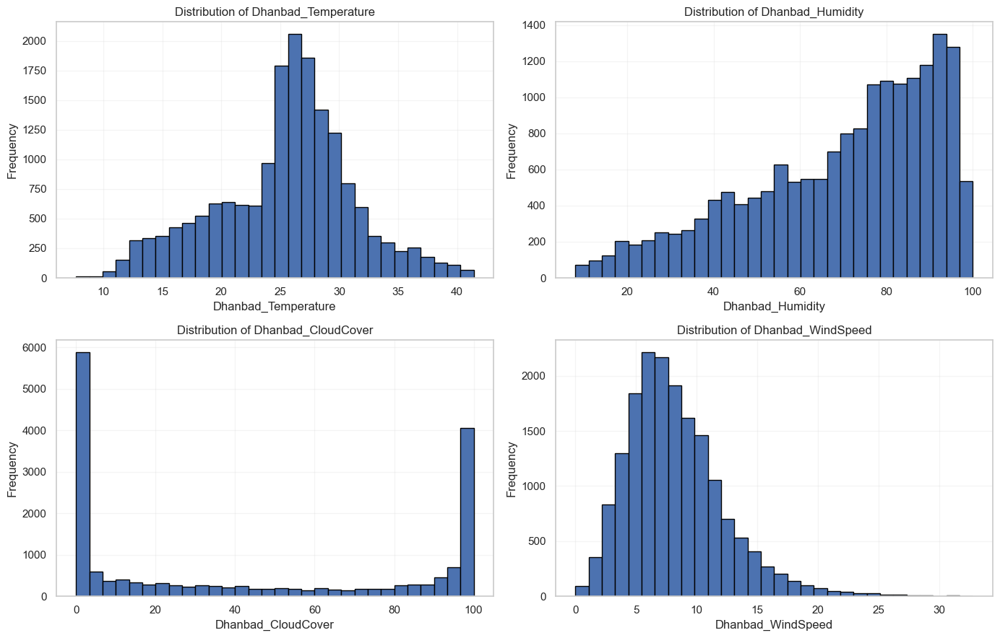

In [141]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))

for ax, column in zip(axes.flatten(), weather_columns):
    ax.hist(
        integrated_df[column],
        bins=30,
        edgecolor="black"
    )
    ax.set_title(f"Distribution of {column}")
    ax.set_xlabel(column)
    ax.set_ylabel("Frequency")
    ax.grid(alpha=0.2)

plt.tight_layout()
plt.show()

In [142]:
weather_monthly_df = integrated_df.copy()

weather_monthly_df["Month_Num"] = (
    weather_monthly_df["Datetime"].dt.month
)

monthly_weather = (
    weather_monthly_df
    .groupby("Month_Num")
    .agg(
        Temperature=("Dhanbad_Temperature", "mean"),
        Humidity=("Dhanbad_Humidity", "mean"),
        CloudCover=("Dhanbad_CloudCover", "mean"),
        WindSpeed=("Dhanbad_WindSpeed", "mean"),
        Total_Load=("Total_Load", "mean")
    )
    .reset_index()
)

display(monthly_weather)

,Month_Num,Temperature,Humidity,CloudCover,WindSpeed,Total_Load
0,1,18.021841,66.410954,15.092070,8.313542,68173.033601
1,2,21.825595,51.821057,6.709821,8.176190,67108.548882
2,3,25.527050,48.364919,16.375000,8.841835,66560.788896
3,4,30.606181,48.099653,16.893403,10.393333,67396.902281
4,5,30.940020,64.874328,34.438508,8.852688,69994.397979
5,6,30.287778,72.157639,79.375694,8.774444,75707.410998
6,7,27.046673,87.372984,92.767137,8.327151,88173.551711
7,8,27.446808,85.876344,88.863911,8.903192,85740.300881
8,9,27.722847,85.603125,76.997917,5.986875,68499.912449
9,10,25.498488,82.679772,47.061156,7.430007,67560.748669


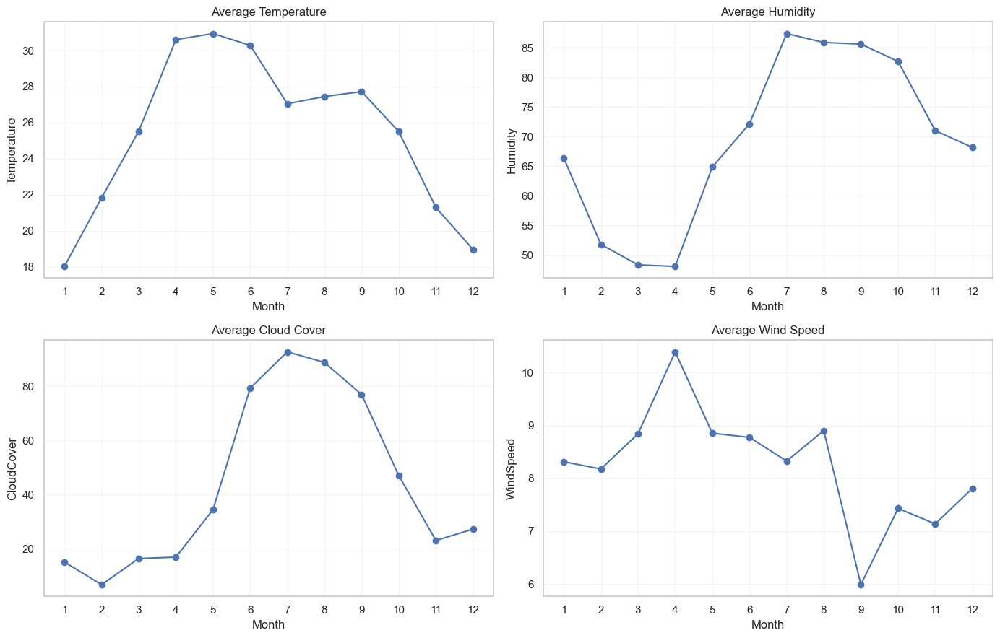

In [143]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))

weather_plot_columns = [
    ("Temperature", "Average Temperature"),
    ("Humidity", "Average Humidity"),
    ("CloudCover", "Average Cloud Cover"),
    ("WindSpeed", "Average Wind Speed")
]

for ax, (column, title) in zip(
    axes.flatten(),
    weather_plot_columns
):
    ax.plot(
        monthly_weather["Month_Num"],
        monthly_weather[column],
        marker="o"
    )
    ax.set_title(title)
    ax.set_xlabel("Month")
    ax.set_ylabel(column)
    ax.set_xticks(range(1, 13))
    ax.grid(alpha=0.2)

plt.tight_layout()
plt.show()

In [144]:
weather_corr_columns = [
    "Total_Load",
    "Dhanbad_Temperature",
    "Dhanbad_Humidity",
    "Dhanbad_CloudCover",
    "Dhanbad_WindSpeed"
]

weather_correlation = (
    integrated_df[weather_corr_columns]
    .corr()["Total_Load"]
    .sort_values(ascending=False)
)

display(weather_correlation)

Total_Load             1.000000
Dhanbad_CloudCover     0.297801
Dhanbad_Temperature    0.254702
Dhanbad_WindSpeed      0.149635
Dhanbad_Humidity       0.012400
Name: Total_Load, dtype: float64

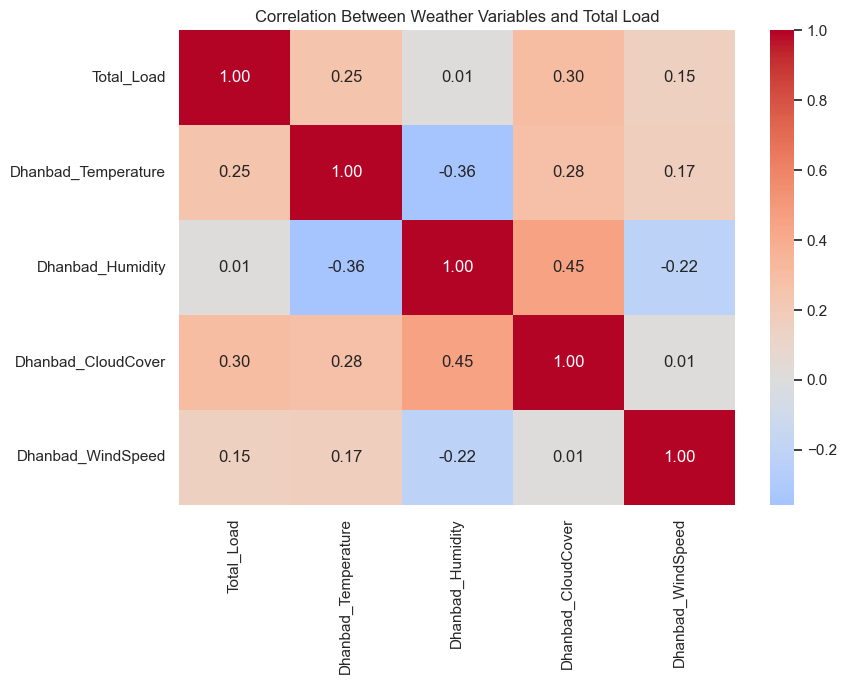

In [145]:
plt.figure(figsize=(9, 7))

sns.heatmap(
    integrated_df[weather_corr_columns].corr(),
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Between Weather Variables and Total Load")
plt.tight_layout()
plt.show()

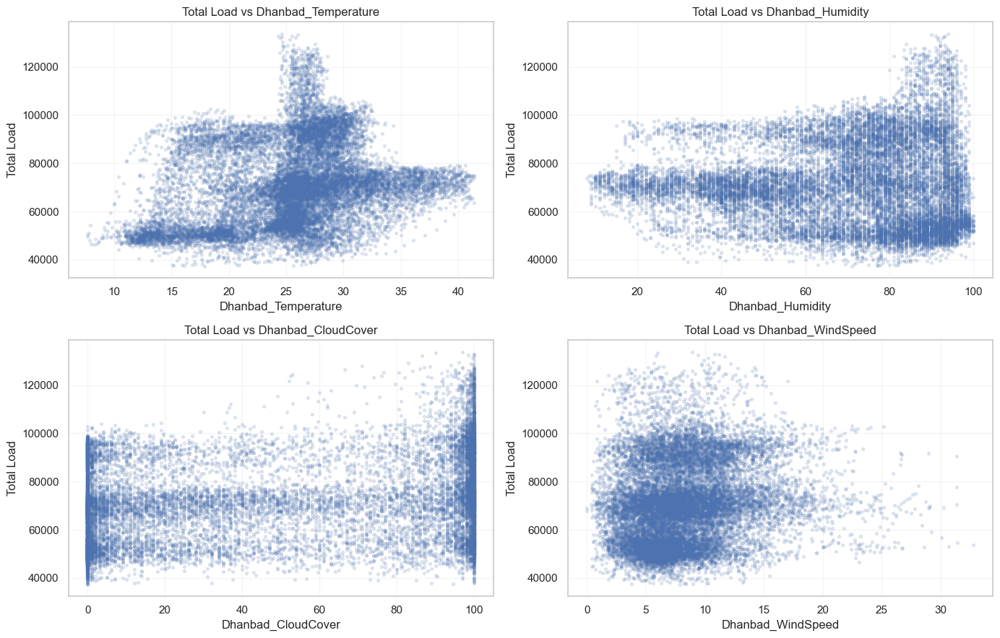

In [146]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))

for ax, column in zip(axes.flatten(), weather_columns):
    ax.scatter(
        integrated_df[column],
        integrated_df["Total_Load"],
        alpha=0.15,
        s=8
    )
    ax.set_title(f"Total Load vs {column}")
    ax.set_xlabel(column)
    ax.set_ylabel("Total Load")
    ax.grid(alpha=0.2)

plt.tight_layout()
plt.show()

In [147]:
hourly_weather = integrated_df.copy()

hourly_weather["Hour"] = (
    hourly_weather["Datetime"].dt.hour
)

hourly_weather_summary = (
    hourly_weather
    .groupby("Hour")
    .agg(
        Temperature=("Dhanbad_Temperature", "mean"),
        Humidity=("Dhanbad_Humidity", "mean"),
        CloudCover=("Dhanbad_CloudCover", "mean"),
        WindSpeed=("Dhanbad_WindSpeed", "mean"),
        Total_Load=("Total_Load", "mean")
    )
    .reset_index()
)

display(hourly_weather_summary)

,Hour,Temperature,Humidity,CloudCover,WindSpeed,Total_Load
0,0,22.432486,81.243132,42.287775,7.519162,68566.531733
1,1,22.049931,82.811126,41.664148,7.375549,62301.416675
2,2,21.739148,83.947802,42.111264,7.247459,59003.941184
3,3,21.454327,84.967720,43.260989,7.157349,56629.313141
4,4,21.260989,86.111264,43.956731,7.114629,54928.696874
5,5,21.449382,86.868819,43.294643,7.110989,51638.865007
6,6,22.579052,82.122253,42.625000,7.444643,50189.895727
7,7,24.438462,74.743132,40.960165,7.501580,51425.332877
8,8,26.382349,67.075549,39.557692,7.502541,56906.726907
9,9,27.982005,60.800137,38.853022,7.885920,63844.345711


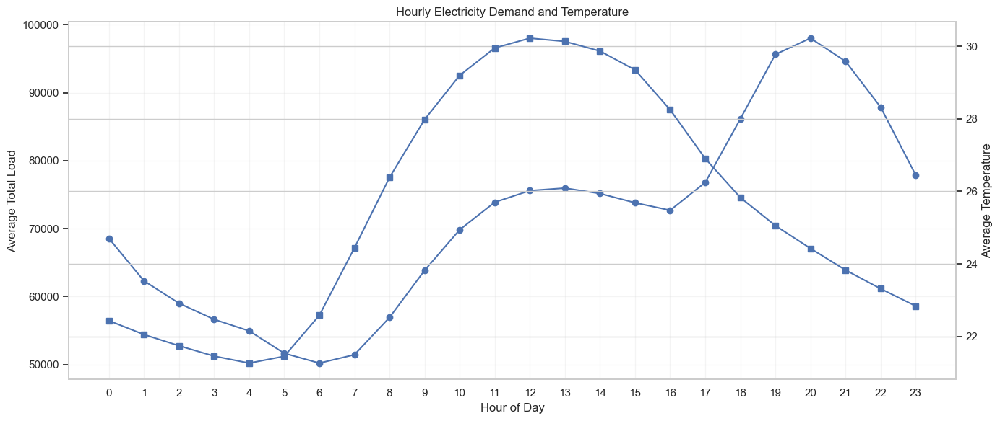

In [148]:
fig, ax1 = plt.subplots(figsize=(14, 6))

ax1.plot(
    hourly_weather_summary["Hour"],
    hourly_weather_summary["Total_Load"],
    marker="o",
    label="Total Load"
)

ax1.set_xlabel("Hour of Day")
ax1.set_ylabel("Average Total Load")
ax1.set_xticks(range(24))
ax1.grid(alpha=0.2)

ax2 = ax1.twinx()

ax2.plot(
    hourly_weather_summary["Hour"],
    hourly_weather_summary["Temperature"],
    marker="s",
    label="Temperature"
)

ax2.set_ylabel("Average Temperature")

plt.title("Hourly Electricity Demand and Temperature")
plt.tight_layout()
plt.show()

## Holiday Data Exploration

Localized holiday information has been incorporated into the forecasting
dataset because electricity demand may differ between regular working days
and public holidays.

The holiday analysis examines:

- Number of unique holiday dates
- Holiday types
- Holiday coverage in the 30-minute dataset
- Average demand on holidays versus non-holidays
- Demand associated with individual holiday dates

Because the dataset contains only one year of observations, holiday effects
are treated as descriptive patterns rather than statistically conclusive
long-term effects.

In [149]:
holiday_days = (
    integrated_df[
        integrated_df["Is_Public_Holiday"] == 1
    ][
        ["Date", "Holiday_Name", "Holiday_Type", "Scope"]
    ]
    .drop_duplicates()
    .sort_values("Date")
)

display(holiday_days)

,Date,Holiday_Name,Holiday_Type,Scope
528,2017-01-12,Sohrai,Festival,Jharkhand
1200,2017-01-26,Republic Day,National,Jharkhand
2592,2017-02-24,Maha Shivratri,Festival,Jharkhand
3408,2017-03-13,Holi,Festival,Jharkhand
4224,2017-03-30,Sarhul,Regional Festival,Jharkhand
4512,2017-04-05,Ram Navami,Festival,Jharkhand
4704,2017-04-09,Mahavir Jayanti; Littipara By-election,Festival; Local/Public,Jharkhand; Local Area
4944,2017-04-14,Good Friday,Religious,Jharkhand
5760,2017-05-01,Labour Day,Public/Regional,Jharkhand
10800,2017-08-14,Janmashtami,Festival,Jharkhand


In [150]:
holiday_type_counts = (
    holiday_days["Holiday_Type"]
    .value_counts()
)

display(holiday_type_counts)

Holiday_Type
Festival                  7
Religious                 5
National                  3
Regional Festival         2
Festival; Local/Public    1
Public/Regional           1
Name: count, dtype: int64

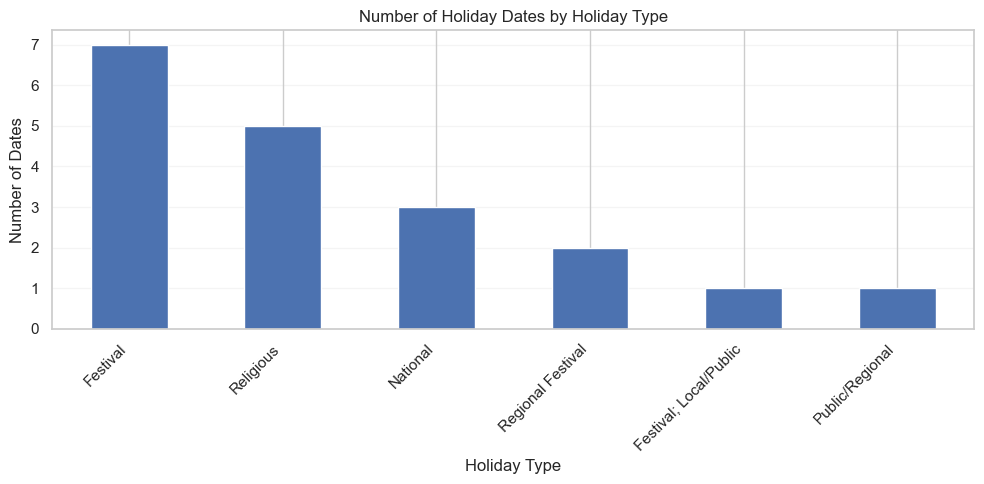

In [151]:
plt.figure(figsize=(10, 5))

holiday_type_counts.plot(
    kind="bar"
)

plt.title("Number of Holiday Dates by Holiday Type")
plt.xlabel("Holiday Type")
plt.ylabel("Number of Dates")
plt.xticks(rotation=45, ha="right")
plt.grid(axis="y", alpha=0.2)

plt.tight_layout()
plt.show()

In [152]:
daily_demand = (
    integrated_df
    .groupby("Date")
    .agg(
        Daily_Avg_Load=("Total_Load", "mean"),
        Is_Public_Holiday=("Is_Public_Holiday", "max")
    )
    .reset_index()
)

daily_holiday_summary = (
    daily_demand
    .groupby("Is_Public_Holiday")["Daily_Avg_Load"]
    .agg(
        Count="count",
        Mean="mean",
        Median="median",
        Std="std",
        Min="min",
        Max="max"
    )
)

display(daily_holiday_summary)

,Count,Mean,Median,Std,Min,Max
Is_Public_Holiday,,,,,,
0,345,71355.300849,68501.029337,8369.742245,58574.151543,98049.340547
1,19,68818.508508,67552.433806,6867.116529,63586.098897,88574.333334


<Figure size 800x600 with 0 Axes>

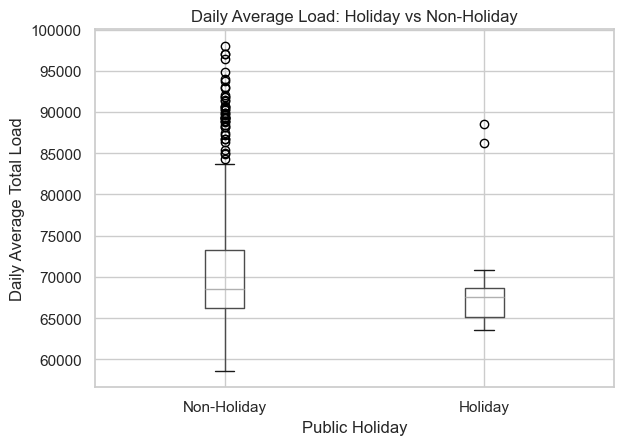

In [153]:
plt.figure(figsize=(8, 6))

daily_demand.boxplot(
    column="Daily_Avg_Load",
    by="Is_Public_Holiday"
)

plt.title("Daily Average Load: Holiday vs Non-Holiday")
plt.suptitle("")
plt.xlabel("Public Holiday")
plt.ylabel("Daily Average Total Load")
plt.xticks(
    [1, 2],
    ["Non-Holiday", "Holiday"]
)

plt.tight_layout()
plt.show()

In [154]:
holiday_demand = (
    integrated_df[
        integrated_df["Is_Public_Holiday"] == 1
    ]
    .groupby(
        ["Date", "Holiday_Name"],
        as_index=False
    )["Total_Load"]
    .mean()
    .rename(
        columns={"Total_Load": "Average_Holiday_Load"}
    )
    .sort_values("Date")
)

display(holiday_demand)

,Date,Holiday_Name,Average_Holiday_Load
0,2017-01-12,Sohrai,69420.572968
1,2017-01-26,Republic Day,70822.310202
2,2017-02-24,Maha Shivratri,67166.523099
3,2017-03-13,Holi,67552.433806
4,2017-03-30,Sarhul,67680.684186
5,2017-04-05,Ram Navami,68338.184976
6,2017-04-09,Mahavir Jayanti; Littipara By-election,63597.845232
7,2017-04-14,Good Friday,67721.455878
8,2017-05-01,Labour Day,64415.006899
9,2017-08-14,Janmashtami,86208.830984


In [155]:
holiday_validation = {
    "Unique holiday dates": holiday_days["Date"].nunique(),
    "Holiday 30-min observations": int(
        integrated_df["Is_Public_Holiday"].sum()
    ),
    "Expected observations per holiday": 48,
    "Holiday observations expected": holiday_days["Date"].nunique() * 48,
    "Holiday observations match expected": (
        integrated_df["Is_Public_Holiday"].sum()
        == holiday_days["Date"].nunique() * 48
    )
}

display(pd.Series(holiday_validation))

Unique holiday dates                     19
Holiday 30-min observations             912
Expected observations per holiday        48
Holiday observations expected           912
Holiday observations match expected    True
dtype: object

# Feature Engineering

The integrated dataset contains electricity demand, Dhanbad-specific weather
variables, and localized holiday information. The next step is to transform
these raw variables into predictive features suitable for machine-learning
models.

Electricity demand exhibits strong temporal patterns, including daily,
weekly, and seasonal variation. Therefore, the feature-engineering process
will include:

- Calendar and time-based features
- Weekend and holiday indicators
- Cyclical encoding of time variables
- Historical lag features
- Rolling demand statistics
- Weather-derived features

Special care is taken to ensure that lag and rolling features use only
information that would have been available before the prediction timestamp.
This prevents future information from leaking into the training data.

In [156]:
model_df = integrated_df.copy()

model_df = model_df.sort_values("Datetime").reset_index(drop=True)

print("Rows:", len(model_df))
print("Columns:", len(model_df.columns))

display(model_df.head())

Rows: 17472
Columns: 14


,Datetime,F1_132KV_PowerConsumption,F2_132KV_PowerConsumption,F3_132KV_PowerConsumption,Total_Load,Dhanbad_Temperature,Dhanbad_Humidity,Dhanbad_CloudCover,Dhanbad_WindSpeed,Date,Holiday_Name,Holiday_Type,Scope,Is_Public_Holiday
0,2017-01-01 00:00:00,30999.493670,18170.212767,20013.493977,69183.200413,14.80,89.0,18.0,6.8,2017-01-01,No Holiday,None,None,0
1,2017-01-01 00:30:00,27396.455697,17883.282673,18490.602410,63770.340780,14.65,90.5,20.5,6.6,2017-01-01,No Holiday,None,None,0
2,2017-01-01 01:00:00,25407.594937,16627.355623,17476.626507,59511.577067,14.50,92.0,23.0,6.4,2017-01-01,No Holiday,None,None,0
3,2017-01-01 01:30:00,23906.835443,15529.483283,16609.156627,56045.475353,14.40,93.0,23.0,6.0,2017-01-01,No Holiday,None,None,0
4,2017-01-01 02:00:00,22474.936707,14767.173253,15870.843373,53112.953333,14.30,94.0,23.0,5.6,2017-01-01,No Holiday,None,None,0


In [157]:
model_df["hour"] = model_df["Datetime"].dt.hour

model_df["minute"] = model_df["Datetime"].dt.minute

model_df["day_of_week"] = model_df["Datetime"].dt.dayofweek

model_df["day_of_month"] = model_df["Datetime"].dt.day

model_df["month"] = model_df["Datetime"].dt.month

model_df["day_of_year"] = model_df["Datetime"].dt.dayofyear

model_df["week_of_year"] = (
    model_df["Datetime"].dt.isocalendar().week.astype(int)
)

model_df["is_weekend"] = (
    model_df["day_of_week"] >= 5
).astype(int)

In [158]:
calendar_columns = [
    "hour",
    "minute",
    "day_of_week",
    "day_of_month",
    "month",
    "day_of_year",
    "week_of_year",
    "is_weekend"
]

display(model_df[calendar_columns].head(10))

,hour,minute,day_of_week,day_of_month,month,day_of_year,week_of_year,is_weekend
0,0,0,6,1,1,1,52,1
1,0,30,6,1,1,1,52,1
2,1,0,6,1,1,1,52,1
3,1,30,6,1,1,1,52,1
4,2,0,6,1,1,1,52,1
5,2,30,6,1,1,1,52,1
6,3,0,6,1,1,1,52,1
7,3,30,6,1,1,1,52,1
8,4,0,6,1,1,1,52,1
9,4,30,6,1,1,1,52,1


In [159]:
model_df["time_slot"] = (
    model_df["hour"] * 2
    + (model_df["minute"] // 30)
)

In [160]:
print(
    "Unique time slots:",
    model_df["time_slot"].nunique()
)

print(
    "Time slot range:",
    model_df["time_slot"].min(),
    "to",
    model_df["time_slot"].max()
)

Unique time slots: 48
Time slot range: 0 to 47



## Cyclical Time Encoding

Time variables such as hour, day of week, and month are periodic.

For example, 23:30 is close to 00:00 even though the numerical hour values
are far apart. To represent this periodic structure, sine and cosine
transformations are applied.

For a periodic variable x with period P:

sin(2πx/P)
cos(2πx/P)

This allows the model to learn the circular relationship between the beginning
and end of each cycle.

In [161]:
import numpy as np

# 48 half-hour periods in a day
model_df["time_slot_sin"] = np.sin(
    2 * np.pi * model_df["time_slot"] / 48
)

model_df["time_slot_cos"] = np.cos(
    2 * np.pi * model_df["time_slot"] / 48
)

# Weekly cycle
model_df["day_of_week_sin"] = np.sin(
    2 * np.pi * model_df["day_of_week"] / 7
)

model_df["day_of_week_cos"] = np.cos(
    2 * np.pi * model_df["day_of_week"] / 7
)

# Annual cycle
model_df["day_of_year_sin"] = np.sin(
    2 * np.pi * model_df["day_of_year"] / 365
)

model_df["day_of_year_cos"] = np.cos(
    2 * np.pi * model_df["day_of_year"] / 365
)

In [162]:
cyclical_columns = [
    "time_slot_sin",
    "time_slot_cos",
    "day_of_week_sin",
    "day_of_week_cos",
    "day_of_year_sin",
    "day_of_year_cos"
]

display(model_df[cyclical_columns].head())

,time_slot_sin,time_slot_cos,day_of_week_sin,day_of_week_cos,day_of_year_sin,day_of_year_cos
0,0.000000,1.000000,-0.781831,0.62349,0.017213,0.999852
1,0.130526,0.991445,-0.781831,0.62349,0.017213,0.999852
2,0.258819,0.965926,-0.781831,0.62349,0.017213,0.999852
3,0.382683,0.923880,-0.781831,0.62349,0.017213,0.999852
4,0.500000,0.866025,-0.781831,0.62349,0.017213,0.999852


In [163]:
model_df["is_holiday"] = (
    model_df["Is_Public_Holiday"]
    .fillna(0)
    .astype(int)
)

In [164]:
print(
    model_df["is_holiday"].value_counts()
)

is_holiday
0    16560
1      912
Name: count, dtype: int64


## Historical Demand Features

Electricity demand has strong temporal dependence. Recent observations and
corresponding observations from previous days or weeks can therefore provide
important predictive information.

The dataset contains 48 half-hour observations per day. Consequently:

- 1 lag represents 30 minutes
- 2 lags represent 1 hour
- 48 lags represent 1 day
- 96 lags represent 2 days
- 336 lags represent 7 days

Only past observations are used to construct these features. No future demand
values are used.

In [165]:
lag_periods = {
    "lag_1": 1,
    "lag_2": 2,
    "lag_4": 4,
    "lag_48": 48,
    "lag_96": 96,
    "lag_336": 336
}

for feature_name, lag in lag_periods.items():
    model_df[feature_name] = (
        model_df["Total_Load"].shift(lag)
    )

In [166]:
lag_columns = list(lag_periods.keys())

display(
    model_df[
        ["Datetime", "Total_Load"] + lag_columns
    ].head(55)
)

,Datetime,Total_Load,lag_1,lag_2,lag_4,lag_48,lag_96,lag_336
0,2017-01-01 00:00:00,69183.200413,NaN,NaN,NaN,NaN,NaN,NaN
1,2017-01-01 00:30:00,63770.340780,69183.200413,NaN,NaN,NaN,NaN,NaN
2,2017-01-01 01:00:00,59511.577067,63770.340780,69183.200413,NaN,NaN,NaN,NaN
3,2017-01-01 01:30:00,56045.475353,59511.577067,63770.340780,NaN,NaN,NaN,NaN
4,2017-01-01 02:00:00,53112.953333,56045.475353,59511.577067,69183.200413,NaN,NaN,NaN
5,2017-01-01 02:30:00,51066.809947,53112.953333,56045.475353,63770.340780,NaN,NaN,NaN
6,2017-01-01 03:00:00,49431.029590,51066.809947,53112.953333,59511.577067,NaN,NaN,NaN
7,2017-01-01 03:30:00,48397.865507,49431.029590,51066.809947,56045.475353,NaN,NaN,NaN
8,2017-01-01 04:00:00,47861.981360,48397.865507,49431.029590,53112.953333,NaN,NaN,NaN
9,2017-01-01 04:30:00,47567.295333,47861.981360,48397.865507,51066.809947,NaN,NaN,NaN


## Rolling Demand Features

Rolling statistics summarize recent historical demand and can help the model
capture short-term demand trends and fluctuations.

To prevent target leakage, the rolling calculations are performed on demand
shifted by one time step. Therefore, the current demand observation is never
included in its own rolling statistics.

In [167]:
past_load = model_df["Total_Load"].shift(1)

model_df["rolling_mean_1h"] = (
    past_load
    .rolling(window=2)
    .mean()
)

model_df["rolling_mean_2h"] = (
    past_load
    .rolling(window=4)
    .mean()
)

model_df["rolling_mean_6h"] = (
    past_load
    .rolling(window=12)
    .mean()
)

model_df["rolling_mean_24h"] = (
    past_load
    .rolling(window=48)
    .mean()
)

In [168]:
model_df["rolling_std_2h"] = (
    past_load
    .rolling(window=4)
    .std()
)

model_df["rolling_std_24h"] = (
    past_load
    .rolling(window=48)
    .std()
)

In [169]:
weather_features = [
    "Dhanbad_Temperature",
    "Dhanbad_Humidity",
    "Dhanbad_CloudCover",
    "Dhanbad_WindSpeed"
]

In [170]:
model_df["Temperature_Humidity"] = (
    model_df["Dhanbad_Temperature"]
    * model_df["Dhanbad_Humidity"]
)

In [171]:
model_df["load_change_30min"] = (
    model_df["Total_Load"]
    - model_df["lag_1"]
)

model_df["load_change_1h"] = (
    model_df["Total_Load"]
    - model_df["lag_2"]
)

In [172]:
model_df.drop(
    columns=[
        "load_change_30min",
        "load_change_1h"
    ],
    inplace=True
)

In [173]:
model_df["historical_change_30min"] = (
    model_df["lag_1"] - model_df["lag_2"]
)

In [174]:
model_df["historical_change_30min"] = (
    model_df["lag_1"]
    - model_df["lag_2"]
)

In [175]:
feature_columns = [
    "hour",
    "minute",
    "day_of_week",
    "day_of_month",
    "month",
    "day_of_year",
    "week_of_year",
    "is_weekend",
    "time_slot",
    "time_slot_sin",
    "time_slot_cos",
    "day_of_week_sin",
    "day_of_week_cos",
    "day_of_year_sin",
    "day_of_year_cos",
    "is_holiday",
    "Dhanbad_Temperature",
    "Dhanbad_Humidity",
    "Dhanbad_CloudCover",
    "Dhanbad_WindSpeed",
    "Temperature_Humidity",
    "lag_1",
    "lag_2",
    "lag_4",
    "lag_48",
    "lag_96",
    "lag_336",
    "rolling_mean_1h",
    "rolling_mean_2h",
    "rolling_mean_6h",
    "rolling_mean_24h",
    "rolling_std_2h",
    "rolling_std_24h",
    "historical_change_30min"
]

print("Number of engineered/predictive features:", len(feature_columns))

display(
    model_df[
        ["Datetime", "Total_Load"] + feature_columns
    ].head(10)
)

Number of engineered/predictive features: 34


,Datetime,Total_Load,hour,minute,day_of_week,day_of_month,month,day_of_year,week_of_year,is_weekend,time_slot,time_slot_sin,time_slot_cos,day_of_week_sin,day_of_week_cos,day_of_year_sin,day_of_year_cos,is_holiday,Dhanbad_Temperature,Dhanbad_Humidity,Dhanbad_CloudCover,Dhanbad_WindSpeed,Temperature_Humidity,lag_1,lag_2,lag_4,lag_48,lag_96,lag_336,rolling_mean_1h,rolling_mean_2h,rolling_mean_6h,rolling_mean_24h,rolling_std_2h,rolling_std_24h,historical_change_30min
0,2017-01-01 00:00:00,69183.200413,0,0,6,1,1,1,52,1,0,0.000000,1.000000,-0.781831,0.62349,0.017213,0.999852,0,14.80,89.0,18.0,6.8,1317.200,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2017-01-01 00:30:00,63770.340780,0,30,6,1,1,1,52,1,1,0.130526,0.991445,-0.781831,0.62349,0.017213,0.999852,0,14.65,90.5,20.5,6.6,1325.825,69183.200413,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2017-01-01 01:00:00,59511.577067,1,0,6,1,1,1,52,1,2,0.258819,0.965926,-0.781831,0.62349,0.017213,0.999852,0,14.50,92.0,23.0,6.4,1334.000,63770.340780,69183.200413,NaN,NaN,NaN,NaN,66476.770597,NaN,NaN,NaN,NaN,NaN,-5412.859633
3,2017-01-01 01:30:00,56045.475353,1,30,6,1,1,1,52,1,3,0.382683,0.923880,-0.781831,0.62349,0.017213,0.999852,0,14.40,93.0,23.0,6.0,1339.200,59511.577067,63770.340780,NaN,NaN,NaN,NaN,61640.958923,NaN,NaN,NaN,NaN,NaN,-4258.763713
4,2017-01-01 02:00:00,53112.953333,2,0,6,1,1,1,52,1,4,0.500000,0.866025,-0.781831,0.62349,0.017213,0.999852,0,14.30,94.0,23.0,5.6,1344.200,56045.475353,59511.577067,69183.200413,NaN,NaN,NaN,57778.526210,62127.648403,NaN,NaN,5666.154212,NaN,-3466.101713
5,2017-01-01 02:30:00,51066.809947,2,30,6,1,1,1,52,1,5,0.608761,0.793353,-0.781831,0.62349,0.017213,0.999852,0,14.25,94.5,22.0,5.9,1346.625,53112.953333,56045.475353,63770.340780,NaN,NaN,NaN,54579.214343,58110.086633,NaN,NaN,4591.173176,NaN,-2932.522020
6,2017-01-01 03:00:00,49431.029590,3,0,6,1,1,1,52,1,6,0.707107,0.707107,-0.781831,0.62349,0.017213,0.999852,0,14.20,95.0,21.0,6.2,1349.000,51066.809947,53112.953333,59511.577067,NaN,NaN,NaN,52089.881640,54934.203925,NaN,NaN,3672.463250,NaN,-2046.143387
7,2017-01-01 03:30:00,48397.865507,3,30,6,1,1,1,52,1,7,0.793353,0.608761,-0.781831,0.62349,0.017213,0.999852,0,14.05,95.5,14.0,5.8,1341.775,49431.029590,51066.809947,56045.475353,NaN,NaN,NaN,50248.919768,52414.067056,NaN,NaN,2851.267700,NaN,-1635.780357
8,2017-01-01 04:00:00,47861.981360,4,0,6,1,1,1,52,1,8,0.866025,0.500000,-0.781831,0.62349,0.017213,0.999852,0,13.90,96.0,7.0,5.4,1334.400,48397.865507,49431.029590,53112.953333,NaN,NaN,NaN,48914.447548,50502.164594,NaN,NaN,2058.352663,NaN,-1033.164083
9,2017-01-01 04:30:00,47567.295333,4,30,6,1,1,1,52,1,9,0.923880,0.382683,-0.781831,0.62349,0.017213,0.999852,0,14.25,94.5,4.0,5.5,1346.625,47861.981360,48397.865507,51066.809947,NaN,NaN,NaN,48129.923433,49189.421601,NaN,NaN,1410.864991,NaN,-535.884147


In [176]:
feature_missing = (
    model_df[feature_columns]
    .isna()
    .sum()
    .sort_values(ascending=False)
)

display(
    feature_missing[
        feature_missing > 0
    ]
)

lag_336                    336
lag_96                      96
rolling_std_24h             48
rolling_mean_24h            48
lag_48                      48
rolling_mean_6h             12
rolling_mean_2h              4
lag_4                        4
rolling_std_2h               4
historical_change_30min      2
lag_2                        2
rolling_mean_1h              2
lag_1                        1
dtype: int64

In [177]:
model_df = (
    model_df
    .dropna(subset=feature_columns)
    .reset_index(drop=True)
)

In [178]:
print("Rows after feature engineering:", len(model_df))
print("Missing feature values:", model_df[feature_columns].isna().sum().sum())

Rows after feature engineering: 17136
Missing feature values: 0


# Time-Aware Dataset Splitting

Electricity demand forecasting is a time-series problem. Therefore, the
dataset must be divided chronologically rather than randomly.

Randomly shuffling the observations could allow the model to train on future
observations while being evaluated on earlier observations. This would result
in information leakage and an unrealistically optimistic evaluation.

The model-development dataset is therefore divided into three chronological
parts:

- Training set: approximately 70%
- Validation set: approximately 15%
- Test set: approximately 15%

The training set is used to learn model parameters, the validation set is used
for model selection and hyperparameter decisions, and the final test set is
kept untouched until final model evaluation.

In [179]:
print("Total rows:", len(model_df))
print("Start:", model_df["Datetime"].min())
print("End:", model_df["Datetime"].max())

print(
    "Unique dates:",
    model_df["Datetime"].dt.date.nunique()
)

Total rows: 17136
Start: 2017-01-08 00:00:00
End: 2017-12-30 23:30:00
Unique dates: 357


In [180]:
unique_dates = (
    model_df["Datetime"]
    .dt.normalize()
    .drop_duplicates()
    .sort_values()
    .reset_index(drop=True)
)

n_days = len(unique_dates)

train_days = int(n_days * 0.70)
validation_days = int(n_days * 0.15)

test_days = (
    n_days
    - train_days
    - validation_days
)

print("Total days:", n_days)
print("Training days:", train_days)
print("Validation days:", validation_days)
print("Test days:", test_days)

Total days: 357
Training days: 249
Validation days: 53
Test days: 55


In [181]:
train_end_date = unique_dates[train_days - 1]
validation_end_date = unique_dates[
    train_days + validation_days - 1
]

test_start_date = unique_dates[
    train_days + validation_days
]

print("Training ends:", train_end_date)
print("Validation ends:", validation_end_date)
print("Test starts:", test_start_date)

Training ends: 2017-09-13 00:00:00
Validation ends: 2017-11-05 00:00:00
Test starts: 2017-11-06 00:00:00


In [182]:
train_df = model_df[
    model_df["Datetime"].dt.normalize() <= train_end_date
].copy()

validation_df = model_df[
    (
        model_df["Datetime"].dt.normalize() > train_end_date
    )
    &
    (
        model_df["Datetime"].dt.normalize() <= validation_end_date
    )
].copy()

test_df = model_df[
    model_df["Datetime"].dt.normalize() > validation_end_date
].copy()

In [183]:
split_summary = pd.DataFrame({
    "Dataset": ["Train", "Validation", "Test"],
    "Rows": [
        len(train_df),
        len(validation_df),
        len(test_df)
    ],
    "Days": [
        train_df["Datetime"].dt.date.nunique(),
        validation_df["Datetime"].dt.date.nunique(),
        test_df["Datetime"].dt.date.nunique()
    ],
    "Start": [
        train_df["Datetime"].min(),
        validation_df["Datetime"].min(),
        test_df["Datetime"].min()
    ],
    "End": [
        train_df["Datetime"].max(),
        validation_df["Datetime"].max(),
        test_df["Datetime"].max()
    ]
})

display(split_summary)

,Dataset,Rows,Days,Start,End
0,Train,11952,249,2017-01-08,2017-09-13 23:30:00
1,Validation,2544,53,2017-09-14,2017-11-05 23:30:00
2,Test,2640,55,2017-11-06,2017-12-30 23:30:00


In [184]:
assert train_df["Datetime"].max() < validation_df["Datetime"].min()

assert validation_df["Datetime"].max() < test_df["Datetime"].min()

assert (
    set(train_df["Datetime"])
    .isdisjoint(set(validation_df["Datetime"]))
)

assert (
    set(validation_df["Datetime"])
    .isdisjoint(set(test_df["Datetime"]))
)

print("No temporal overlap between train, validation, and test sets.")

No temporal overlap between train, validation, and test sets.


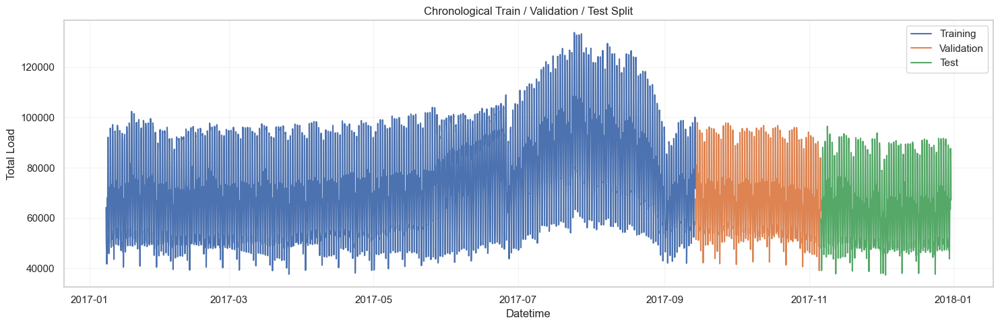

In [185]:
plt.figure(figsize=(15, 5))

plt.plot(
    train_df["Datetime"],
    train_df["Total_Load"],
    label="Training"
)

plt.plot(
    validation_df["Datetime"],
    validation_df["Total_Load"],
    label="Validation"
)

plt.plot(
    test_df["Datetime"],
    test_df["Total_Load"],
    label="Test"
)

plt.xlabel("Datetime")
plt.ylabel("Total Load")
plt.title("Chronological Train / Validation / Test Split")
plt.legend()
plt.grid(alpha=0.2)

plt.tight_layout()
plt.show()

In [186]:
target_column = "Total_Load"

X_train = train_df[feature_columns].copy()
y_train = train_df[target_column].copy()

X_validation = validation_df[feature_columns].copy()
y_validation = validation_df[target_column].copy()

X_test = test_df[feature_columns].copy()
y_test = test_df[target_column].copy()

In [187]:
print("X_train:", X_train.shape)
print("y_train:", y_train.shape)

print("X_validation:", X_validation.shape)
print("y_validation:", y_validation.shape)

print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

X_train: (11952, 34)
y_train: (11952,)
X_validation: (2544, 34)
y_validation: (2544,)
X_test: (2640, 34)
y_test: (2640,)


In [188]:
target_summary = pd.DataFrame({
    "Train": y_train.describe(),
    "Validation": y_validation.describe(),
    "Test": y_test.describe()
})

display(target_summary)

,Train,Validation,Test
count,11952.000000,2544.000000,2640.000000
mean,73607.645514,67614.471590,64391.792926
std,17882.938944,13290.742166,14235.876826
min,37641.826136,39108.440959,37318.414354
25%,58892.098588,55743.181666,50801.034662
50%,71873.918393,67457.505593,64265.617975
75%,87707.933060,73968.298307,73957.295355
max,133772.090637,97933.033757,96475.408383


In [189]:
holiday_split_summary = pd.DataFrame({
    "Train": [
        train_df["is_holiday"].sum(),
        train_df["Datetime"].dt.date[
            train_df["is_holiday"] == 1
        ].nunique()
    ],
    "Validation": [
        validation_df["is_holiday"].sum(),
        validation_df["Datetime"].dt.date[
            validation_df["is_holiday"] == 1
        ].nunique()
    ],
    "Test": [
        test_df["is_holiday"].sum(),
        test_df["Datetime"].dt.date[
            test_df["is_holiday"] == 1
        ].nunique()
    ]
}, index=[
    "Holiday half-hour observations",
    "Unique holiday dates"
])

display(holiday_split_summary)

,Train,Validation,Test
Holiday half-hour observations,576,288,48
Unique holiday dates,12,6,1


In [190]:
assert target_column not in X_train.columns
assert target_column not in X_validation.columns
assert target_column not in X_test.columns

print("Target leakage check passed.")

Target leakage check passed.


In [191]:
assert np.isfinite(X_train.select_dtypes(include=np.number)).all().all()
assert np.isfinite(X_validation.select_dtypes(include=np.number)).all().all()
assert np.isfinite(X_test.select_dtypes(include=np.number)).all().all()

print("Feature validity check passed.")

Feature validity check passed.


In [192]:
import os

os.makedirs("Desktop/exascaleAi/Project/Project - 1", exist_ok=True)

train_df.to_csv(
    "Desktop/exascaleAi/Project/Project - 1/train_features.csv",
    index=False
)

validation_df.to_csv(
    "Desktop/exascaleAi/Project/Project - 1/validation_features.csv",
    index=False
)

test_df.to_csv(
    "Desktop/exascaleAi/Project/Project - 1/test_features.csv",
    index=False
)

print("Train, validation, and test datasets saved.")

Train, validation, and test datasets saved.


## Train/Validation/Test Split Findings

The model-ready dataset contains 17,136 observations covering 357 complete
days after the seven-day historical feature requirement.

The data was divided chronologically into training, validation, and test
sets. Approximately 70% of the available days were assigned to training,
15% to validation, and 15% to testing.

No random shuffling was performed because the forecasting task requires the
model to predict future observations using information available in the past.

The training set is used for model fitting, the validation set is reserved
for model comparison and hyperparameter selection, and the final test set is
kept separate for unbiased evaluation.

The chronological split ensures that the evaluation better represents the
real-world forecasting scenario in which future electricity demand is unknown
at prediction time.

## Target Distribution Across Temporal Splits

The target statistics differ across the chronological train, validation, and
test sets. The training set has a higher average demand than the validation
and test sets.

This difference is consistent with the seasonal demand behavior identified
during exploratory analysis, where electricity demand increased substantially
during the middle of the year, particularly during July and August.

Because the split is chronological, the observed differences reflect the
actual temporal distribution of the dataset rather than random sampling
variation.

This distribution shift should be considered when interpreting model
performance. The evaluation therefore represents the model's ability to
generalize from earlier periods to later periods under changing seasonal
demand conditions.

In [193]:
split_dates = pd.DataFrame({
    "Dataset": ["Train", "Validation", "Test"],
    "Start_Date": [
        train_df["Datetime"].dt.date.min(),
        validation_df["Datetime"].dt.date.min(),
        test_df["Datetime"].dt.date.min()
    ],
    "End_Date": [
        train_df["Datetime"].dt.date.max(),
        validation_df["Datetime"].dt.date.max(),
        test_df["Datetime"].dt.date.max()
    ],
    "Mean_Load": [
        train_df["Total_Load"].mean(),
        validation_df["Total_Load"].mean(),
        test_df["Total_Load"].mean()
    ]
})

display(split_dates)

,Dataset,Start_Date,End_Date,Mean_Load
0,Train,2017-01-08,2017-09-13,73607.645514
1,Validation,2017-09-14,2017-11-05,67614.471590
2,Test,2017-11-06,2017-12-30,64391.792926


In [194]:
monthly_split = (
    model_df
    .assign(
        Month=model_df["Datetime"].dt.month
    )
    .groupby(["Month"])
    ["Total_Load"]
    .mean()
)

display(monthly_split)

Month
1     68402.205217
2     67108.548882
3     66560.788896
4     67396.902281
5     69994.397979
6     75707.410998
7     88173.551711
8     85740.300881
9     68499.912449
10    67560.748669
11    65105.067506
12    63750.827167
Name: Total_Load, dtype: float64

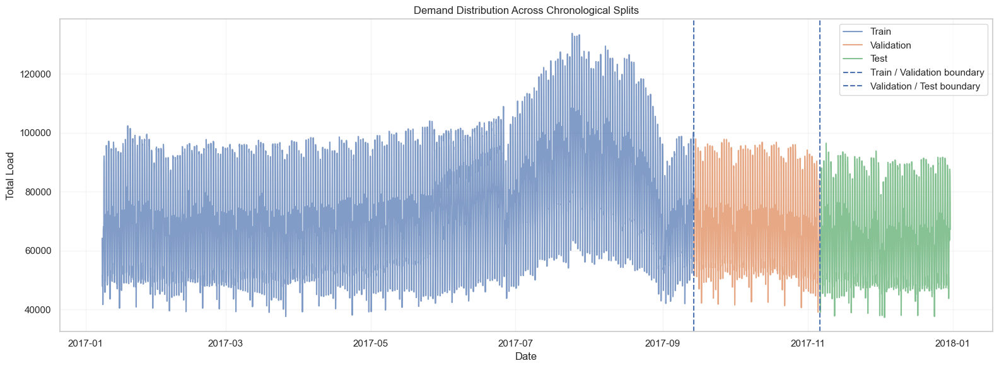

In [195]:
plt.figure(figsize=(16, 6))

plt.plot(
    train_df["Datetime"],
    train_df["Total_Load"],
    label="Train",
    alpha=0.7
)

plt.plot(
    validation_df["Datetime"],
    validation_df["Total_Load"],
    label="Validation",
    alpha=0.7
)

plt.plot(
    test_df["Datetime"],
    test_df["Total_Load"],
    label="Test",
    alpha=0.7
)

plt.axvline(
    validation_df["Datetime"].min(),
    linestyle="--",
    label="Train / Validation boundary"
)

plt.axvline(
    test_df["Datetime"].min(),
    linestyle="--",
    label="Validation / Test boundary"
)

plt.xlabel("Date")
plt.ylabel("Total Load")
plt.title("Demand Distribution Across Chronological Splits")
plt.legend()
plt.grid(alpha=0.2)

plt.tight_layout()
plt.show()

# Baseline Forecasting Models

Before training machine-learning models, simple historical-demand forecasting
baselines are established.

These baselines provide reference points against which more complex models can
be evaluated.

Three persistence-based forecasting strategies are considered:

1. Previous 30-minute demand (`lag_1`)
2. Demand at the same half-hour on the previous day (`lag_48`)
3. Demand at the same half-hour one week earlier (`lag_336`)

A machine-learning model should provide meaningful improvement over these
simple historical baselines to justify the additional model complexity.

In [196]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import numpy as np
import pandas as pd

In [197]:
def calculate_mape(y_true, y_pred):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)

    return np.mean(
        np.abs((y_true - y_pred) / y_true)
    ) * 100

In [198]:
baseline_predictions = {
    "Previous 30 min": {
        "validation": validation_df["lag_1"],
        "test": test_df["lag_1"]
    },
    "Previous day": {
        "validation": validation_df["lag_48"],
        "test": test_df["lag_48"]
    },
    "Previous week": {
        "validation": validation_df["lag_336"],
        "test": test_df["lag_336"]
    }
}

In [199]:
def evaluate_forecast(y_true, y_pred):
    return {
        "MAE": mean_absolute_error(
            y_true,
            y_pred
        ),
        "RMSE": np.sqrt(
            mean_squared_error(
                y_true,
                y_pred
            )
        ),
        "MAPE (%)": calculate_mape(
            y_true,
            y_pred
        ),
        "R2": r2_score(
            y_true,
            y_pred
        )
    }

In [200]:
validation_baseline_results = []

for name, predictions in baseline_predictions.items():

    metrics = evaluate_forecast(
        y_validation,
        predictions["validation"]
    )

    metrics["Model"] = name

    validation_baseline_results.append(metrics)

validation_baseline_results = pd.DataFrame(
    validation_baseline_results
)

validation_baseline_results = validation_baseline_results[
    [
        "Model",
        "MAE",
        "RMSE",
        "MAPE (%)",
        "R2"
    ]
]

display(
    validation_baseline_results.sort_values("MAE")
)

,Model,MAE,RMSE,MAPE (%),R2
2,Previous week,1803.382192,2376.933234,2.731855,0.968003
1,Previous day,2060.200457,3049.895470,3.200895,0.947320
0,Previous 30 min,2194.247557,3237.733111,3.221066,0.940632


In [201]:
test_baseline_results = []

for name, predictions in baseline_predictions.items():

    metrics = evaluate_forecast(
        y_test,
        predictions["test"]
    )

    metrics["Model"] = name

    test_baseline_results.append(metrics)

test_baseline_results = pd.DataFrame(
    test_baseline_results
)

test_baseline_results = test_baseline_results[
    [
        "Model",
        "MAE",
        "RMSE",
        "MAPE (%)",
        "R2"
    ]
]

display(
    test_baseline_results.sort_values("MAE")
)


,Model,MAE,RMSE,MAPE (%),R2
2,Previous week,2121.849054,2980.237522,3.362754,0.956157
0,Previous 30 min,2129.890377,3112.649859,3.343555,0.952175
1,Previous day,2135.164862,3255.119909,3.420978,0.947697


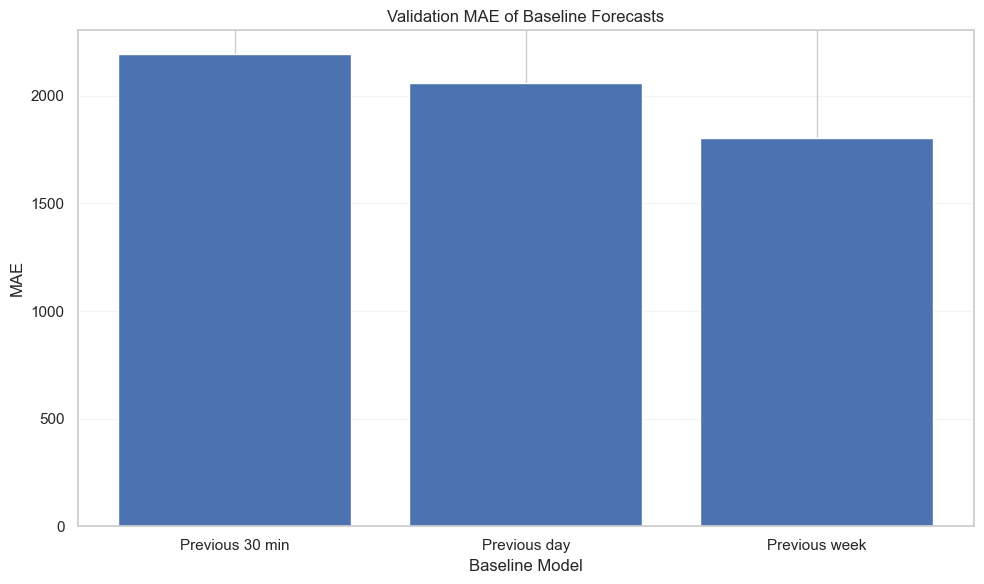

In [202]:
plt.figure(figsize=(10, 6))

plt.bar(
    validation_baseline_results["Model"],
    validation_baseline_results["MAE"]
)

plt.ylabel("MAE")
plt.xlabel("Baseline Model")
plt.title("Validation MAE of Baseline Forecasts")
plt.grid(axis="y", alpha=0.2)

plt.tight_layout()
plt.show()

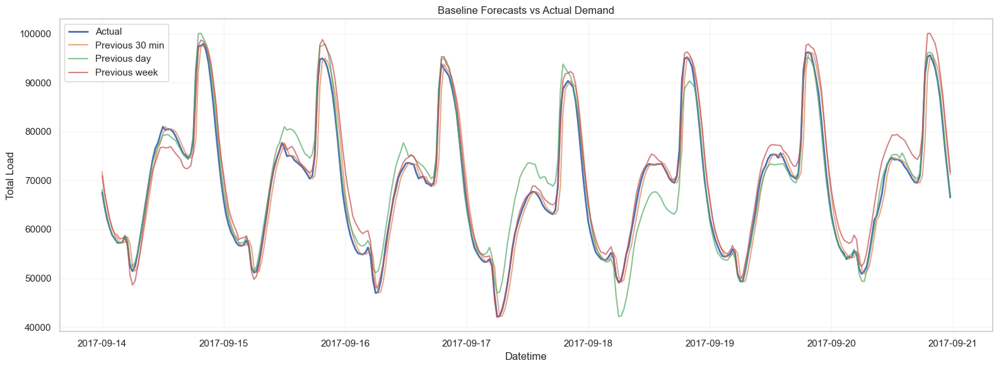

In [203]:
comparison_df = validation_df[
    [
        "Datetime",
        "Total_Load",
        "lag_1",
        "lag_48",
        "lag_336"
    ]
].copy()

comparison_sample = comparison_df.iloc[:7 * 48]

plt.figure(figsize=(16, 6))

plt.plot(
    comparison_sample["Datetime"],
    comparison_sample["Total_Load"],
    label="Actual",
    linewidth=2
)

plt.plot(
    comparison_sample["Datetime"],
    comparison_sample["lag_1"],
    label="Previous 30 min",
    alpha=0.7
)

plt.plot(
    comparison_sample["Datetime"],
    comparison_sample["lag_48"],
    label="Previous day",
    alpha=0.7
)

plt.plot(
    comparison_sample["Datetime"],
    comparison_sample["lag_336"],
    label="Previous week",
    alpha=0.7
)

plt.xlabel("Datetime")
plt.ylabel("Total Load")
plt.title("Baseline Forecasts vs Actual Demand")
plt.legend()
plt.grid(alpha=0.2)

plt.tight_layout()
plt.show()

## Baseline Evaluation

Three historical-demand baselines were evaluated using the validation and test
periods.

The previous-30-minute baseline uses the most recent observed demand, while the
previous-day and previous-week baselines use demand from the same half-hour on
the corresponding previous day or week.

The baseline results provide reference performance for evaluating subsequent
machine-learning models.

Validation performance is used for model-development decisions, while the test
set remains reserved for final evaluation.

The baseline comparison also demonstrates the importance of historical demand
features in the forecasting problem.

# Machine Learning Model Development

Following the baseline experiments, machine-learning models are trained using
the engineered temporal, weather, holiday, lag, and rolling-demand features.

The first model is a Random Forest Regressor. Random Forest is suitable for
the initial experiment because it can model nonlinear relationships and
interactions between features without requiring linear assumptions.

The model is trained only on the chronological training set. The validation
set is used to evaluate the model during development, while the test set
remains reserved for final model evaluation.

The Random Forest model will also provide feature-importance estimates that
can be used to investigate which engineered variables contribute most strongly
to the predictions.

In [204]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(
    n_estimators=200,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    max_features="sqrt",
    random_state=42,
    n_jobs=-1
)

rf_model.fit(
    X_train,
    y_train
)

print("Random Forest training completed.")

Random Forest training completed.


In [205]:
rf_validation_pred = rf_model.predict(
    X_validation
)

rf_validation_metrics = evaluate_forecast(
    y_validation,
    rf_validation_pred
)

rf_validation_metrics

{'MAE': 886.0359032707221,
 'RMSE': np.float64(1237.8659603305493),
 'MAPE (%)': np.float64(1.339228597240966),
 'R2': 0.9913220024737854}

In [206]:
rf_validation_results = pd.DataFrame([
    {
        "Model": "Random Forest",
        **rf_validation_metrics
    }
])

display(rf_validation_results)

,Model,MAE,RMSE,MAPE (%),R2
0,Random Forest,886.035903,1237.86596,1.339229,0.991322


## Random Forest Validation Results

The initial Random Forest model substantially improves upon the historical
baseline forecasts.

On the validation set, the Random Forest achieves:

- MAE: approximately 886.04
- RMSE: approximately 1,237.87
- MAPE: approximately 1.34%
- R²: approximately 0.9913

The strongest historical baseline, the previous-week forecast, achieved an
MAE of approximately 1,803.38 and an R² of approximately 0.9680.

Therefore, the initial Random Forest model provides a substantial improvement
over the persistence-based baseline on the validation period.

The result suggests that combining historical demand information with temporal,
weather, and holiday features allows the model to capture additional demand
variation that cannot be represented by a single historical lag.

The validation result is encouraging, but it is not yet considered the final
model performance. Further feature analysis and model comparison will be
performed before evaluating the final selected model on the held-out test set.

In [207]:
rf_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": rf_model.feature_importances_
})

rf_importance = (
    rf_importance
    .sort_values("Importance", ascending=False)
    .reset_index(drop=True)
)

display(rf_importance)

,Feature,Importance
0,lag_48,0.158402
1,lag_1,0.140639
2,lag_336,0.132923
3,lag_96,0.130122
4,rolling_mean_1h,0.097909
5,lag_2,0.079853
6,rolling_mean_2h,0.060459
7,hour,0.047583
8,time_slot,0.034224
9,time_slot_sin,0.032452


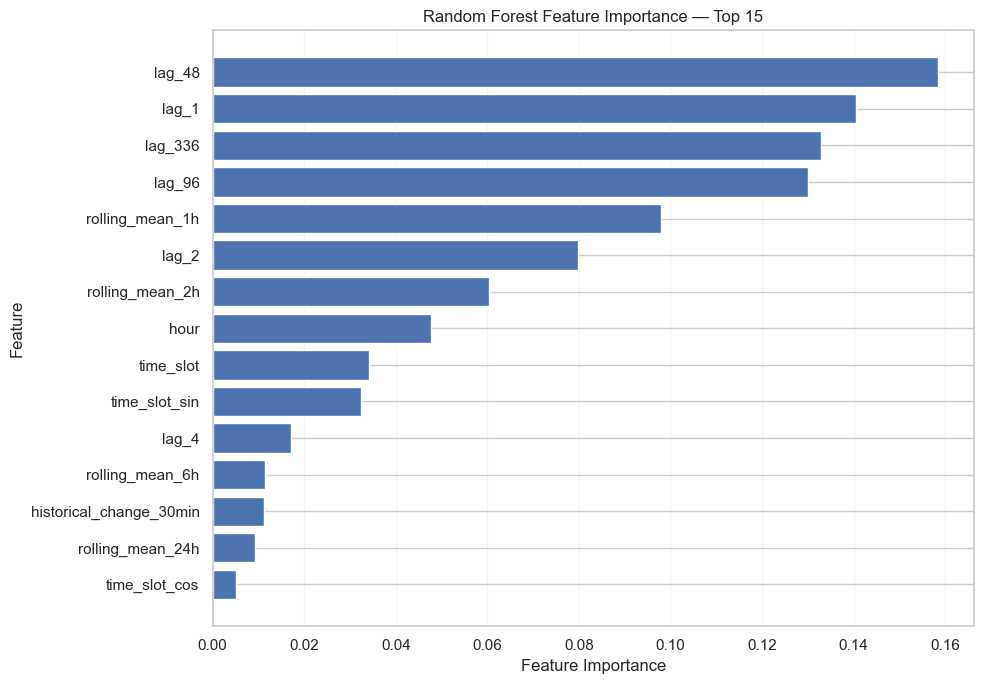

In [208]:
top_features = rf_importance.head(15).sort_values(
    "Importance",
    ascending=True
)

plt.figure(figsize=(10, 7))

plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)

plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title("Random Forest Feature Importance — Top 15")
plt.grid(axis="x", alpha=0.2)

plt.tight_layout()
plt.show()

In [209]:
rf_importance["Cumulative_Importance"] = (
    rf_importance["Importance"].cumsum()
)

display(rf_importance)

,Feature,Importance,Cumulative_Importance
0,lag_48,0.158402,0.158402
1,lag_1,0.140639,0.299042
2,lag_336,0.132923,0.431965
3,lag_96,0.130122,0.562087
4,rolling_mean_1h,0.097909,0.659996
5,lag_2,0.079853,0.739849
6,rolling_mean_2h,0.060459,0.800308
7,hour,0.047583,0.847891
8,time_slot,0.034224,0.882114
9,time_slot_sin,0.032452,0.914566


In [210]:
features_90pct = (
    rf_importance[
        rf_importance["Cumulative_Importance"] <= 0.90
    ]
)

print(
    "Features contributing up to approximately 90% cumulative importance:",
    len(features_90pct)
)

Features contributing up to approximately 90% cumulative importance: 9


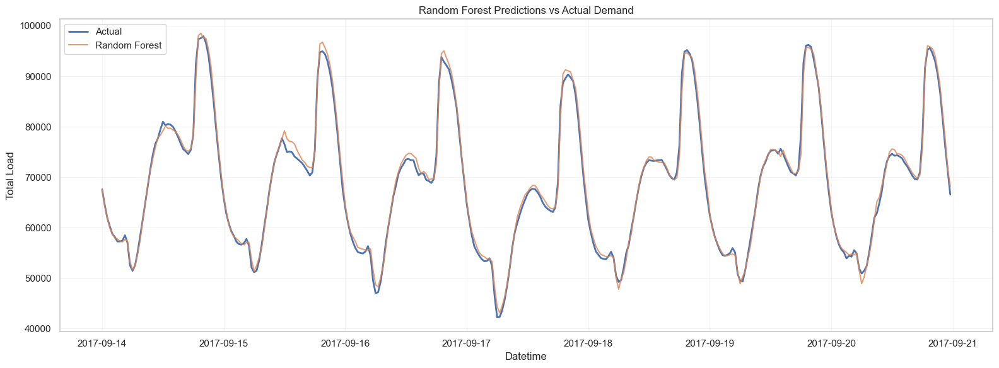

In [211]:
rf_prediction_df = pd.DataFrame({
    "Datetime": validation_df["Datetime"],
    "Actual": y_validation.values,
    "Predicted": rf_validation_pred
})

sample = rf_prediction_df.iloc[:7 * 48]

plt.figure(figsize=(16, 6))

plt.plot(
    sample["Datetime"],
    sample["Actual"],
    label="Actual",
    linewidth=2
)

plt.plot(
    sample["Datetime"],
    sample["Predicted"],
    label="Random Forest",
    alpha=0.8
)

plt.xlabel("Datetime")
plt.ylabel("Total Load")
plt.title("Random Forest Predictions vs Actual Demand")
plt.legend()
plt.grid(alpha=0.2)

plt.tight_layout()
plt.show()

In [212]:
rf_prediction_df["Residual"] = (
    rf_prediction_df["Actual"]
    - rf_prediction_df["Predicted"]
)

print(
    rf_prediction_df["Residual"].describe()
)

count    2544.000000
mean     -312.289550
std      1198.061594
min     -4779.727596
25%      -938.058650
50%      -415.501063
75%       176.793213
max      9373.756619
Name: Residual, dtype: float64


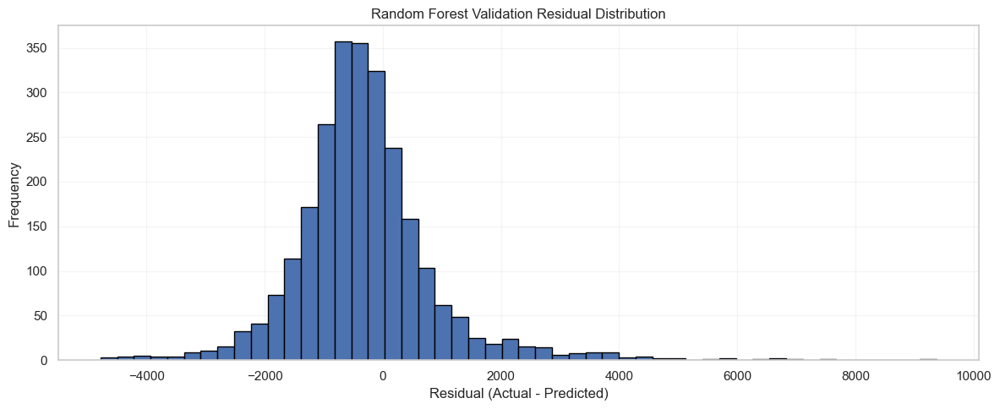

In [213]:
plt.figure(figsize=(12, 5))

plt.hist(
    rf_prediction_df["Residual"],
    bins=50,
    edgecolor="black"
)

plt.xlabel("Residual (Actual - Predicted)")
plt.ylabel("Frequency")
plt.title("Random Forest Validation Residual Distribution")
plt.grid(alpha=0.2)

plt.tight_layout()
plt.show()

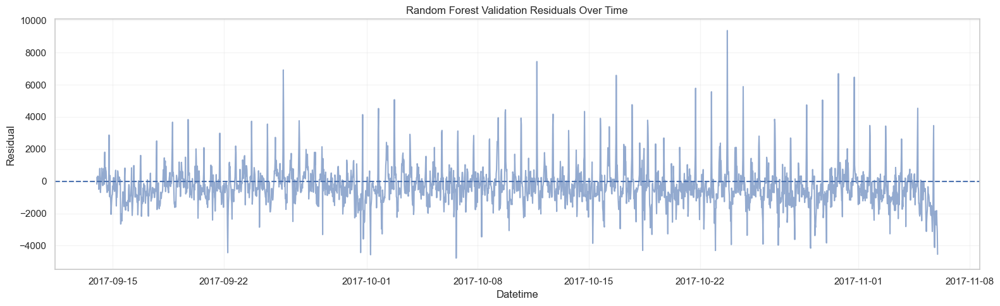

In [214]:
plt.figure(figsize=(16, 5))

plt.plot(
    rf_prediction_df["Datetime"],
    rf_prediction_df["Residual"],
    alpha=0.6
)

plt.axhline(
    0,
    linestyle="--"
)

plt.xlabel("Datetime")
plt.ylabel("Residual")
plt.title("Random Forest Validation Residuals Over Time")
plt.grid(alpha=0.2)

plt.tight_layout()
plt.show()

## Random Forest Feature Importance Findings

The Random Forest feature-importance analysis shows that historical demand
features dominate the model.

The most important variables are `lag_48`, `lag_1`, `lag_336`, `lag_96`,
`rolling_mean_1h`, `lag_2`, and `rolling_mean_2h`. These features represent
recent demand, previous-day demand, previous-week demand, and short-term
historical demand trends.

This result is consistent with the exploratory analysis and baseline
experiments, which demonstrated strong daily and weekly demand persistence.

Calendar variables such as `hour`, `time_slot`, and cyclical time features
also contribute to the model.

The Dhanbad weather variables have comparatively low impurity-based feature
importance in the Random Forest. Similarly, the holiday indicator has very
low importance. This does not imply that weather or holidays have no
predictive value, particularly because only one year of data and a limited
number of holiday observations are available.

The feature-importance results are therefore interpreted as evidence of the
relative contribution of features within this Random Forest rather than as
proof that low-importance variables are universally irrelevant.

# Gradient Boosting Model

A histogram-based gradient boosting regressor is evaluated as a second
machine-learning approach.

Unlike Random Forest, which builds many trees independently and averages their
predictions, gradient boosting builds trees sequentially, with later trees
attempting to correct errors made by earlier trees.

This provides a different modeling strategy for capturing nonlinear
relationships between historical demand, temporal features, weather, and
holiday information.

In [215]:
from sklearn.ensemble import HistGradientBoostingRegressor

gb_model = HistGradientBoostingRegressor(
    max_iter=300,
    learning_rate=0.05,
    max_leaf_nodes=31,
    l2_regularization=1.0,
    random_state=42
)

gb_model.fit(
    X_train,
    y_train
)

print("Gradient Boosting training completed.")

Gradient Boosting training completed.


In [216]:
gb_validation_pred = gb_model.predict(
    X_validation
)

gb_validation_metrics = evaluate_forecast(
    y_validation,
    gb_validation_pred
)

gb_validation_results = pd.DataFrame([
    {
        "Model": "HistGradientBoosting",
        **gb_validation_metrics
    }
])

display(gb_validation_results)

,Model,MAE,RMSE,MAPE (%),R2
0,HistGradientBoosting,726.240171,972.70784,1.120884,0.994642


In [217]:
model_comparison = pd.concat(
    [
        validation_baseline_results,
        rf_validation_results,
        gb_validation_results
    ],
    ignore_index=True
)

display(
    model_comparison.sort_values("MAE")
)

,Model,MAE,RMSE,MAPE (%),R2
4,HistGradientBoosting,726.240171,972.707840,1.120884,0.994642
3,Random Forest,886.035903,1237.865960,1.339229,0.991322
2,Previous week,1803.382192,2376.933234,2.731855,0.968003
1,Previous day,2060.200457,3049.895470,3.200895,0.947320
0,Previous 30 min,2194.247557,3237.733111,3.221066,0.940632


## Gradient Boosting Validation Results

The Histogram-based Gradient Boosting Regressor was evaluated as a second
machine-learning approach.

The model achieved the following validation performance:

- MAE: approximately 726.24
- RMSE: approximately 972.71
- MAPE: approximately 1.12%
- R²: approximately 0.9946

This represents an improvement over both the historical persistence baselines
and the Random Forest model.

Compared with the previous-week baseline, validation MAE decreased from
approximately 1,803.38 to 726.24, while RMSE decreased from approximately
2,376.93 to 972.71.

The results indicate that sequential gradient boosting is able to capture
additional nonlinear relationships within the engineered temporal and
historical-demand features.

However, validation performance alone is not sufficient to select the final
model. Further model analysis and controlled tuning will be performed before
the final model is evaluated on the held-out test period.

In [218]:
from sklearn.inspection import permutation_importance

gb_permutation = permutation_importance(
    gb_model,
    X_validation,
    y_validation,
    n_repeats=5,
    random_state=42,
    scoring="neg_mean_absolute_error",
    n_jobs=-1
)

gb_importance = pd.DataFrame({
    "Feature": X_validation.columns,
    "Importance_Mean": gb_permutation.importances_mean,
    "Importance_Std": gb_permutation.importances_std
})

gb_importance = (
    gb_importance
    .sort_values(
        "Importance_Mean",
        ascending=False
    )
    .reset_index(drop=True)
)

display(gb_importance.head(20))

,Feature,Importance_Mean,Importance_Std
0,lag_1,8587.581433,82.972367
1,lag_48,3417.754362,25.783641
2,historical_change_30min,932.104023,11.006292
3,hour,140.766595,7.492397
4,time_slot_sin,137.097418,8.726210
5,lag_96,121.997448,3.853727
6,day_of_week,120.814232,7.298472
7,lag_336,118.716378,11.324067
8,time_slot_cos,112.940796,5.125508
9,rolling_mean_6h,78.538117,2.532656


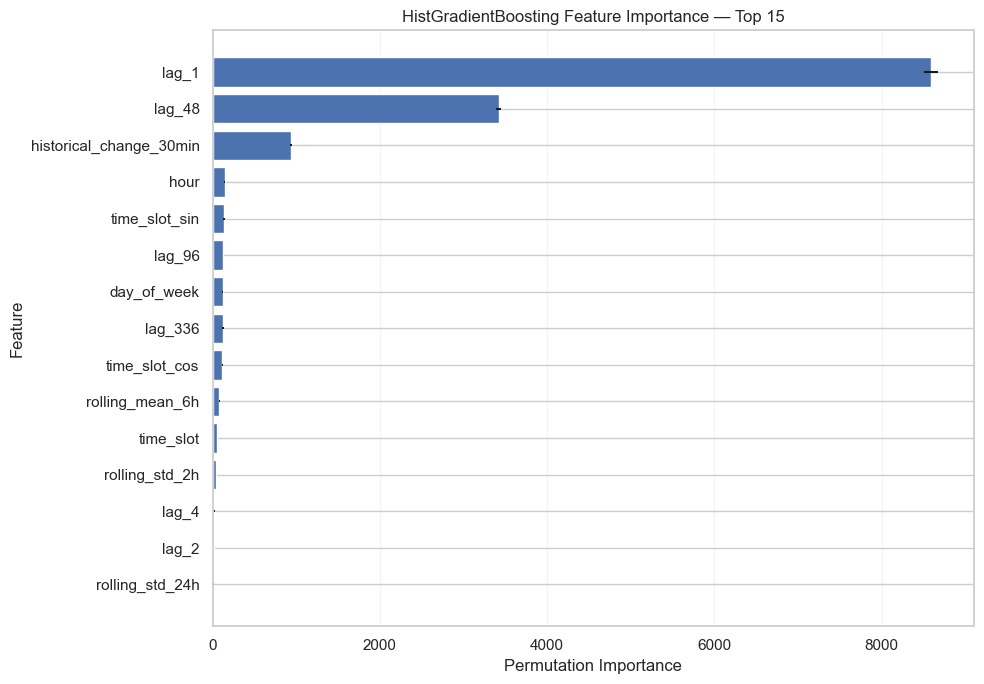

In [219]:
top_gb_features = (
    gb_importance
    .head(15)
    .sort_values(
        "Importance_Mean",
        ascending=True
    )
)

plt.figure(figsize=(10, 7))

plt.barh(
    top_gb_features["Feature"],
    top_gb_features["Importance_Mean"],
    xerr=top_gb_features["Importance_Std"]
)

plt.xlabel("Permutation Importance")
plt.ylabel("Feature")
plt.title("HistGradientBoosting Feature Importance — Top 15")
plt.grid(axis="x", alpha=0.2)

plt.tight_layout()
plt.show()

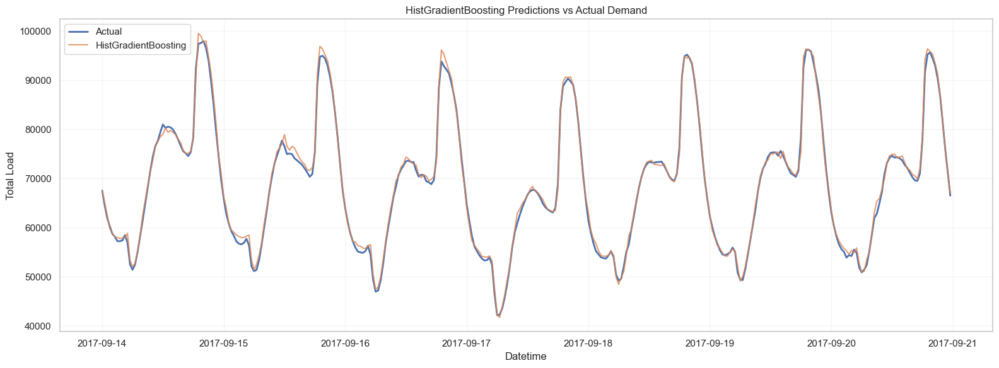

In [220]:
gb_prediction_df = pd.DataFrame({
    "Datetime": validation_df["Datetime"],
    "Actual": y_validation.values,
    "Predicted": gb_validation_pred
})

sample = gb_prediction_df.iloc[:7 * 48]

plt.figure(figsize=(16, 6))

plt.plot(
    sample["Datetime"],
    sample["Actual"],
    label="Actual",
    linewidth=2
)

plt.plot(
    sample["Datetime"],
    sample["Predicted"],
    label="HistGradientBoosting",
    alpha=0.8
)

plt.xlabel("Datetime")
plt.ylabel("Total Load")
plt.title("HistGradientBoosting Predictions vs Actual Demand")
plt.legend()
plt.grid(alpha=0.2)

plt.tight_layout()
plt.show()

In [221]:
gb_prediction_df["Residual"] = (
    gb_prediction_df["Actual"]
    - gb_prediction_df["Predicted"]
)

print(gb_prediction_df["Residual"].describe())

count    2544.000000
mean     -246.685633
std       941.092384
min     -4583.888109
25%      -787.524290
50%      -250.407615
75%       264.321573
max      6070.700820
Name: Residual, dtype: float64


## HistGradientBoosting Feature Importance Findings

Permutation importance was used to investigate the contribution of the
engineered features to the HistGradientBoosting model.

The analysis shows that `lag_1` is the most influential feature, followed by
`lag_48` and `historical_change_30min`. These features represent the previous
30-minute demand, previous-day demand at the same half-hour, and recent demand
movement respectively.

This indicates that short-term persistence and recurring daily demand patterns
are the dominant predictive signals.

Time-based variables such as `hour`, cyclical time features, and
`day_of_week` also contribute to the predictions.

The Dhanbad weather variables have lower permutation importance than the
historical demand features. Nevertheless, they are retained because weather
may provide additional predictive information through nonlinear relationships
and interactions with temporal conditions. The limited one-year dataset also
provides relatively few observations across different seasonal weather
conditions.

The holiday indicator does not appear among the most influential features.
Given the limited number of holiday dates in the dataset, this result is
interpreted cautiously rather than as evidence that holidays have no effect
on electricity demand.

In [222]:
residual_analysis = gb_prediction_df.copy()

residual_analysis["Hour"] = (
    residual_analysis["Datetime"].dt.hour
)

residual_by_hour = (
    residual_analysis
    .groupby("Hour")
    .agg(
        Mean_Residual=("Residual", "mean"),
        MAE=("Residual", lambda x: np.mean(np.abs(x))),
        Count=("Residual", "count")
    )
    .reset_index()
)

display(residual_by_hour)

,Hour,Mean_Residual,MAE,Count
0,0,14.598429,611.287862,106
1,1,-345.110049,723.395388,106
2,2,-445.835674,653.246486,106
3,3,-258.951508,562.515195,106
4,4,-120.995429,646.040784,106
5,5,-228.958350,760.602497,106
6,6,-541.006495,1080.071444,106
7,7,65.959003,892.227834,106
8,8,-662.167486,786.047838,106
9,9,-674.609303,769.552495,106


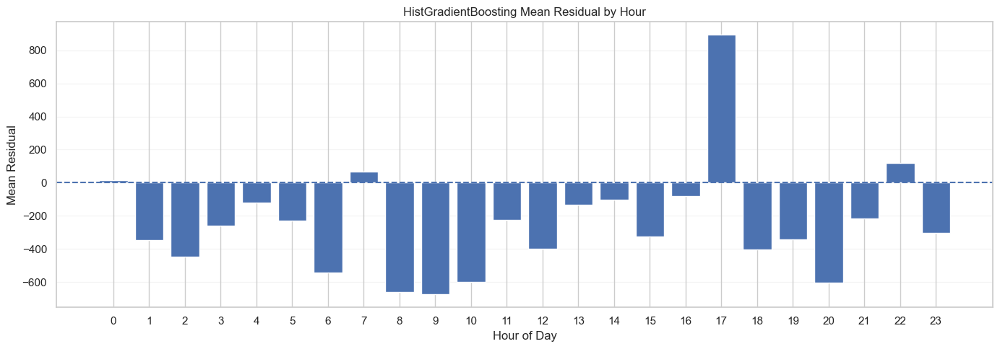

In [223]:
plt.figure(figsize=(14, 5))

plt.bar(
    residual_by_hour["Hour"],
    residual_by_hour["Mean_Residual"]
)

plt.axhline(
    0,
    linestyle="--"
)

plt.xlabel("Hour of Day")
plt.ylabel("Mean Residual")
plt.title("HistGradientBoosting Mean Residual by Hour")
plt.xticks(range(24))
plt.grid(axis="y", alpha=0.2)

plt.tight_layout()
plt.show()

In [224]:
worst_errors = (
    residual_analysis
    .assign(
        Absolute_Error=lambda x: np.abs(x["Residual"])
    )
    .sort_values(
        "Absolute_Error",
        ascending=False
    )
)

display(
    worst_errors.head(20)
)

,Datetime,Actual,Predicted,Residual,Hour,Absolute_Error
13283,2017-10-11 17:30:00,81155.370237,75084.669417,6070.700820,17,6070.700820
13859,2017-10-23 17:30:00,85416.951277,80716.263570,4700.687707,17,4700.687707
13039,2017-10-06 15:30:00,65301.355677,69885.243786,-4583.888109,15,4583.888109
14147,2017-10-29 17:30:00,78980.516987,74455.533473,4524.983513,17,4524.983513
12516,2017-09-25 18:00:00,83580.609253,79252.725629,4327.883624,18,4327.883624
12348,2017-09-22 06:00:00,43863.690802,48125.840828,-4262.150025,6,4262.150025
14484,2017-11-05 18:00:00,83475.186493,87705.941167,-4230.754673,18,4230.754673
12420,2017-09-23 18:00:00,79657.930410,75775.797919,3882.132491,18,3882.132491
13603,2017-10-18 09:30:00,63068.042717,66909.110177,-3841.067460,9,3841.067460
12750,2017-09-30 15:00:00,62695.190900,66520.923891,-3825.732991,15,3825.732991


## Residual Analysis Findings

Hourly residual analysis shows that model errors are not uniformly distributed
throughout the day.

The largest hourly MAE occurs around 17:00, with an MAE of approximately
1,300.70, followed by 18:00 with an MAE of approximately 1,213.75.

At 17:00, the mean residual is approximately +892.86, indicating that the
model tends to underestimate demand during this period. At 18:00, the mean
residual is approximately -403.82, indicating a tendency toward
overprediction.

This period corresponds to the evening demand transition identified during
exploratory analysis, where electricity demand increases substantially during
the late afternoon and evening.

The largest individual validation errors are also concentrated around
17:00–18:00. This suggests that the model has some difficulty capturing the
exact magnitude and timing of rapid evening demand changes.

The residual analysis therefore motivates further model tuning and error
analysis, particularly for rapid demand transitions.

In [225]:
import importlib.util

print(
    "XGBoost installed:",
    importlib.util.find_spec("xgboost") is not None
)

XGBoost installed: False


In [226]:
%pip install xgboost

     ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
     ---------------------------------------- 0.2/101.7 MB 3.3 MB/s eta 0:00:32
     ---------------------------------------- 0.5/101.7 MB 5.4 MB/s eta 0:00:19
     ---------------------------------------- 0.8/101.7 MB 6.5 MB/s eta 0:00:16
     ---------------------------------------- 1.0/101.7 MB 5.5 MB/s eta 0:00:19
     ---------------------------------------- 1.0/101.7 MB 5.5 MB/s eta 0:00:19
     ---------------------------------------- 1.0/101.7 MB 5.5 MB/s eta 0:00:19
     ---------------------------------------- 1.0/101.7 MB 5.5 MB/s eta 0:00:19
     ---------------------------------------- 1.0/101.7 MB 5.5 MB/s eta 0:00:19
     ---------------------------------------- 1.0/101.7 MB 5.5 MB/s eta 0:00:19
     ---------------------------------------- 1.0/101.7 MB 5.5 MB/s eta 0:00:19
      --------------------------------------- 1.4/101.7 MB 2.8 MB/s eta 0:00:37
      --------------------------------------- 1


[notice] A new release of pip is available: 23.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [227]:
import xgboost as xgb

print("XGBoost version:", xgb.__version__)

XGBoost version: 3.2.0


In [228]:
xgb_model = xgb.XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    min_child_weight=1,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="reg:squarederror",
    random_state=42,
    n_jobs=-1
)

xgb_model.fit(
    X_train,
    y_train
)

print("XGBoost training completed.")

XGBoost training completed.


In [229]:
xgb_validation_pred = xgb_model.predict(X_validation)

print("Validation predictions generated.")
print("Number of predictions:", len(xgb_validation_pred))

Validation predictions generated.
Number of predictions: 2544


In [230]:
xgb_validation_metrics = evaluate_forecast(
    y_validation,
    xgb_validation_pred
)

xgb_validation_metrics

{'MAE': 718.9554215665945,
 'RMSE': np.float64(954.059686503087),
 'MAPE (%)': np.float64(1.106759794611184),
 'R2': 0.9948450628892024}

In [231]:
model_comparison = pd.DataFrame([
    {
        "Model": "Previous Week",
        **evaluate_forecast(y_validation, validation_df["lag_336"])
    },
    {
        "Model": "Previous Day",
        **evaluate_forecast(y_validation, validation_df["lag_48"])
    },
    {
        "Model": "Previous 30 Min",
        **evaluate_forecast(y_validation, validation_df["lag_1"])
    },
    {
        "Model": "Random Forest",
        **evaluate_forecast(y_validation, rf_validation_pred)
    },
    {
        "Model": "HistGradientBoosting",
        **evaluate_forecast(y_validation, gb_validation_pred)
    },
    {
        "Model": "XGBoost",
        **evaluate_forecast(y_validation, xgb_validation_pred)
    }
])

model_comparison

,Model,MAE,RMSE,MAPE (%),R2
0,Previous Week,1803.382192,2376.933234,2.731855,0.968003
1,Previous Day,2060.200457,3049.895470,3.200895,0.947320
2,Previous 30 Min,2194.247557,3237.733111,3.221066,0.940632
3,Random Forest,886.035903,1237.865960,1.339229,0.991322
4,HistGradientBoosting,726.240171,972.707840,1.120884,0.994642
5,XGBoost,718.955422,954.059687,1.106760,0.994845


In [232]:
model_comparison.sort_values("MAE")

,Model,MAE,RMSE,MAPE (%),R2
5,XGBoost,718.955422,954.059687,1.106760,0.994845
4,HistGradientBoosting,726.240171,972.707840,1.120884,0.994642
3,Random Forest,886.035903,1237.865960,1.339229,0.991322
0,Previous Week,1803.382192,2376.933234,2.731855,0.968003
1,Previous Day,2060.200457,3049.895470,3.200895,0.947320
2,Previous 30 Min,2194.247557,3237.733111,3.221066,0.940632


In [233]:
model_comparison.sort_values("RMSE")

,Model,MAE,RMSE,MAPE (%),R2
5,XGBoost,718.955422,954.059687,1.106760,0.994845
4,HistGradientBoosting,726.240171,972.707840,1.120884,0.994642
3,Random Forest,886.035903,1237.865960,1.339229,0.991322
0,Previous Week,1803.382192,2376.933234,2.731855,0.968003
1,Previous Day,2060.200457,3049.895470,3.200895,0.947320
2,Previous 30 Min,2194.247557,3237.733111,3.221066,0.940632


In [234]:
xgb_baseline_metrics = evaluate_forecast(
    y_validation,
    xgb_validation_pred
)

xgb_baseline_metrics

{'MAE': 718.9554215665945,
 'RMSE': np.float64(954.059686503087),
 'MAPE (%)': np.float64(1.106759794611184),
 'R2': 0.9948450628892024}

## XGBoost Model Comparison

XGBoost was evaluated as an additional gradient-boosting model using the same
chronological training and validation split used for the previous models.

The untuned XGBoost model achieved a validation MAE of approximately 718.96,
RMSE of 954.06, MAPE of 1.11%, and R² of 0.9948.

Among the evaluated models, XGBoost currently provides the lowest validation
MAE and RMSE, as well as the highest validation R². Its performance is only
slightly better than HistGradientBoosting, indicating that both boosting
approaches are highly effective for this forecasting problem.

Random Forest performs less accurately than both boosting approaches, while
all machine-learning models substantially outperform the simple historical
baselines.

XGBoost will therefore be selected as the primary candidate for
hyperparameter tuning. The validation set will be used for tuning and model
selection, while the test set remains untouched until the final evaluation.

In [235]:
from sklearn.ensemble import ExtraTreesRegressor

extra_trees_model = ExtraTreesRegressor(
    n_estimators=300,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    max_features=1.0,
    random_state=42,
    n_jobs=-1
)

extra_trees_model.fit(
    X_train,
    y_train
)

extra_trees_validation_pred = extra_trees_model.predict(X_validation)

extra_trees_validation_metrics = evaluate_forecast(
    y_validation,
    extra_trees_validation_pred
)

extra_trees_validation_metrics

{'MAE': 692.6064153960011,
 'RMSE': np.float64(993.398599501245),
 'MAPE (%)': np.float64(1.0533627277686548),
 'R2': 0.9944111897138563}

In [236]:
model_comparison = pd.concat([
    model_comparison,
    pd.DataFrame([{
        "Model": "Extra Trees",
        **extra_trees_validation_metrics
    }])
], ignore_index=True)

model_comparison.sort_values("MAE")

,Model,MAE,RMSE,MAPE (%),R2
6,Extra Trees,692.606415,993.398600,1.053363,0.994411
5,XGBoost,718.955422,954.059687,1.106760,0.994845
4,HistGradientBoosting,726.240171,972.707840,1.120884,0.994642
3,Random Forest,886.035903,1237.865960,1.339229,0.991322
0,Previous Week,1803.382192,2376.933234,2.731855,0.968003
1,Previous Day,2060.200457,3049.895470,3.200895,0.947320
2,Previous 30 Min,2194.247557,3237.733111,3.221066,0.940632


In [237]:
import importlib.util

print("LightGBM installed:", importlib.util.find_spec("lightgbm") is not None)

LightGBM installed: False


In [238]:
%pip install lightgbm

     ---------------------------------------- 0.0/1.4 MB ? eta -:--:--
     - -------------------------------------- 0.1/1.4 MB 3.4 MB/s eta 0:00:01
     ---------- ----------------------------- 0.4/1.4 MB 4.6 MB/s eta 0:00:01
     ------------------ --------------------- 0.6/1.4 MB 5.5 MB/s eta 0:00:01
     --------------------- ------------------ 0.7/1.4 MB 3.9 MB/s eta 0:00:01
     ---------------------------------- ----- 1.2/1.4 MB 5.3 MB/s eta 0:00:01
     -------------------------------------- - 1.3/1.4 MB 4.6 MB/s eta 0:00:01
     ---------------------------------------- 1.4/1.4 MB 4.5 MB/s eta 0:00:00
     ---------------------------------------- 0.0/474.0 kB ? eta -:--:--
     -------------------------------------  471.0/474.0 kB 9.8 MB/s eta 0:00:01
     -------------------------------------- 474.0/474.0 kB 9.9 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 23.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [239]:
import lightgbm as lgb

print("LightGBM version:", lgb.__version__)

LightGBM version: 4.7.0


In [240]:
import lightgbm as lgb

lgb_model = lgb.LGBMRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=-1,
    num_leaves=31,
    min_child_samples=20,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.0,
    reg_lambda=0.0,
    random_state=42,
    n_jobs=-1,
    verbosity=-1
)

lgb_model.fit(
    X_train,
    y_train
)

lgb_validation_pred = lgb_model.predict(X_validation)

lgb_validation_metrics = evaluate_forecast(
    y_validation,
    lgb_validation_pred
)

lgb_validation_metrics

{'MAE': 785.6318907408337,
 'RMSE': np.float64(1024.8156899530984),
 'MAPE (%)': np.float64(1.2165314686419981),
 'R2': 0.9940520978873719}

In [241]:
model_comparison = pd.concat([
    model_comparison,
    pd.DataFrame([{
        "Model": "LightGBM",
        **lgb_validation_metrics
    }])
], ignore_index=True)

model_comparison.sort_values("MAE")

,Model,MAE,RMSE,MAPE (%),R2
6,Extra Trees,692.606415,993.398600,1.053363,0.994411
5,XGBoost,718.955422,954.059687,1.106760,0.994845
4,HistGradientBoosting,726.240171,972.707840,1.120884,0.994642
7,LightGBM,785.631891,1024.815690,1.216531,0.994052
3,Random Forest,886.035903,1237.865960,1.339229,0.991322
0,Previous Week,1803.382192,2376.933234,2.731855,0.968003
1,Previous Day,2060.200457,3049.895470,3.200895,0.947320
2,Previous 30 Min,2194.247557,3237.733111,3.221066,0.940632


In [242]:
import importlib.util

print("CatBoost installed:", importlib.util.find_spec("catboost") is not None)

CatBoost installed: False


In [243]:
%pip install catboost

Note: you may need to restart the kernel to use updated packages.Collecting catboost
     ---------------------------------------- 0.0/100.2 MB ? eta -:--:--
     -------------------------------------- 0.0/100.2 MB 640.0 kB/s eta 0:02:37
     ---------------------------------------- 0.4/100.2 MB 4.9 MB/s eta 0:00:21
     ---------------------------------------- 0.7/100.2 MB 5.2 MB/s eta 0:00:19
     ---------------------------------------- 0.9/100.2 MB 5.1 MB/s eta 0:00:20
     ---------------------------------------- 1.0/100.2 MB 4.7 MB/s eta 0:00:22
     ---------------------------------------- 1.0/100.2 MB 4.7 MB/s eta 0:00:22
     ---------------------------------------- 1.0/100.2 MB 4.7 MB/s eta 0:00:22
     ---------------------------------------- 1.2/100.2 MB 3.2 MB/s eta 0:00:31
      --------------------------------------- 1.5/100.2 MB 3.6 MB/s eta 0:00:28
      --------------------------------------- 1.9/100.2 MB 4.0 MB/s eta 0:00:25
      ------------------------------------


[notice] A new release of pip is available: 23.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [244]:
import catboost

print("CatBoost version:", catboost.__version__)

CatBoost version: 1.2.10


In [245]:
from catboost import CatBoostRegressor

catboost_model = CatBoostRegressor(
    iterations=500,
    learning_rate=0.05,
    depth=6,
    loss_function="RMSE",
    random_seed=42,
    verbose=False,
    thread_count=-1
)

catboost_model.fit(
    X_train,
    y_train
)

catboost_validation_pred = catboost_model.predict(X_validation)

catboost_validation_metrics = evaluate_forecast(
    y_validation,
    catboost_validation_pred
)

catboost_validation_metrics

{'MAE': 794.659092307999,
 'RMSE': np.float64(1060.3718371279253),
 'MAPE (%)': np.float64(1.2110996077290586),
 'R2': 0.9936322112106039}

In [246]:
model_comparison = pd.concat([
    model_comparison,
    pd.DataFrame([{
        "Model": "CatBoost",
        **catboost_validation_metrics
    }])
], ignore_index=True)

model_comparison.sort_values("MAE")


,Model,MAE,RMSE,MAPE (%),R2
6,Extra Trees,692.606415,993.398600,1.053363,0.994411
5,XGBoost,718.955422,954.059687,1.106760,0.994845
4,HistGradientBoosting,726.240171,972.707840,1.120884,0.994642
7,LightGBM,785.631891,1024.815690,1.216531,0.994052
8,CatBoost,794.659092,1060.371837,1.211100,0.993632
3,Random Forest,886.035903,1237.865960,1.339229,0.991322
0,Previous Week,1803.382192,2376.933234,2.731855,0.968003
1,Previous Day,2060.200457,3049.895470,3.200895,0.947320
2,Previous 30 Min,2194.247557,3237.733111,3.221066,0.940632


In [247]:
import importlib.util

print("TensorFlow installed:", importlib.util.find_spec("tensorflow") is not None)

TensorFlow installed: False


In [248]:
%pip install tensorflow

     ---------------------------------------- 0.0/350.6 MB ? eta -:--:--
     ---------------------------------------- 0.1/350.6 MB 4.3 MB/s eta 0:01:22
     ---------------------------------------- 0.6/350.6 MB 8.1 MB/s eta 0:00:43
     ---------------------------------------- 0.8/350.6 MB 6.0 MB/s eta 0:00:59
     ---------------------------------------- 0.9/350.6 MB 5.4 MB/s eta 0:01:05
     ---------------------------------------- 1.1/350.6 MB 5.1 MB/s eta 0:01:08
     ---------------------------------------- 1.4/350.6 MB 5.1 MB/s eta 0:01:09
     ---------------------------------------- 1.5/350.6 MB 4.9 MB/s eta 0:01:12
     ---------------------------------------- 1.8/350.6 MB 4.8 MB/s eta 0:01:12
     ---------------------------------------- 2.0/350.6 MB 4.8 MB/s eta 0:01:13
     ---------------------------------------- 2.1/350.6 MB 4.7 MB/s eta 0:01:15
     ---------------------------------------- 2.3/350.6 MB 4.6 MB/s eta 0:01:16
     ---------------------------------------- 2


[notice] A new release of pip is available: 23.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [250]:
import tensorflow as tf

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.21.0


In [251]:
feature_columns = X_train.columns.tolist()

print("Number of features:", len(feature_columns))
print(feature_columns)

Number of features: 34
['hour', 'minute', 'day_of_week', 'day_of_month', 'month', 'day_of_year', 'week_of_year', 'is_weekend', 'time_slot', 'time_slot_sin', 'time_slot_cos', 'day_of_week_sin', 'day_of_week_cos', 'day_of_year_sin', 'day_of_year_cos', 'is_holiday', 'Dhanbad_Temperature', 'Dhanbad_Humidity', 'Dhanbad_CloudCover', 'Dhanbad_WindSpeed', 'Temperature_Humidity', 'lag_1', 'lag_2', 'lag_4', 'lag_48', 'lag_96', 'lag_336', 'rolling_mean_1h', 'rolling_mean_2h', 'rolling_mean_6h', 'rolling_mean_24h', 'rolling_std_2h', 'rolling_std_24h', 'historical_change_30min']


In [252]:
from sklearn.preprocessing import StandardScaler

X_scaler = StandardScaler()

X_train_scaled = X_scaler.fit_transform(X_train)

X_validation_scaled = X_scaler.transform(X_validation)

X_test_scaled = X_scaler.transform(X_test)

In [253]:
y_scaler = StandardScaler()

y_train_scaled = y_scaler.fit_transform(
    y_train.to_numpy().reshape(-1, 1)
).flatten()

y_validation_scaled = y_scaler.transform(
    y_validation.to_numpy().reshape(-1, 1)
).flatten()

y_test_scaled = y_scaler.transform(
    y_test.to_numpy().reshape(-1, 1)
).flatten()

In [254]:
LOOKBACK = 48

In [255]:
import numpy as np

def create_sequences(X, y, lookback):
    X_sequences = []
    y_targets = []

    for i in range(lookback, len(X)):
        X_sequences.append(X[i-lookback:i])
        y_targets.append(y[i])

    return np.array(X_sequences), np.array(y_targets)

In [256]:
X_train_seq, y_train_seq = create_sequences(
    X_train_scaled,
    y_train_scaled,
    LOOKBACK
)

X_validation_seq, y_validation_seq = create_sequences(
    X_validation_scaled,
    y_validation_scaled,
    LOOKBACK
)

print("Training sequence shape:", X_train_seq.shape)
print("Training target shape:", y_train_seq.shape)

print("Validation sequence shape:", X_validation_seq.shape)
print("Validation target shape:", y_validation_seq.shape)

Training sequence shape: (11904, 48, 34)
Training target shape: (11904,)
Validation sequence shape: (2496, 48, 34)
Validation target shape: (2496,)


In [257]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

lstm_model = Sequential([
    LSTM(
        64,
        input_shape=(LOOKBACK, X_train_seq.shape[2]),
        return_sequences=False
    ),
    
    Dropout(0.2),
    
    Dense(32, activation="relu"),
    
    Dropout(0.1),
    
    Dense(1)
])

lstm_model.compile(
    optimizer="adam",
    loss="mse",
    metrics=["mae"]
)

lstm_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                          │ (None, 64)                  │          25,344 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 32)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │              33 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 27,457 (107.25 KB)

 Trainable params: 27,457 (107.25 KB)

 Non-trainable params: 0 (0.00 B)

In [258]:
early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True
)

In [259]:
history = lstm_model.fit(
    X_train_seq,
    y_train_seq,
    validation_data=(
        X_validation_seq,
        y_validation_seq
    ),
    epochs=50,
    batch_size=64,
    callbacks=[early_stopping],
    verbose=1
)

Epoch 1/50
186/186 ━━━━━━━━━━━━━━━━━━━━ 5s 19ms/step - loss: 0.1879 - mae: 0.3144 - val_loss: 0.0671 - val_mae: 0.1875
Epoch 2/50
186/186 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - loss: 0.0717 - mae: 0.2037 - val_loss: 0.0479 - val_mae: 0.1583
Epoch 3/50
186/186 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step - loss: 0.0525 - mae: 0.1745 - val_loss: 0.0410 - val_mae: 0.1520
Epoch 4/50
186/186 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step - loss: 0.0439 - mae: 0.1575 - val_loss: 0.0374 - val_mae: 0.1481
Epoch 5/50
186/186 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step - loss: 0.0397 - mae: 0.1499 - val_loss: 0.0284 - val_mae: 0.1263
Epoch 6/50
186/186 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step - loss: 0.0359 - mae: 0.1413 - val_loss: 0.0295 - val_mae: 0.1277
Epoch 7/50
186/186 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step - loss: 0.0330 - mae: 0.1371 - val_loss: 0.0294 - val_mae: 0.1210
Epoch 8/50
186/186 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - loss: 0.0310 - mae: 0.1310 - val_loss: 0.0210 - val_mae: 0.1089
Epoch 9/50
186/186 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/

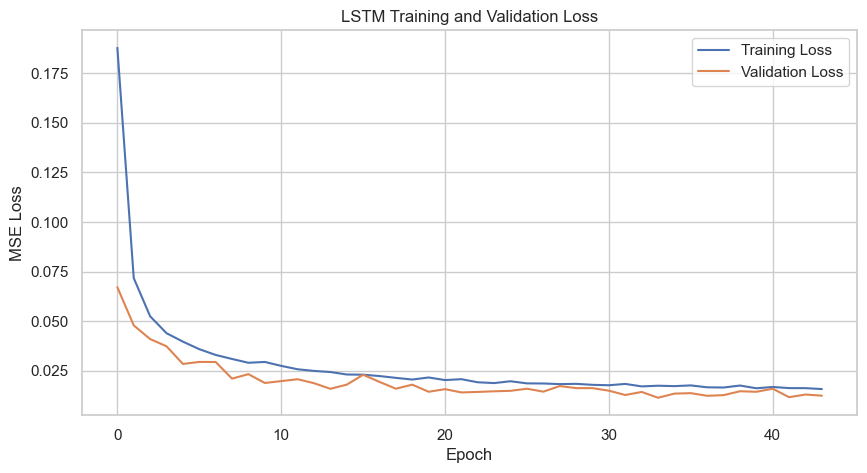

In [260]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

plt.plot(
    history.history["loss"],
    label="Training Loss"
)

plt.plot(
    history.history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("LSTM Training and Validation Loss")

plt.legend()
plt.show()

In [261]:
lstm_validation_pred_scaled = lstm_model.predict(
    X_validation_seq,
    verbose=0
)

lstm_validation_pred = y_scaler.inverse_transform(
    lstm_validation_pred_scaled
).flatten()

In [262]:
lstm_validation_actual = y_scaler.inverse_transform(
    y_validation_seq.reshape(-1, 1)
).flatten()

In [263]:
lstm_validation_metrics = evaluate_forecast(
    lstm_validation_actual,
    lstm_validation_pred
)

lstm_validation_metrics

{'MAE': 1468.7911357171474,
 'RMSE': np.float64(1909.053408245965),
 'MAPE (%)': np.float64(2.3562782642053763),
 'R2': 0.979310549000289}

In [264]:
model_comparison = pd.concat([
    model_comparison,
    pd.DataFrame([{
        "Model": "LSTM",
        **lstm_validation_metrics
    }])
], ignore_index=True)

model_comparison.sort_values("MAE")

,Model,MAE,RMSE,MAPE (%),R2
6,Extra Trees,692.606415,993.398600,1.053363,0.994411
5,XGBoost,718.955422,954.059687,1.106760,0.994845
4,HistGradientBoosting,726.240171,972.707840,1.120884,0.994642
7,LightGBM,785.631891,1024.815690,1.216531,0.994052
8,CatBoost,794.659092,1060.371837,1.211100,0.993632
3,Random Forest,886.035903,1237.865960,1.339229,0.991322
9,LSTM,1468.791136,1909.053408,2.356278,0.979311
0,Previous Week,1803.382192,2376.933234,2.731855,0.968003
1,Previous Day,2060.200457,3049.895470,3.200895,0.947320
2,Previous 30 Min,2194.247557,3237.733111,3.221066,0.940632


In [265]:
from sklearn.ensemble import ExtraTreesRegressor
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint, uniform

In [266]:
extra_trees_base = ExtraTreesRegressor(
    random_state=42,
    n_jobs=-1
)

extra_trees_param_dist = {
    "n_estimators": randint(200, 700),
    "max_depth": [None, 10, 15, 20, 25, 30, 40, 50],
    "min_samples_split": randint(2, 10),
    "min_samples_leaf": randint(1, 5),
    "max_features": [1.0, "sqrt", "log2", 0.7, 0.8, 0.9],
    "bootstrap": [False, True]
}

In [268]:
import numpy as np
import pandas as pd
import time
from sklearn.ensemble import ExtraTreesRegressor

N_ITER = 20

rng = np.random.RandomState(42)

search_results = []

start_time = time.time()

for i in range(N_ITER):

    # Sample max_features separately so numeric values
    # remain floats instead of being converted to strings.
    max_features_options = [
        1.0,
        "sqrt",
        "log2",
        0.7,
        0.8,
        0.9
    ]

    max_features = max_features_options[
        rng.randint(len(max_features_options))
    ]

    params = {
        "n_estimators": int(rng.randint(200, 701)),
        "max_depth": rng.choice(
            [None, 10, 15, 20, 25, 30, 40, 50]
        ),
        "min_samples_split": int(rng.randint(2, 10)),
        "min_samples_leaf": int(rng.randint(1, 5)),
        "max_features": max_features,
        "bootstrap": bool(rng.choice([False, True]))
    }

    model = ExtraTreesRegressor(
        random_state=42,
        n_jobs=-1,
        **params
    )

    model.fit(X_train, y_train)

    validation_pred = model.predict(X_validation)

    metrics = evaluate_forecast(
        y_validation,
        validation_pred
    )

    search_results.append({
        "iteration": i + 1,
        **params,
        **metrics
    })

    print(
        f"Iteration {i + 1}/{N_ITER} | "
        f"MAE: {metrics['MAE']:.2f} | "
        f"RMSE: {metrics['RMSE']:.2f} | "
        f"MAPE: {metrics['MAPE (%)']:.4f}% | "
        f"R2: {metrics['R2']:.6f}"
    )

print(
    f"\nSearch completed in "
    f"{(time.time() - start_time) / 60:.2f} minutes."
)

Iteration 1/20 | MAE: 714.92 | RMSE: 1042.07 | MAPE: 1.0813% | R2: 0.993850
Iteration 2/20 | MAE: 789.59 | RMSE: 1142.98 | MAPE: 1.1901% | R2: 0.992601
Iteration 3/20 | MAE: 1187.73 | RMSE: 1640.38 | MAPE: 1.7822% | R2: 0.984761
Iteration 4/20 | MAE: 1201.30 | RMSE: 1654.09 | MAPE: 1.8003% | R2: 0.984505
Iteration 5/20 | MAE: 783.64 | RMSE: 1136.76 | MAPE: 1.1829% | R2: 0.992682
Iteration 6/20 | MAE: 783.02 | RMSE: 1136.73 | MAPE: 1.1856% | R2: 0.992682
Iteration 7/20 | MAE: 716.32 | RMSE: 1053.95 | MAPE: 1.0845% | R2: 0.993709
Iteration 8/20 | MAE: 729.32 | RMSE: 1063.36 | MAPE: 1.1036% | R2: 0.993596
Iteration 9/20 | MAE: 728.97 | RMSE: 1064.64 | MAPE: 1.1030% | R2: 0.993581
Iteration 10/20 | MAE: 698.44 | RMSE: 1015.41 | MAPE: 1.0610% | R2: 0.994161
Iteration 11/20 | MAE: 774.85 | RMSE: 1123.62 | MAPE: 1.1748% | R2: 0.992850
Iteration 12/20 | MAE: 785.13 | RMSE: 1131.47 | MAPE: 1.1871% | R2: 0.992750
Iteration 13/20 | MAE: 1184.04 | RMSE: 1585.69 | MAPE: 1.7815% | R2: 0.985760
Itera

In [269]:
extra_trees_search_results = pd.DataFrame(search_results)

extra_trees_search_results.sort_values(
    "MAE"
).head(10)

,iteration,n_estimators,max_depth,min_samples_split,min_samples_leaf,max_features,bootstrap,MAE,RMSE,MAPE (%),R2
9,10,330,25,4,3,1.0,False,698.442315,1015.410031,1.061040,0.994161
13,14,463,40,4,2,0.7,False,700.341031,1009.247807,1.059739,0.994231
19,20,407,25,3,3,0.8,False,704.672828,1022.895430,1.065133,0.994074
18,19,414,20,2,2,0.9,True,708.363436,1034.090174,1.074037,0.993944
0,1,548,40,4,4,0.7,False,714.918015,1042.072924,1.081288,0.993850
14,15,249,50,5,2,0.7,True,716.116617,1047.770373,1.086104,0.993783
6,7,248,15,4,3,1.0,True,716.319105,1053.949680,1.084461,0.993709
8,9,250,20,8,4,0.9,True,728.971306,1064.641429,1.102973,0.993581
7,8,387,50,8,2,0.7,True,729.319972,1063.360326,1.103579,0.993596
17,18,469,40,9,3,0.7,True,737.209203,1078.157282,1.114522,0.993417


In [270]:
focused_params = [
    {
        "n_estimators": 400,
        "max_depth": None,
        "min_samples_split": 2,
        "min_samples_leaf": 1,
        "max_features": 1.0,
        "bootstrap": False
    },
    {
        "n_estimators": 500,
        "max_depth": None,
        "min_samples_split": 2,
        "min_samples_leaf": 1,
        "max_features": 1.0,
        "bootstrap": False
    },
    {
        "n_estimators": 700,
        "max_depth": None,
        "min_samples_split": 2,
        "min_samples_leaf": 1,
        "max_features": 1.0,
        "bootstrap": False
    },
    {
        "n_estimators": 500,
        "max_depth": 30,
        "min_samples_split": 2,
        "min_samples_leaf": 1,
        "max_features": 1.0,
        "bootstrap": False
    },
    {
        "n_estimators": 500,
        "max_depth": 40,
        "min_samples_split": 2,
        "min_samples_leaf": 1,
        "max_features": 1.0,
        "bootstrap": False
    },
    {
        "n_estimators": 500,
        "max_depth": None,
        "min_samples_split": 3,
        "min_samples_leaf": 1,
        "max_features": 1.0,
        "bootstrap": False
    },
    {
        "n_estimators": 500,
        "max_depth": None,
        "min_samples_split": 2,
        "min_samples_leaf": 2,
        "max_features": 1.0,
        "bootstrap": False
    },
    {
        "n_estimators": 500,
        "max_depth": None,
        "min_samples_split": 3,
        "min_samples_leaf": 2,
        "max_features": 0.9,
        "bootstrap": False
    },
    {
        "n_estimators": 500,
        "max_depth": 30,
        "min_samples_split": 3,
        "min_samples_leaf": 2,
        "max_features": 0.9,
        "bootstrap": False
    },
    {
        "n_estimators": 500,
        "max_depth": 40,
        "min_samples_split": 3,
        "min_samples_leaf": 2,
        "max_features": 0.8,
        "bootstrap": False
    }
]

In [271]:
focused_results = []

for i, params in enumerate(focused_params, start=1):

    model = ExtraTreesRegressor(
        random_state=42,
        n_jobs=-1,
        **params
    )

    model.fit(X_train, y_train)

    pred = model.predict(X_validation)

    metrics = evaluate_forecast(
        y_validation,
        pred
    )

    focused_results.append({
        "iteration": i,
        **params,
        **metrics
    })

    print(
        f"Iteration {i}/10 | "
        f"MAE: {metrics['MAE']:.2f} | "
        f"RMSE: {metrics['RMSE']:.2f} | "
        f"MAPE: {metrics['MAPE (%)']:.4f}% | "
        f"R2: {metrics['R2']:.6f}"
    )

Iteration 1/10 | MAE: 691.13 | RMSE: 988.93 | MAPE: 1.0518% | R2: 0.994461
Iteration 2/10 | MAE: 690.15 | RMSE: 986.83 | MAPE: 1.0509% | R2: 0.994485
Iteration 3/10 | MAE: 688.32 | RMSE: 986.35 | MAPE: 1.0488% | R2: 0.994490
Iteration 4/10 | MAE: 688.58 | RMSE: 984.43 | MAPE: 1.0489% | R2: 0.994512
Iteration 5/10 | MAE: 690.15 | RMSE: 986.83 | MAPE: 1.0509% | R2: 0.994485
Iteration 6/10 | MAE: 696.54 | RMSE: 997.78 | MAPE: 1.0606% | R2: 0.994362
Iteration 7/10 | MAE: 691.40 | RMSE: 1000.75 | MAPE: 1.0506% | R2: 0.994328
Iteration 8/10 | MAE: 695.09 | RMSE: 1003.27 | MAPE: 1.0555% | R2: 0.994300
Iteration 9/10 | MAE: 694.37 | RMSE: 1000.79 | MAPE: 1.0546% | R2: 0.994328
Iteration 10/10 | MAE: 696.20 | RMSE: 1007.11 | MAPE: 1.0571% | R2: 0.994256


In [272]:
focused_results_df = pd.DataFrame(focused_results)

focused_results_df.sort_values("MAE")

,iteration,n_estimators,max_depth,min_samples_split,min_samples_leaf,max_features,bootstrap,MAE,RMSE,MAPE (%),R2
2,3,700,NaN,2,1,1.0,False,688.318701,986.345609,1.048845,0.994490
3,4,500,30.0,2,1,1.0,False,688.580514,984.431113,1.048911,0.994512
1,2,500,NaN,2,1,1.0,False,690.148542,986.831304,1.050930,0.994485
4,5,500,40.0,2,1,1.0,False,690.148542,986.831304,1.050930,0.994485
0,1,400,NaN,2,1,1.0,False,691.129843,988.930742,1.051784,0.994461
6,7,500,NaN,2,2,1.0,False,691.396947,1000.745740,1.050646,0.994328
8,9,500,30.0,3,2,0.9,False,694.371861,1000.794203,1.054570,0.994328
7,8,500,NaN,3,2,0.9,False,695.092857,1003.265249,1.055479,0.994300
9,10,500,40.0,3,2,0.8,False,696.203567,1007.111045,1.057106,0.994256
5,6,500,NaN,3,1,1.0,False,696.536525,997.775043,1.060634,0.994362


In [273]:
extra_trees_tuned_mae = ExtraTreesRegressor(
    n_estimators=700,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=2,
    max_features=1.0,
    bootstrap=False,
    random_state=42,
    n_jobs=-1
)

extra_trees_tuned_rmse = ExtraTreesRegressor(
    n_estimators=500,
    max_depth=30,
    min_samples_split=2,
    min_samples_leaf=2,
    max_features=1.0,
    bootstrap=False,
    random_state=42,
    n_jobs=-1
)

In [274]:
extra_trees_tuned_mae.fit(X_train, y_train)

extra_trees_tuned_rmse.fit(X_train, y_train)

,n_estimators,500
,criterion,'squared_error'
,max_depth,30
,min_samples_split,2
,min_samples_leaf,2
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,False
,oob_score,False


In [275]:
extra_trees_tuned_mae_pred = extra_trees_tuned_mae.predict(X_validation)

extra_trees_tuned_rmse_pred = extra_trees_tuned_rmse.predict(X_validation)

In [276]:
extra_trees_tuned_mae_metrics = evaluate_forecast(
    y_validation,
    extra_trees_tuned_mae_pred
)

extra_trees_tuned_rmse_metrics = evaluate_forecast(
    y_validation,
    extra_trees_tuned_rmse_pred
)

print("Extra Trees tuned for MAE:")
print(extra_trees_tuned_mae_metrics)

print("\nExtra Trees tuned for RMSE:")
print(extra_trees_tuned_rmse_metrics)

Extra Trees tuned for MAE:
{'MAE': 690.329908769813, 'RMSE': np.float64(997.0916886526659), 'MAPE (%)': np.float64(1.0493209034366509), 'R2': 0.9943695582065251}

Extra Trees tuned for RMSE:
{'MAE': 691.2798931416717, 'RMSE': np.float64(999.8615435416864), 'MAPE (%)': np.float64(1.0504251748807112), 'R2': 0.9943382327656437}


In [277]:
import numpy as np
import pandas as pd
import time
import xgboost as xgb

rng = np.random.RandomState(42)

N_ITER_XGB = 30

xgb_search_results = []

start_time = time.time()

for i in range(N_ITER_XGB):

    params = {
        "n_estimators": int(rng.randint(300, 801)),
        "learning_rate": float(
            rng.uniform(0.02, 0.10)
        ),
        "max_depth": int(
            rng.randint(3, 10)
        ),
        "min_child_weight": int(
            rng.randint(1, 8)
        ),
        "subsample": float(
            rng.uniform(0.7, 1.0)
        ),
        "colsample_bytree": float(
            rng.uniform(0.7, 1.0)
        ),
        "gamma": float(
            rng.uniform(0.0, 0.5)
        ),
        "reg_alpha": float(
            rng.uniform(0.0, 1.0)
        ),
        "reg_lambda": float(
            rng.uniform(0.5, 3.0)
        )
    }

    model = xgb.XGBRegressor(
        objective="reg:squarederror",
        random_state=42,
        n_jobs=-1,
        **params
    )

    model.fit(
        X_train,
        y_train,
        verbose=False
    )

    validation_pred = model.predict(X_validation)

    metrics = evaluate_forecast(
        y_validation,
        validation_pred
    )

    xgb_search_results.append({
        "iteration": i + 1,
        **params,
        **metrics
    })

    print(
        f"Iteration {i + 1}/{N_ITER_XGB} | "
        f"MAE: {metrics['MAE']:.2f} | "
        f"RMSE: {metrics['RMSE']:.2f} | "
        f"MAPE: {metrics['MAPE (%)']:.4f}% | "
        f"R2: {metrics['R2']:.6f}"
    )

print(
    f"\nXGBoost search completed in "
    f"{(time.time() - start_time) / 60:.2f} minutes."
)

Iteration 1/30 | MAE: 715.02 | RMSE: 990.57 | MAPE: 1.0963% | R2: 0.994443
Iteration 2/30 | MAE: 738.74 | RMSE: 965.40 | MAPE: 1.1399% | R2: 0.994722
Iteration 3/30 | MAE: 702.62 | RMSE: 976.03 | MAPE: 1.0693% | R2: 0.994605
Iteration 4/30 | MAE: 692.00 | RMSE: 958.33 | MAPE: 1.0580% | R2: 0.994799
Iteration 5/30 | MAE: 671.92 | RMSE: 946.78 | MAPE: 1.0256% | R2: 0.994923
Iteration 6/30 | MAE: 706.51 | RMSE: 945.36 | MAPE: 1.0876% | R2: 0.994939
Iteration 7/30 | MAE: 688.26 | RMSE: 947.12 | MAPE: 1.0498% | R2: 0.994920
Iteration 8/30 | MAE: 725.91 | RMSE: 992.97 | MAPE: 1.1091% | R2: 0.994416
Iteration 9/30 | MAE: 798.45 | RMSE: 1042.24 | MAPE: 1.2256% | R2: 0.993848
Iteration 10/30 | MAE: 838.71 | RMSE: 1096.32 | MAPE: 1.2717% | R2: 0.993193
Iteration 11/30 | MAE: 673.98 | RMSE: 943.58 | MAPE: 1.0337% | R2: 0.994958
Iteration 12/30 | MAE: 724.25 | RMSE: 974.25 | MAPE: 1.1061% | R2: 0.994625
Iteration 13/30 | MAE: 814.77 | RMSE: 1051.43 | MAPE: 1.2529% | R2: 0.993739
Iteration 14/30 | 

In [278]:
xgb_search_results_df = pd.DataFrame(
    xgb_search_results
)

xgb_search_results_df.sort_values(
    "MAE"
).head(10)

,iteration,n_estimators,learning_rate,max_depth,min_child_weight,subsample,colsample_bytree,gamma,reg_alpha,reg_lambda,MAE,RMSE,MAPE (%),R2
28,29,460,0.021446,8,5,0.753647,0.809941,0.372085,0.720940,1.270152,659.849939,917.182388,1.010982,0.995236
4,5,434,0.033642,9,2,0.984666,0.989690,0.404199,0.304614,0.744180,671.923813,946.775691,1.025601,0.994923
10,11,678,0.025924,9,2,0.734761,0.958931,0.311649,0.330898,0.658896,673.978645,943.577672,1.033671,0.994958
23,24,716,0.051806,9,2,0.951313,0.902707,0.367608,0.209072,1.853620,684.736103,957.703371,1.043812,0.994806
6,7,687,0.044937,8,6,0.864013,0.755456,0.484792,0.775133,2.848747,688.257424,947.117983,1.049846,0.994920
20,21,352,0.059156,8,7,0.901641,0.928486,0.118819,0.728216,1.419458,689.012345,954.731475,1.053111,0.994838
14,15,470,0.036245,7,7,0.786925,0.748366,0.464849,0.808120,2.083509,691.028283,938.544362,1.060699,0.995011
3,4,763,0.038622,8,7,0.885516,0.814739,0.491615,0.466763,2.649851,692.002795,958.328307,1.058001,0.994799
13,14,760,0.036138,9,1,0.794307,0.852571,0.453783,0.249292,1.525957,693.327244,961.679679,1.071755,0.994762
15,16,433,0.056523,6,4,0.824953,0.964984,0.162173,0.122088,1.390745,693.926424,927.802237,1.064377,0.995125


In [279]:
xgb_search_results_df.sort_values(
    "RMSE"
).head(10)

,iteration,n_estimators,learning_rate,max_depth,min_child_weight,subsample,colsample_bytree,gamma,reg_alpha,reg_lambda,MAE,RMSE,MAPE (%),R2
28,29,460,0.021446,8,5,0.753647,0.809941,0.372085,0.720940,1.270152,659.849939,917.182388,1.010982,0.995236
15,16,433,0.056523,6,4,0.824953,0.964984,0.162173,0.122088,1.390745,693.926424,927.802237,1.064377,0.995125
14,15,470,0.036245,7,7,0.786925,0.748366,0.464849,0.808120,2.083509,691.028283,938.544362,1.060699,0.995011
24,25,597,0.040635,6,2,0.994651,0.854991,0.130415,0.996254,2.913548,698.173456,942.387994,1.071686,0.994970
10,11,678,0.025924,9,2,0.734761,0.958931,0.311649,0.330898,0.658896,673.978645,943.577672,1.033671,0.994958
5,6,639,0.039282,6,7,0.882999,0.949958,0.086682,0.391061,0.955590,706.510590,945.357661,1.087595,0.994939
4,5,434,0.033642,9,2,0.984666,0.989690,0.404199,0.304614,0.744180,671.923813,946.775691,1.025601,0.994923
6,7,687,0.044937,8,6,0.864013,0.755456,0.484792,0.775133,2.848747,688.257424,947.117983,1.049846,0.994920
29,30,475,0.027494,5,6,0.779561,0.773197,0.486505,0.393098,2.730116,716.681818,951.023870,1.103438,0.994878
20,21,352,0.059156,8,7,0.901641,0.928486,0.118819,0.728216,1.419458,689.012345,954.731475,1.053111,0.994838


In [280]:
xgb_search_results_df.sort_values(
    "MAPE (%)"
).head(10)

,iteration,n_estimators,learning_rate,max_depth,min_child_weight,subsample,colsample_bytree,gamma,reg_alpha,reg_lambda,MAE,RMSE,MAPE (%),R2
28,29,460,0.021446,8,5,0.753647,0.809941,0.372085,0.720940,1.270152,659.849939,917.182388,1.010982,0.995236
4,5,434,0.033642,9,2,0.984666,0.989690,0.404199,0.304614,0.744180,671.923813,946.775691,1.025601,0.994923
10,11,678,0.025924,9,2,0.734761,0.958931,0.311649,0.330898,0.658896,673.978645,943.577672,1.033671,0.994958
23,24,716,0.051806,9,2,0.951313,0.902707,0.367608,0.209072,1.853620,684.736103,957.703371,1.043812,0.994806
6,7,687,0.044937,8,6,0.864013,0.755456,0.484792,0.775133,2.848747,688.257424,947.117983,1.049846,0.994920
20,21,352,0.059156,8,7,0.901641,0.928486,0.118819,0.728216,1.419458,689.012345,954.731475,1.053111,0.994838
3,4,763,0.038622,8,7,0.885516,0.814739,0.491615,0.466763,2.649851,692.002795,958.328307,1.058001,0.994799
14,15,470,0.036245,7,7,0.786925,0.748366,0.464849,0.808120,2.083509,691.028283,938.544362,1.060699,0.995011
15,16,433,0.056523,6,4,0.824953,0.964984,0.162173,0.122088,1.390745,693.926424,927.802237,1.064377,0.995125
2,3,460,0.044339,8,5,0.829584,0.787369,0.305926,0.139494,1.230362,702.619675,976.027790,1.069263,0.994605


In [281]:
import numpy as np
import pandas as pd
import time
import xgboost as xgb

rng = np.random.RandomState(123)

N_ITER_FOCUSED = 30

focused_xgb_results = []

start_time = time.time()

for i in range(N_ITER_FOCUSED):

    params = {
        "n_estimators": int(rng.randint(400, 801)),
        "learning_rate": float(
            rng.uniform(0.015, 0.04)
        ),
        "max_depth": int(
            rng.randint(6, 10)
        ),
        "min_child_weight": int(
            rng.randint(3, 9)
        ),
        "subsample": float(
            rng.uniform(0.70, 0.90)
        ),
        "colsample_bytree": float(
            rng.uniform(0.75, 0.95)
        ),
        "gamma": float(
            rng.uniform(0.15, 0.55)
        ),
        "reg_alpha": float(
            rng.uniform(0.4, 1.0)
        ),
        "reg_lambda": float(
            rng.uniform(0.8, 2.0)
        )
    }

    model = xgb.XGBRegressor(
        objective="reg:squarederror",
        random_state=42,
        n_jobs=-1,
        **params
    )

    model.fit(
        X_train,
        y_train,
        verbose=False
    )

    validation_pred = model.predict(X_validation)

    metrics = evaluate_forecast(
        y_validation,
        validation_pred
    )

    focused_xgb_results.append({
        "iteration": i + 1,
        **params,
        **metrics
    })

    print(
        f"Iteration {i + 1}/{N_ITER_FOCUSED} | "
        f"MAE: {metrics['MAE']:.2f} | "
        f"RMSE: {metrics['RMSE']:.2f} | "
        f"MAPE: {metrics['MAPE (%)']:.4f}% | "
        f"R2: {metrics['R2']:.6f}"
    )

print(
    f"\nFocused search completed in "
    f"{(time.time() - start_time) / 60:.2f} minutes."
)

Iteration 1/30 | MAE: 688.71 | RMSE: 926.21 | MAPE: 1.0559% | R2: 0.995142
Iteration 2/30 | MAE: 688.92 | RMSE: 930.52 | MAPE: 1.0600% | R2: 0.995096
Iteration 3/30 | MAE: 708.55 | RMSE: 945.21 | MAPE: 1.0891% | R2: 0.994940
Iteration 4/30 | MAE: 692.38 | RMSE: 946.07 | MAPE: 1.0598% | R2: 0.994931
Iteration 5/30 | MAE: 680.46 | RMSE: 926.59 | MAPE: 1.0523% | R2: 0.995138
Iteration 6/30 | MAE: 676.00 | RMSE: 942.97 | MAPE: 1.0318% | R2: 0.994964
Iteration 7/30 | MAE: 663.96 | RMSE: 923.59 | MAPE: 1.0167% | R2: 0.995169
Iteration 8/30 | MAE: 692.43 | RMSE: 942.07 | MAPE: 1.0608% | R2: 0.994974
Iteration 9/30 | MAE: 672.70 | RMSE: 932.08 | MAPE: 1.0353% | R2: 0.995080
Iteration 10/30 | MAE: 694.56 | RMSE: 947.57 | MAPE: 1.0674% | R2: 0.994915
Iteration 11/30 | MAE: 688.35 | RMSE: 954.58 | MAPE: 1.0544% | R2: 0.994839
Iteration 12/30 | MAE: 690.84 | RMSE: 928.21 | MAPE: 1.0602% | R2: 0.995121
Iteration 13/30 | MAE: 691.30 | RMSE: 945.25 | MAPE: 1.0589% | R2: 0.994940
Iteration 14/30 | MAE

In [282]:
focused_xgb_df = pd.DataFrame(focused_xgb_results)

focused_xgb_df.sort_values("MAE").head(10)

,iteration,n_estimators,learning_rate,max_depth,min_child_weight,subsample,colsample_bytree,gamma,reg_alpha,reg_lambda,MAE,RMSE,MAPE (%),R2
14,15,657,0.023857,8,3,0.865823,0.817734,0.370948,0.747131,1.425840,663.530561,922.185608,1.016625,0.995184
6,7,712,0.018016,8,4,0.820612,0.859014,0.287106,0.582472,1.300427,663.963237,923.591487,1.016661,0.995169
21,22,620,0.026937,7,3,0.711324,0.781407,0.285447,0.664386,1.620612,664.125689,906.258883,1.018144,0.995349
28,29,558,0.028391,9,3,0.799239,0.784469,0.423596,0.717895,1.550269,666.631761,932.844831,1.020958,0.995072
24,25,618,0.029554,7,3,0.843552,0.825797,0.417354,0.417592,1.563080,668.719685,915.313054,1.023880,0.995255
19,20,659,0.019148,9,6,0.757307,0.811294,0.416105,0.466835,1.597847,670.080585,938.848886,1.026051,0.995008
8,9,665,0.017080,8,6,0.748733,0.788845,0.378983,0.457428,1.862392,672.703976,932.084348,1.035279,0.995080
23,24,517,0.027358,8,3,0.774144,0.934426,0.486511,0.793316,1.355222,674.020040,932.107305,1.034602,0.995080
5,6,771,0.029211,8,7,0.836653,0.933340,0.193572,0.697295,1.079403,675.996436,942.968722,1.031775,0.994964
4,5,714,0.027342,7,5,0.762452,0.835270,0.507356,0.966496,1.402204,680.455875,926.590864,1.052332,0.995138


In [283]:
focused_xgb_df.sort_values("RMSE").head(10)

,iteration,n_estimators,learning_rate,max_depth,min_child_weight,subsample,colsample_bytree,gamma,reg_alpha,reg_lambda,MAE,RMSE,MAPE (%),R2
21,22,620,0.026937,7,3,0.711324,0.781407,0.285447,0.664386,1.620612,664.125689,906.258883,1.018144,0.995349
24,25,618,0.029554,7,3,0.843552,0.825797,0.417354,0.417592,1.563080,668.719685,915.313054,1.023880,0.995255
14,15,657,0.023857,8,3,0.865823,0.817734,0.370948,0.747131,1.425840,663.530561,922.185608,1.016625,0.995184
6,7,712,0.018016,8,4,0.820612,0.859014,0.287106,0.582472,1.300427,663.963237,923.591487,1.016661,0.995169
27,28,563,0.025647,7,8,0.782314,0.846205,0.222652,0.592791,1.814640,682.174807,924.236396,1.044048,0.995162
0,1,765,0.022153,6,5,0.810263,0.893894,0.319243,0.988459,1.621796,688.711509,926.211183,1.055856,0.995142
4,5,714,0.027342,7,5,0.762452,0.835270,0.507356,0.966496,1.402204,680.455875,926.590864,1.052332,0.995138
20,21,701,0.027559,7,3,0.736219,0.759606,0.391877,0.559547,1.857616,684.382424,928.048329,1.051111,0.995122
11,12,654,0.022619,6,6,0.840992,0.949072,0.292366,0.857529,1.511812,690.843929,928.207411,1.060178,0.995121
16,17,595,0.032880,6,3,0.770408,0.876556,0.499248,0.500733,1.984974,696.837952,930.449834,1.072109,0.995097


In [284]:
final_xgb_candidates = [
    {
        "n_estimators": 620,
        "learning_rate": 0.026937,
        "max_depth": 7,
        "min_child_weight": 3,
        "subsample": 0.711324,
        "colsample_bytree": 0.781407,
        "gamma": 0.285447,
        "reg_alpha": 0.664386,
        "reg_lambda": 1.620612
    },
    {
        "n_estimators": 460,
        "learning_rate": 0.021446,
        "max_depth": 8,
        "min_child_weight": 5,
        "subsample": 0.753647,
        "colsample_bytree": 0.809941,
        "gamma": 0.372085,
        "reg_alpha": 0.720940,
        "reg_lambda": 1.270152
    },
    {
        "n_estimators": 650,
        "learning_rate": 0.025,
        "max_depth": 7,
        "min_child_weight": 3,
        "subsample": 0.75,
        "colsample_bytree": 0.80,
        "gamma": 0.30,
        "reg_alpha": 0.65,
        "reg_lambda": 1.60
    },
    {
        "n_estimators": 700,
        "learning_rate": 0.025,
        "max_depth": 7,
        "min_child_weight": 3,
        "subsample": 0.72,
        "colsample_bytree": 0.80,
        "gamma": 0.30,
        "reg_alpha": 0.70,
        "reg_lambda": 1.60
    },
    {
        "n_estimators": 600,
        "learning_rate": 0.027,
        "max_depth": 7,
        "min_child_weight": 4,
        "subsample": 0.72,
        "colsample_bytree": 0.80,
        "gamma": 0.28,
        "reg_alpha": 0.65,
        "reg_lambda": 1.60
    },
    {
        "n_estimators": 650,
        "learning_rate": 0.024,
        "max_depth": 8,
        "min_child_weight": 3,
        "subsample": 0.75,
        "colsample_bytree": 0.82,
        "gamma": 0.35,
        "reg_alpha": 0.70,
        "reg_lambda": 1.50
    }
]

In [285]:
final_xgb_results = []

for i, params in enumerate(final_xgb_candidates, start=1):

    model = xgb.XGBRegressor(
        objective="reg:squarederror",
        random_state=42,
        n_jobs=-1,
        **params
    )

    model.fit(
        X_train,
        y_train,
        verbose=False
    )

    pred = model.predict(X_validation)

    metrics = evaluate_forecast(
        y_validation,
        pred
    )

    final_xgb_results.append({
        "candidate": i,
        **params,
        **metrics
    })

    print(
        f"Candidate {i}/6 | "
        f"MAE: {metrics['MAE']:.2f} | "
        f"RMSE: {metrics['RMSE']:.2f} | "
        f"MAPE: {metrics['MAPE (%)']:.4f}% | "
        f"R2: {metrics['R2']:.6f}"
    )

Candidate 1/6 | MAE: 661.05 | RMSE: 903.85 | MAPE: 1.0120% | R2: 0.995373
Candidate 2/6 | MAE: 659.97 | RMSE: 916.92 | MAPE: 1.0118% | R2: 0.995239
Candidate 3/6 | MAE: 674.19 | RMSE: 921.26 | MAPE: 1.0317% | R2: 0.995193
Candidate 4/6 | MAE: 666.67 | RMSE: 908.91 | MAPE: 1.0234% | R2: 0.995321
Candidate 5/6 | MAE: 671.72 | RMSE: 919.75 | MAPE: 1.0323% | R2: 0.995209
Candidate 6/6 | MAE: 667.92 | RMSE: 926.99 | MAPE: 1.0226% | R2: 0.995133


In [286]:
final_xgb_df = pd.DataFrame(final_xgb_results)

final_xgb_df.sort_values("MAE")

,candidate,n_estimators,learning_rate,max_depth,min_child_weight,subsample,colsample_bytree,gamma,reg_alpha,reg_lambda,MAE,RMSE,MAPE (%),R2
1,2,460,0.021446,8,5,0.753647,0.809941,0.372085,0.720940,1.270152,659.967696,916.919600,1.011811,0.995239
0,1,620,0.026937,7,3,0.711324,0.781407,0.285447,0.664386,1.620612,661.047587,903.854447,1.012016,0.995373
3,4,700,0.025000,7,3,0.720000,0.800000,0.300000,0.700000,1.600000,666.666798,908.908091,1.023366,0.995321
5,6,650,0.024000,8,3,0.750000,0.820000,0.350000,0.700000,1.500000,667.921985,926.985142,1.022635,0.995133
4,5,600,0.027000,7,4,0.720000,0.800000,0.280000,0.650000,1.600000,671.718357,919.754533,1.032251,0.995209
2,3,650,0.025000,7,3,0.750000,0.800000,0.300000,0.650000,1.600000,674.185066,921.261442,1.031684,0.995193


In [287]:
final_xgb_df.sort_values("RMSE")

,candidate,n_estimators,learning_rate,max_depth,min_child_weight,subsample,colsample_bytree,gamma,reg_alpha,reg_lambda,MAE,RMSE,MAPE (%),R2
0,1,620,0.026937,7,3,0.711324,0.781407,0.285447,0.664386,1.620612,661.047587,903.854447,1.012016,0.995373
3,4,700,0.025000,7,3,0.720000,0.800000,0.300000,0.700000,1.600000,666.666798,908.908091,1.023366,0.995321
1,2,460,0.021446,8,5,0.753647,0.809941,0.372085,0.720940,1.270152,659.967696,916.919600,1.011811,0.995239
4,5,600,0.027000,7,4,0.720000,0.800000,0.280000,0.650000,1.600000,671.718357,919.754533,1.032251,0.995209
2,3,650,0.025000,7,3,0.750000,0.800000,0.300000,0.650000,1.600000,674.185066,921.261442,1.031684,0.995193
5,6,650,0.024000,8,3,0.750000,0.820000,0.350000,0.700000,1.500000,667.921985,926.985142,1.022635,0.995133


In [289]:
best_xgb_params = {
    "n_estimators": 620,
    "learning_rate": 0.026937,
    "max_depth": 7,
    "min_child_weight": 3,
    "subsample": 0.711324,
    "colsample_bytree": 0.781407,
    "gamma": 0.285447,
    "reg_alpha": 0.664386,
    "reg_lambda": 1.620612
}

In [290]:
final_xgb_model = xgb.XGBRegressor(
    objective="reg:squarederror",
    random_state=42,
    n_jobs=-1,
    **best_xgb_params
)

final_xgb_model.fit(
    X_train,
    y_train,
    verbose=False
)

final_xgb_validation_pred = final_xgb_model.predict(
    X_validation
)

final_xgb_validation_metrics = evaluate_forecast(
    y_validation,
    final_xgb_validation_pred
)

final_xgb_validation_metrics

{'MAE': 661.0475871036098,
 'RMSE': np.float64(903.8544467447372),
 'MAPE (%)': np.float64(1.012016096577636),
 'R2': 0.9953733219619258}

In [291]:
final_validation_comparison = pd.DataFrame([
    {
        "Model": "Previous Week",
        **evaluate_forecast(
            y_validation,
            validation_df["lag_336"]
        )
    },
    {
        "Model": "Previous Day",
        **evaluate_forecast(
            y_validation,
            validation_df["lag_48"]
        )
    },
    {
        "Model": "Previous 30 Min",
        **evaluate_forecast(
            y_validation,
            validation_df["lag_1"]
        )
    },
    {
        "Model": "Random Forest",
        **evaluate_forecast(
            y_validation,
            rf_validation_pred
        )
    },
    {
        "Model": "HistGradientBoosting",
        **evaluate_forecast(
            y_validation,
            gb_validation_pred
        )
    },
    {
        "Model": "Extra Trees - Original",
        **evaluate_forecast(
            y_validation,
            extra_trees_validation_pred
        )
    },
    {
        "Model": "Extra Trees - Tuned",
        **extra_trees_tuned_mae_metrics
    },
    {
        "Model": "XGBoost - Original",
        **evaluate_forecast(
            y_validation,
            xgb_validation_pred
        )
    },
    {
        "Model": "XGBoost - Tuned",
        **final_xgb_validation_metrics
    }
])

final_validation_comparison.sort_values("MAE")

,Model,MAE,RMSE,MAPE (%),R2
8,XGBoost - Tuned,661.047587,903.854447,1.012016,0.995373
6,Extra Trees - Tuned,690.329909,997.091689,1.049321,0.994370
5,Extra Trees - Original,692.606415,993.398600,1.053363,0.994411
7,XGBoost - Original,718.955422,954.059687,1.106760,0.994845
4,HistGradientBoosting,726.240171,972.707840,1.120884,0.994642
3,Random Forest,886.035903,1237.865960,1.339229,0.991322
0,Previous Week,1803.382192,2376.933234,2.731855,0.968003
1,Previous Day,2060.200457,3049.895470,3.200895,0.947320
2,Previous 30 Min,2194.247557,3237.733111,3.221066,0.940632


In [292]:
final_validation_comparison.sort_values("RMSE")

,Model,MAE,RMSE,MAPE (%),R2
8,XGBoost - Tuned,661.047587,903.854447,1.012016,0.995373
7,XGBoost - Original,718.955422,954.059687,1.106760,0.994845
4,HistGradientBoosting,726.240171,972.707840,1.120884,0.994642
5,Extra Trees - Original,692.606415,993.398600,1.053363,0.994411
6,Extra Trees - Tuned,690.329909,997.091689,1.049321,0.994370
3,Random Forest,886.035903,1237.865960,1.339229,0.991322
0,Previous Week,1803.382192,2376.933234,2.731855,0.968003
1,Previous Day,2060.200457,3049.895470,3.200895,0.947320
2,Previous 30 Min,2194.247557,3237.733111,3.221066,0.940632


## Model Selection

Multiple forecasting approaches were evaluated using the same chronological
training and validation split. The experiments included historical
forecasting baselines, Random Forest, Extra Trees, HistGradientBoosting,
XGBoost, LightGBM, CatBoost, and an LSTM-based deep learning model.

The initial model comparison showed that tree-based ensemble methods
substantially outperformed the historical baselines and the evaluated LSTM
model.

Extra Trees initially achieved the lowest validation MAE among the tested
models, while XGBoost achieved the lowest RMSE and highest R². Therefore,
Extra Trees and XGBoost were selected for further hyperparameter tuning.

Hyperparameter tuning was performed using the chronological validation set,
while the test set remained completely untouched.

The tuned XGBoost model achieved the strongest overall validation performance:

- MAE: 661.05
- RMSE: 903.85
- MAPE: 1.0120%
- R²: 0.995373

The tuned XGBoost model also improved substantially over the original XGBoost
configuration, reducing MAE from 718.96 to 661.05 and RMSE from 954.06 to
903.85.

Based on the validation results, the tuned XGBoost model was selected as the
final forecasting model candidate.

The test dataset has not been used during model selection or hyperparameter
tuning and will be evaluated only after the final model configuration has
been fixed.

In [293]:
final_xgb_test_pred = final_xgb_model.predict(
    X_test
)

final_xgb_test_metrics = evaluate_forecast(
    y_test,
    final_xgb_test_pred
)

final_xgb_test_metrics

{'MAE': 860.7074933018938,
 'RMSE': np.float64(1259.8152561611225),
 'MAPE (%)': np.float64(1.3719015810425312),
 'R2': 0.9921655264287976}

## Final Test Evaluation

After completing model comparison and hyperparameter tuning, the tuned XGBoost
model was selected based exclusively on the training and validation data.

The test dataset was kept completely separate during model selection and
hyperparameter tuning. It was evaluated only after the final model
configuration had been fixed.

The final XGBoost model achieved the following performance on the unseen test
period:

- MAE: 860.71
- RMSE: 1,259.82
- MAPE: 1.3719%
- R²: 0.99217

The test MAPE of approximately 1.37% indicates that the average absolute
forecasting error is relatively small compared with the observed electricity
demand. The R² value of approximately 0.992 demonstrates that the model
explains most of the variation in the held-out demand observations.

The increase in error compared with the validation period indicates some
distribution shift between the validation and test periods. Nevertheless,
the model maintains strong predictive performance on the completely unseen
test period.

No further model tuning was performed after observing the test results in
order to preserve the integrity of the final evaluation.

In [295]:
import os
import joblib

os.makedirs("Desktop/exascaleAi/Project/Project - 1", exist_ok=True)

FINAL_MODEL_PATH = "Desktop/exascaleAi/Project/Project - 1/final_xgboost_model.pkl"

joblib.dump(
    final_xgb_model,
    FINAL_MODEL_PATH
)

print("Final model saved to:", FINAL_MODEL_PATH)

Final model saved to: Desktop/exascaleAi/Project/Project - 1/final_xgboost_model.pkl


In [297]:
FEATURE_METADATA = {
    "feature_columns": X_train.columns.tolist(),
    "target_column": "Total_Load"
}

joblib.dump(
    FEATURE_METADATA,
    "Desktop/exascaleAi/Project/Project - 1/feature_metadata.pkl"
)

print("Feature metadata saved.")

Feature metadata saved.


# Final Model Analysis

After completing model selection and hyperparameter tuning, the tuned XGBoost
model is treated as the final forecasting model.

The next analysis examines:

1. Feature importance
2. Actual versus predicted demand
3. Prediction residuals
4. Largest forecasting errors
5. Error variation by hour
6. Error variation by month
7. Holiday versus non-holiday performance

These analyses are performed using the already trained final model without
changing its parameters.

In [298]:
# Extract feature importance from the final XGBoost model
final_feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": final_xgb_model.feature_importances_
}).sort_values(
    by="Importance",
    ascending=False
).reset_index(drop=True)

final_feature_importance.head(20)

,Feature,Importance
0,lag_48,0.558077
1,lag_96,0.213594
2,lag_1,0.176441
3,lag_336,0.012145
4,rolling_mean_1h,0.009701
5,historical_change_30min,0.005606
6,hour,0.004878
7,time_slot_cos,0.003537
8,time_slot,0.002548
9,rolling_mean_6h,0.001756


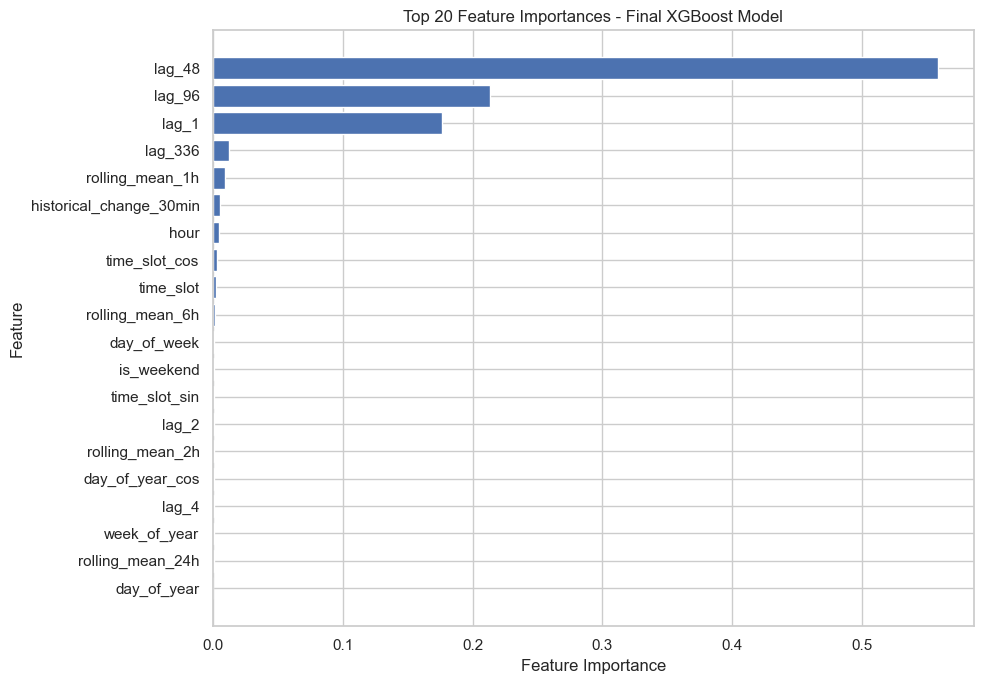

In [299]:
plt.figure(figsize=(10, 7))

top_features = final_feature_importance.head(20).sort_values(
    "Importance",
    ascending=True
)

plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)

plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title("Top 20 Feature Importances - Final XGBoost Model")
plt.tight_layout()
plt.show()

## Actual vs Predicted Demand on the Test Set

The following visualization compares the actual electricity demand with the
demand predicted by the final XGBoost model over the complete unseen test
period.

The test data was not used during model selection or hyperparameter tuning.

In [300]:
test_results = test_df[["Datetime", "Total_Load"]].copy()

test_results["Predicted_Load"] = final_xgb_test_pred

test_results["Residual"] = (
    test_results["Total_Load"] -
    test_results["Predicted_Load"]
)

test_results.head()

,Datetime,Total_Load,Predicted_Load,Residual
14496,2017-11-06 00:00:00,59517.776920,59739.917969,-222.141049
14497,2017-11-06 00:30:00,56561.963560,56894.136719,-332.173159
14498,2017-11-06 01:00:00,53705.354357,54918.496094,-1213.141737
14499,2017-11-06 01:30:00,51288.510990,53012.566406,-1724.055416
14500,2017-11-06 02:00:00,49426.585753,51221.054688,-1794.468934


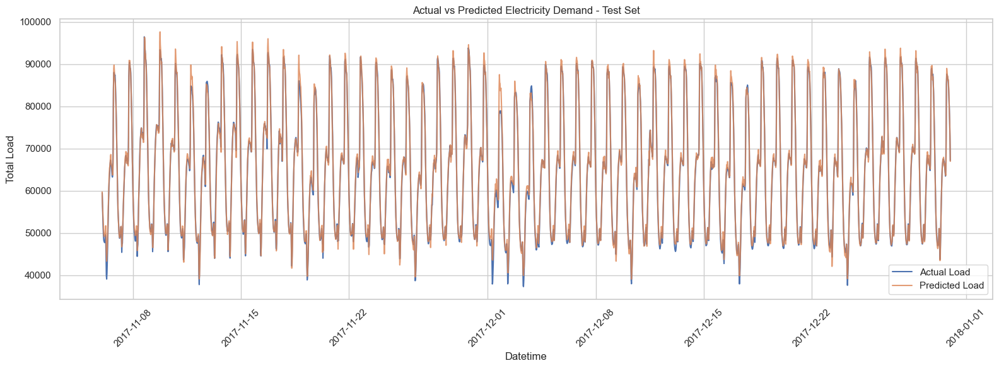

In [301]:
plt.figure(figsize=(16, 6))

plt.plot(
    test_results["Datetime"],
    test_results["Total_Load"],
    label="Actual Load"
)

plt.plot(
    test_results["Datetime"],
    test_results["Predicted_Load"],
    label="Predicted Load",
    alpha=0.8
)

plt.xlabel("Datetime")
plt.ylabel("Total Load")
plt.title("Actual vs Predicted Electricity Demand - Test Set")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

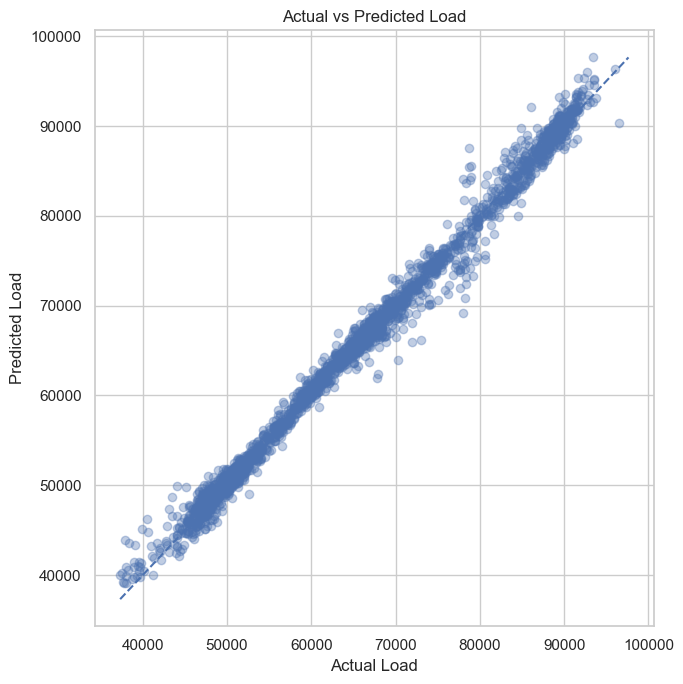

In [302]:
plt.figure(figsize=(7, 7))

plt.scatter(
    test_results["Total_Load"],
    test_results["Predicted_Load"],
    alpha=0.35
)

min_value = min(
    test_results["Total_Load"].min(),
    test_results["Predicted_Load"].min()
)

max_value = max(
    test_results["Total_Load"].max(),
    test_results["Predicted_Load"].max()
)

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle="--"
)

plt.xlabel("Actual Load")
plt.ylabel("Predicted Load")
plt.title("Actual vs Predicted Load")
plt.tight_layout()
plt.show()

### Interpretation

The predicted values generally follow the temporal movement of the actual
electricity demand series.

The close alignment between the two series is consistent with the strong test
metrics obtained by the final model:

- MAE: 860.71
- RMSE: 1,259.82
- MAPE: 1.3719%
- R²: 0.99217

The scatter plot should also show observations concentrated around the
diagonal reference line, indicating agreement between actual and predicted
demand across much of the test range.

In [303]:
test_results["Absolute_Error"] = np.abs(
    test_results["Residual"]
)

test_results["Percentage_Error"] = (
    test_results["Absolute_Error"] /
    test_results["Total_Load"]
) * 100

test_results["Hour"] = test_results["Datetime"].dt.hour
test_results["Month"] = test_results["Datetime"].dt.month

test_results["DayOfWeek"] = (
    test_results["Datetime"].dt.dayofweek
)

test_results.describe()

,Datetime,Total_Load,Predicted_Load,Residual,Absolute_Error,Percentage_Error,Hour,Month,DayOfWeek
count,2640,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000
mean,2017-12-03 11:45:00,64391.792926,64618.441406,-226.651161,860.707493,1.371902,11.500000,11.545455,2.945455
min,2017-11-06 00:00:00,37318.414354,39096.007812,-8772.127460,0.133534,0.000203,0.000000,11.000000,0.000000
25%,2017-11-19 17:52:30,50801.034662,51043.404297,-817.880076,280.631286,0.448799,5.750000,11.000000,1.000000
50%,2017-12-03 11:45:00,64265.617975,64583.488281,-258.966310,621.056467,0.981298,11.500000,12.000000,3.000000
75%,2017-12-17 05:37:30,73957.295355,73905.037109,311.033495,1111.996798,1.762951,17.250000,12.000000,5.000000
max,2017-12-30 23:30:00,96475.408383,97645.445312,8810.665476,8810.665476,15.637866,23.000000,12.000000,6.000000
std,NaN,14235.876826,14149.801758,1239.494123,920.129223,1.476436,6.923498,0.498024,1.976764


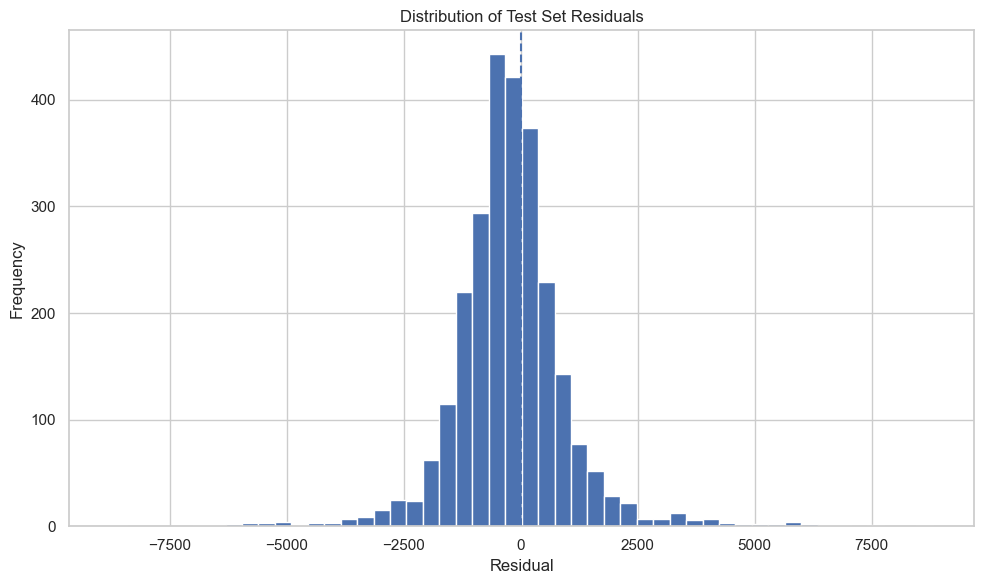

In [304]:
plt.figure(figsize=(10, 6))

plt.hist(
    test_results["Residual"],
    bins=50
)

plt.axvline(
    0,
    linestyle="--"
)

plt.xlabel("Residual")
plt.ylabel("Frequency")
plt.title("Distribution of Test Set Residuals")
plt.tight_layout()
plt.show()

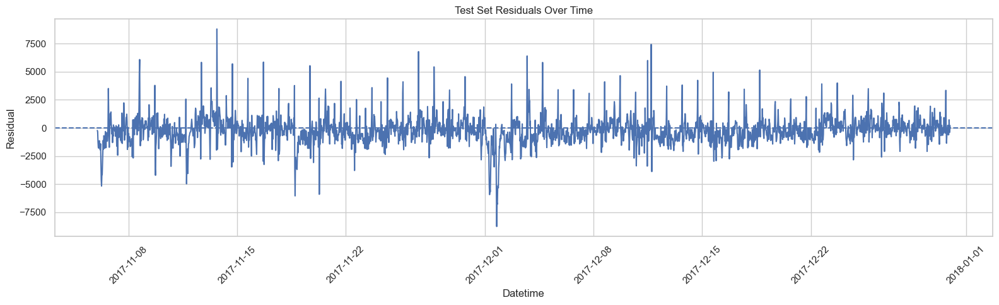

In [305]:
plt.figure(figsize=(16, 5))

plt.plot(
    test_results["Datetime"],
    test_results["Residual"]
)

plt.axhline(
    0,
    linestyle="--"
)

plt.xlabel("Datetime")
plt.ylabel("Residual")
plt.title("Test Set Residuals Over Time")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [306]:
worst_predictions = (
    test_results
    .sort_values("Absolute_Error", ascending=False)
    .head(20)
)

worst_predictions[
    [
        "Datetime",
        "Total_Load",
        "Predicted_Load",
        "Residual",
        "Absolute_Error",
        "Percentage_Error"
    ]
]

,Datetime,Total_Load,Predicted_Load,Residual,Absolute_Error,Percentage_Error
14866,2017-11-13 17:00:00,77977.376413,69166.710938,8810.665476,8810.665476,11.299002
15732,2017-12-01 18:00:00,78749.997540,87522.125000,-8772.127460,8772.127460,11.139210
16210,2017-12-11 17:00:00,78262.314973,70823.914062,7438.400911,7438.400911,9.504448
15490,2017-11-26 17:00:00,72963.064083,66165.289062,6797.775021,6797.775021,9.316735
15734,2017-12-01 19:00:00,78661.331293,85456.031250,-6794.699957,6794.699957,8.637916
15733,2017-12-01 18:30:00,78905.851833,85565.679688,-6659.827854,6659.827854,8.440220
15826,2017-12-03 17:00:00,70349.656273,63942.562500,6407.093773,6407.093773,9.107498
15731,2017-12-01 17:30:00,77997.298973,84119.812500,-6122.513527,6122.513527,7.849648
14627,2017-11-08 17:30:00,96475.408383,90385.695312,6089.713071,6089.713071,6.312192
15108,2017-11-18 18:00:00,86079.550087,92128.585938,-6049.035851,6049.035851,7.027262


In [307]:
hourly_test_error = (
    test_results
    .groupby("Hour")
    .agg(
        MAE=("Absolute_Error", "mean"),
        RMSE=("Residual", lambda x: np.sqrt(np.mean(x ** 2))),
        Mean_Residual=("Residual", "mean"),
        MAPE=("Percentage_Error", "mean")
    )
    .reset_index()
)

hourly_test_error

,Hour,MAE,RMSE,Mean_Residual,MAPE
0,0,412.539264,498.271797,-228.691445,0.712220
1,1,501.791398,646.574691,-83.395537,0.954064
2,2,514.492757,664.024459,-146.630714,1.047155
3,3,512.038527,654.216793,-242.788153,1.077780
4,4,723.079881,848.926898,-462.790181,1.526013
5,5,546.294282,732.947511,-201.355041,1.114987
6,6,1043.659220,1423.970475,-980.762227,2.211067
7,7,1221.242992,1686.924341,-413.567415,2.783698
8,8,940.908509,1294.526403,-93.992496,1.969803
9,9,703.646400,903.605801,-340.049966,1.251831


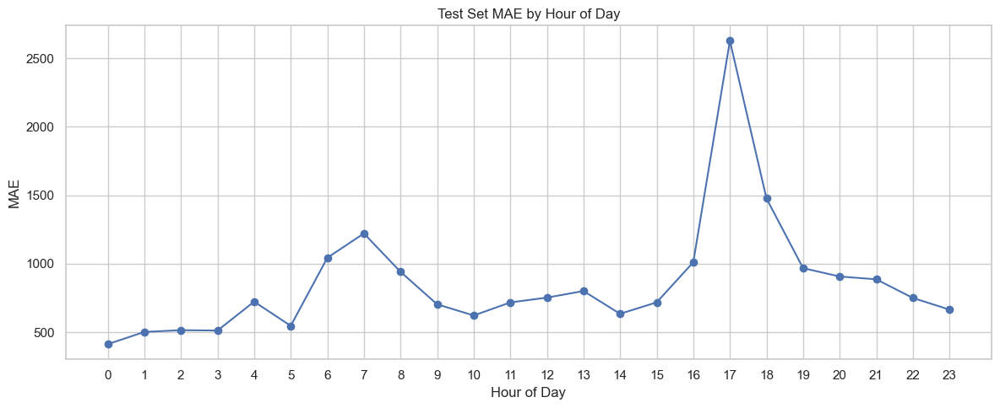

In [308]:
plt.figure(figsize=(12, 5))

plt.plot(
    hourly_test_error["Hour"],
    hourly_test_error["MAE"],
    marker="o"
)

plt.xlabel("Hour of Day")
plt.ylabel("MAE")
plt.title("Test Set MAE by Hour of Day")
plt.xticks(range(24))
plt.tight_layout()
plt.show()

In [309]:
monthly_test_error = (
    test_results
    .groupby("Month")
    .agg(
        MAE=("Absolute_Error", "mean"),
        RMSE=("Residual", lambda x: np.sqrt(np.mean(x ** 2))),
        Mean_Residual=("Residual", "mean"),
        MAPE=("Percentage_Error", "mean")
    )
    .reset_index()
)

monthly_test_error

,Month,MAE,RMSE,Mean_Residual,MAPE
0,11,875.009352,1284.074133,-176.272151,1.366379
1,12,848.789278,1239.236821,-268.633670,1.376504


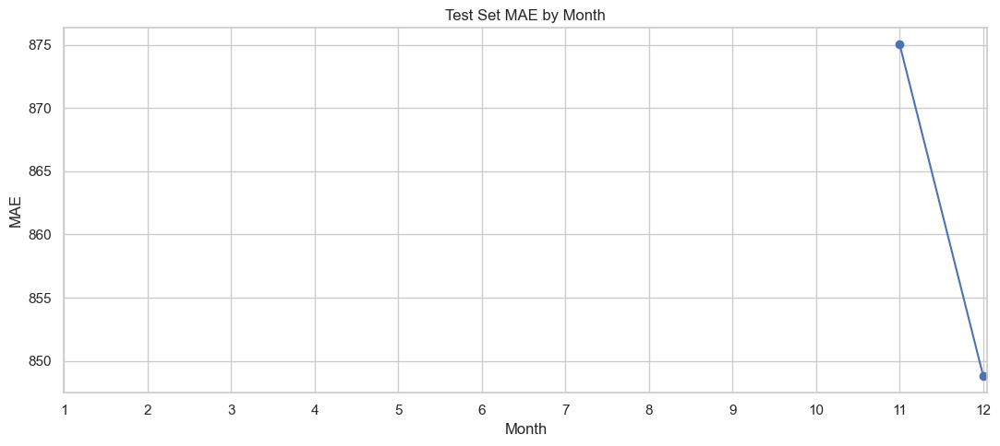

In [310]:
plt.figure(figsize=(11, 5))

plt.plot(
    monthly_test_error["Month"],
    monthly_test_error["MAE"],
    marker="o"
)

plt.xlabel("Month")
plt.ylabel("MAE")
plt.title("Test Set MAE by Month")
plt.xticks(range(1, 13))
plt.tight_layout()
plt.show()

In [311]:
test_results["Is_Holiday"] = X_test["is_holiday"].values

holiday_error = (
    test_results
    .groupby("Is_Holiday")
    .agg(
        MAE=("Absolute_Error", "mean"),
        RMSE=("Residual", lambda x: np.sqrt(np.mean(x ** 2))),
        MAPE=("Percentage_Error", "mean"),
        Mean_Residual=("Residual", "mean"),
        Observations=("Residual", "count")
    )
    .reset_index()
)

holiday_error

,Is_Holiday,MAE,RMSE,MAPE,Mean_Residual,Observations
0,0,864.225985,1264.952796,1.379259,-237.164405,2592
1,1,670.708941,941.644997,0.974586,341.064022,48


In [312]:
holiday_date_summary = (
    test_results[test_results["Is_Holiday"] == 1]
    .assign(Date=lambda x: x["Datetime"].dt.date)
    ["Date"]
    .nunique()
)

holiday_date_summary

1

In [313]:
final_feature_importance[
    final_feature_importance["Feature"].str.contains(
        "Dhanbad|Temperature|Humidity|Cloud|Wind",
        case=False,
        regex=True
    )
]

,Feature,Importance
27,Dhanbad_Temperature,0.000207
28,Dhanbad_CloudCover,0.000195
29,Temperature_Humidity,0.000153
30,Dhanbad_Humidity,0.000143
32,Dhanbad_WindSpeed,0.000117


In [314]:
weather_features = [
    "Dhanbad_Temperature",
    "Dhanbad_Humidity",
    "Dhanbad_CloudCover",
    "Dhanbad_WindSpeed",
    "Temperature_Humidity"
]

final_feature_importance[
    final_feature_importance["Feature"].isin(weather_features)
]

,Feature,Importance
27,Dhanbad_Temperature,0.000207
28,Dhanbad_CloudCover,0.000195
29,Temperature_Humidity,0.000153
30,Dhanbad_Humidity,0.000143
32,Dhanbad_WindSpeed,0.000117


In [315]:
final_feature_importance[
    final_feature_importance["Feature"] == "is_holiday"
]

,Feature,Importance
31,is_holiday,0.000131


## Final Model Feature Importance Interpretation

The final XGBoost model shows a strong dependence on historical electricity
demand features.

The three most important features are:

- `lag_48`: 0.5581
- `lag_96`: 0.2136
- `lag_1`: 0.1764

These correspond to demand at the same time approximately one day earlier,
two days earlier, and the immediately preceding 30-minute interval,
respectively.

This strong contribution from lagged demand is consistent with the temporal
nature of short-term electricity forecasting, where recent and recurring
demand patterns provide strong predictive information.

The remaining feature importance is distributed across weekly historical
demand, rolling statistics, and calendar/time features.

The Dhanbad-specific weather variables have substantially smaller individual
feature importance:

- `Dhanbad_Temperature`: 0.000207
- `Dhanbad_CloudCover`: 0.000195
- `Temperature_Humidity`: 0.000153
- `Dhanbad_Humidity`: 0.000143
- `Dhanbad_WindSpeed`: 0.000117

The `is_holiday` feature has an importance of 0.000131.

Therefore, the fitted model indicates that historical demand patterns explain
most of the predictable variation in this dataset, while weather and holiday
variables provide comparatively smaller additional predictive information.

These variables are nevertheless retained in the forecasting pipeline because
they represent external contextual factors identified in the project
requirements and may provide additional information when demand behavior
deviates from historical patterns.

Feature importance should be interpreted as a property of this fitted model
and dataset rather than as evidence that weather or holidays have no effect
on electricity demand.